# 한국어 챗봇 응답 생성 (Q → A) — **7 : 1 : 2 분할** 변형

**작성일**: 2026-09-21
**기준 노트북**: `notebooks/final.ipynb` (8:1:1 분할)
**이 노트북이 바꾸는 것**: train/val/test 분할 비율 **하나뿐**. 그 외 전처리·토크나이저 학습 방식·모델 구조·하이퍼파라미터·디코딩·평가 지표·오류분석 기준은 전부 동일하다.

---

## 왜 그냥 다시 나누면 안 되는가 — 누수 문제

분할 비율만 바꿔 독립적으로 다시 나누면, **7:1:2의 test에 8:1:1이 학습에 썼던 문장이 섞여 들어간다.** 그 상태로 두 실행의 BLEU를 나란히 놓으면 "8:1:1 모델은 답을 외운 문제를 푸는" 셈이라 비교가 성립하지 않는다.

그래서 이 노트북은 **8:1:1 분할을 먼저 그대로 재현한 뒤, 거기서 7:1:2를 파생**시킨다.

```
8:1:1 (기존)   train 9,400              | val 1,175 | test 1,175
                      │
                      └─ 1,175건을 test로 이동 ─────────────┐
                      ▼                                     ▼
7:1:2 (이 노트북) train 8,225           | val 1,175 | test 2,350
                                                    (= 기존 test 1,175 + 이동분 1,175)
```

이 구조가 보장하는 것:

| 조건 | 의미 |
|---|---|
| **7:1:2의 train ⊂ 8:1:1의 train** | 7:1:2가 학습한 문장은 전부 8:1:1도 학습했던 것뿐이다 → 8:1:1의 test는 7:1:2 학습에 절대 들어가지 않는다 |
| **7:1:2의 test ⊇ 8:1:1의 test** | 8:1:1의 test 1,175건은 7:1:2에서도 평가용으로만 쓰인다 |
| **val은 두 실행이 동일** | 조기 종료 기준이 같아져 학습 종료 시점 비교가 공정해진다 |

따라서 **8:1:1의 test 1,175건 = 두 실행 모두에게 한 번도 학습에 쓰이지 않은 공통 평가셋**이다. 9단계에서 이 집합에서만 두 실행을 비교한다.

> **토크나이저·임베딩도 다시 학습한다.** 기존 `chatbot_bpe.model`과 `word2vec.model`은 9,400건으로 학습된 것이라, 그 안에는 지금 test로 옮긴 1,175건이 들어 있다. 그대로 재사용하면 그 자체가 누수다. 이 노트북은 새 train 8,225건만으로 둘 다 다시 학습한다.

**비교의 의미**: val·평가셋·코드·시드가 전부 같고 **train 크기만 9,400 → 8,225 (-12.5%)** 다르다. 즉 이 실험은 **학습 데이터 12.5% 감소의 효과**를 재는 통제 실험이다.

---

## 산출물 경로

기존 8:1:1 산출물을 덮어쓰지 않도록 전부 별도 폴더를 쓴다.

- 전처리·토크나이저·임베딩: `dataset/processed_712/`
- 체크포인트: `checkpoints/final_712/`
- 지표·예측·그래프: `results/final_712/`

단계 구성(1~8)과 각 단계의 선택 근거는 `final.ipynb` 및 `FINAL_FLOW.md`와 동일하므로, 이 노트북은 근거 서술을 반복하지 않고 **실행과 결과**에 집중한다.

---
# 0. 공통 설정

이후 모든 단계에서 쓰는 라이브러리·경로·난수 시드를 한 곳에 모은다. 시드를 고정하는 이유는 이 노트북의 결론이 "우연히 좋은 실행"이 아니라 재현 가능한 결과임을 보장하기 위해서다.

In [1]:
# 2026-09-21: 공통 라이브러리 로드
import os, sys, glob, json, math, time, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Windows 환경 한글 폰트 (맑은 고딕) - 그래프에 한글이 깨지지 않게 한다
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# KoNLPy(Okt)는 JVM을 사용하므로 JAVA_HOME이 필요하다.
# JDK 설치 후에 띄운 커널이 아니면 환경변수가 갱신되지 않아 JVMNotFoundException이 나므로,
# 비어 있으면 설치된 JDK를 직접 찾아 지정한다 (다른 PC에서 실행해도 동일하게 동작).
if not os.environ.get('JAVA_HOME'):
    _jvm = sorted(glob.glob(r'C:\Program Files\*\jdk*\bin\server\jvm.dll'))
    if _jvm:
        os.environ['JAVA_HOME'] = _jvm[-1].split(r'\bin')[0]

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# 시드 고정: 재현성 확보 (모델 초기화·데이터 셔플·샘플링이 매 실행 동일해진다)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 산출물 경로 (기존 노트북 01~08의 결과를 덮어쓰지 않도록 final 전용 폴더를 쓴다)
DATA_PATH   = Path('../dataset/ChatbotData.xlsx')
PROC_DIR    = Path('../dataset/processed_712')
CKPT_DIR    = Path('../checkpoints/final_712')
RESULT_DIR  = Path('../results/final_712')
for d in (PROC_DIR, CKPT_DIR, RESULT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print('device      :', device)
if device.type == 'cuda':
    print('GPU         :', torch.cuda.get_device_name(0),
          f'({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)')
print('torch       :', torch.__version__)
print('결과 저장 경로:', RESULT_DIR.resolve())

device      : cuda
GPU         : NVIDIA GeForce RTX 4070 Ti (12.0 GB)
torch       : 2.11.0+cu128
결과 저장 경로: C:\Users\iymg1\Documents\nlp-project\results\final_712


---
# 1. 데이터 전처리

**왜 이 단계가 가장 먼저인가**: 뒤 단계에서 쓸 "근거 숫자"를 여기서 확보해야 하기 때문이다. 토크나이저의 `vocab_size`, 모델의 `MAX_LEN`, 평가 시 label별 성능 해석 — 이 모든 것이 데이터의 실제 분포를 알아야 정할 수 있다. 예를 들어 Q/A 길이의 분포를 모르면 3단계의 `MAX_LEN`을 감으로 정하게 된다.

**흐름**: 원본 로드 → 구조 확인 → 중복 확인 → 정제 → 길이 분포 측정 → train/val/test 분할 → 저장

In [2]:
# 2026-09-21: 원본 데이터 로드 및 구조 확인
import re

df = pd.read_excel(DATA_PATH)
print('shape:', df.shape)
print()
print('[컬럼 타입]')
df.info()
print()
print('[결측치 개수]')
print(df.isna().sum())
df.head()

shape: (11823, 3)

[컬럼 타입]
<class 'pandas.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q       11823 non-null  str  
 1   A       11823 non-null  str  
 2   label   11823 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.1 MB

[결측치 개수]
Q        0
A        0
label    0
dtype: int64


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## 1.1 중복 확인 — 무엇을 기준으로 지울 것인가

중복 제거는 "무엇을 같은 것으로 볼 것인가"를 정하는 판단이다. 세 가지 기준으로 각각 세어보고 결정한다.

In [3]:
# 2026-09-21: 세 가지 기준으로 중복 건수 측정
n_dup_full = df.duplicated().sum()                    # 모든 컬럼(Q, A, label)이 동일
n_dup_qa   = df.duplicated(subset=['Q', 'A']).sum()   # Q와 A가 동일 (label은 다를 수 있음)
n_dup_q    = df.duplicated(subset=['Q']).sum()        # Q만 동일 (A가 다른 경우 포함)

print(f'전체 컬럼 기준 중복         : {n_dup_full}건')
print(f'(Q, A) 기준 중복            : {n_dup_qa}건')
print(f'Q만 기준 중복(답변 다름 포함) : {n_dup_q}건')

전체 컬럼 기준 중복         : 0건
(Q, A) 기준 중복            : 73건
Q만 기준 중복(답변 다름 포함) : 161건


**판단: (Q, A) 쌍 기준으로 제거한다.**

- **Q만 같고 A가 다른 행은 남긴다**. "같은 질문에 여러 답이 있을 수 있다"는 것은 챗봇 데이터의 자연스러운 다양성이며, 이것까지 지우면 모델이 배울 수 있는 응답의 폭이 줄어든다.
- **(Q, A)가 완전히 같은 행은 지운다**. 정보량을 더하지 않으면서 특정 패턴의 손실 가중치만 키워, 그 패턴 쪽으로 모델을 편향시킨다.

> **미해결 항목으로 남기는 것**: (Q, A)는 같은데 label만 다른 행이 존재한다. 지금은 label을 학습에 쓰지 않고 평가 시 분해 기준으로만 쓰므로 제거해도 무방하다. 다만 label을 조건으로 주는 모델로 확장한다면 "같은 Q-A가 두 감정 맥락에서 모두 성립한다"는 정보이므로 재검토가 필요하다.

In [4]:
# 2026-09-21: 실제로 제거될 (Q, A) 중복 행을 눈으로 확인 (중복 그룹 전체를 표시)
dup_mask = df.duplicated(subset=['Q', 'A'], keep=False)  # 중복 그룹의 모든 행(첫 등장 포함)
dup_rows = df[dup_mask].sort_values(['Q', 'A'])
print(f'(Q, A) 중복 그룹에 속한 행: 총 {len(dup_rows)}행')
print(f'-> 그룹별 첫 행을 남기고 실제로 제거될 행: {n_dup_qa}행')
dup_rows.head(10)

(Q, A) 중복 그룹에 속한 행: 총 146행
-> 그룹별 첫 행을 남기고 실제로 제거될 행: 73행


,Q,A,label
152,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,0
5527,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,1
189,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,0
5537,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,1
226,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,0
5542,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,1
377,기숙사 괜찮을까,혼자 사는 것보다 불편하겠죠.,0
5704,기숙사 괜찮을까,혼자 사는 것보다 불편하겠죠.,1
592,나는 좋은데 ….,현실의 벽에 부딪혔나봐요.,0
5774,나는 좋은데 ….,현실의 벽에 부딪혔나봐요.,1


## 1.2 label(감정) 분포

label
0    5290
1    3570
2    2963
Name: count, dtype: int64


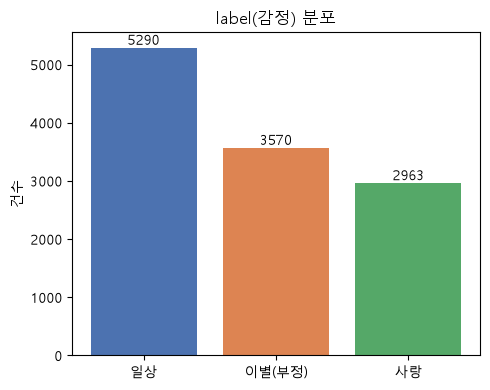

In [5]:
# 2026-09-21: label 분포 확인 (0=일상, 1=이별(부정), 2=사랑)
# 이 분포는 8단계에서 'label별 성능 차이가 데이터 쏠림 때문인가'를 판단하는 근거가 된다.
label_map = {0: '일상', 1: '이별(부정)', 2: '사랑'}
label_counts = df['label'].value_counts().sort_index()
print(label_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([label_map[i] for i in label_counts.index], label_counts.values,
       color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('label(감정) 분포')
ax.set_ylabel('건수')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_label_distribution.png', dpi=120)
plt.show()

## 1.3 Q/A 길이 분포 — `max_length`의 근거 만들기

**percentile을 쓰는 이유**: 아래 히스토그램에서 보이듯 문장 길이는 짧은 쪽에 몰려 있고 극소수의 긴 문장이 긴 꼬리(long tail)를 만든다.

- `max_length`를 **최댓값**으로 잡으면, 그 이상치 몇 건 때문에 나머지 대부분의 짧은 문장까지 전부 그 길이까지 padding되어 연산·메모리가 낭비된다.
- 너무 짧게(예: 평균) 잡으면 긴 문장이 많이 잘려(truncation) 정보 손실이 커진다.
- **95 percentile**은 "상위 5%의 일부 잘림을 감수하고 데이터의 95%는 손실 없이 담는" 절충점이다.

여기서는 음절 기준으로 먼저 감을 잡고, 실제 모델 입력 단위인 BPE 토큰 기준의 정확한 값은 2.6절에서 다시 측정한다.

,Q_char_len,A_char_len,Q_word_len,A_word_len
count,11823.00,11823.00,11823.00,11823.00
mean,12.88,15.02,3.59,3.69
std,6.17,6.70,1.62,1.86
min,1.00,1.00,1.00,1.00
25%,9.00,10.00,2.00,2.00
50%,12.00,14.00,3.00,3.00
75%,16.00,18.00,4.00,5.00
max,56.00,76.00,15.00,21.00


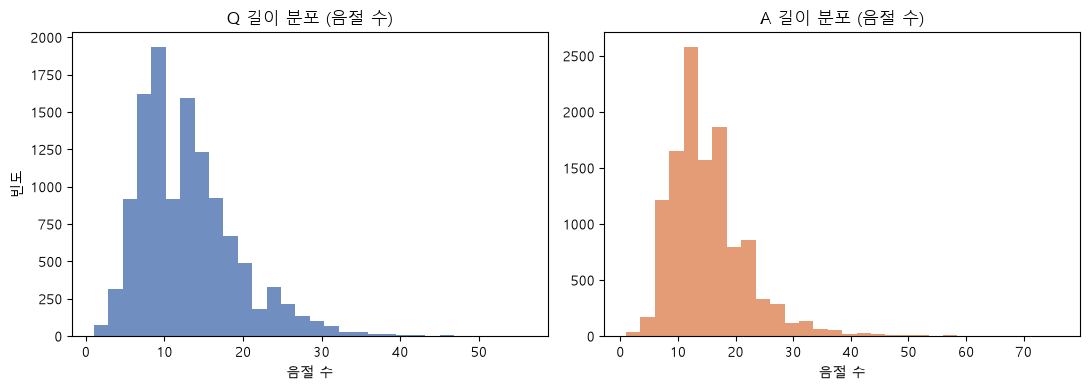

Q 길이 95 percentile: 25음절 (최댓값 56음절)
A 길이 95 percentile: 27음절 (최댓값 76음절)
-> 95p와 최댓값의 격차가 크다 = 이상치가 존재한다 = 최댓값 기준 padding은 낭비가 크다


In [6]:
# 2026-09-21: Q/A 길이(음절 수, 어절 수) 계산 및 분포 확인
df['Q_char_len'] = df['Q'].str.len()               # 음절(글자) 수
df['A_char_len'] = df['A'].str.len()
df['Q_word_len'] = df['Q'].str.split().apply(len)  # 어절(공백 분리) 수
df['A_word_len'] = df['A'].str.split().apply(len)

display(df[['Q_char_len', 'A_char_len', 'Q_word_len', 'A_word_len']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['Q_char_len'], bins=30, color='#4C72B0', alpha=0.8)
axes[0].set_title('Q 길이 분포 (음절 수)')
axes[0].set_xlabel('음절 수')
axes[0].set_ylabel('빈도')
axes[1].hist(df['A_char_len'], bins=30, color='#DD8452', alpha=0.8)
axes[1].set_title('A 길이 분포 (음절 수)')
axes[1].set_xlabel('음절 수')
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_length_distribution.png', dpi=120)
plt.show()

q95_char = int(np.percentile(df['Q_char_len'], 95))
a95_char = int(np.percentile(df['A_char_len'], 95))
print(f'Q 길이 95 percentile: {q95_char}음절 (최댓값 {df.Q_char_len.max()}음절)')
print(f'A 길이 95 percentile: {a95_char}음절 (최댓값 {df.A_char_len.max()}음절)')
print('-> 95p와 최댓값의 격차가 크다 = 이상치가 존재한다 = 최댓값 기준 padding은 낭비가 크다')

## 1.4 정제

- **공백 정규화**(연속 공백 → 단일 공백, 앞뒤 공백 제거): 같은 문장이 띄어쓰기 차이만으로 다른 문자열로 취급되는 것을 막는다. 구어체 데이터에서 흔한 문제다.
- **빈 문자열 제거**: 학습에 쓸 수 없는 행이다.
- **(Q, A) 중복 제거**: 1.1절의 판단대로.

In [7]:
# 2026-09-21: 텍스트 정제 (공백 정규화 -> 빈 문자열 제거 -> (Q,A) 중복 제거)
def clean_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)  # 연속 공백 -> 단일 공백
    return text

n_before = len(df)
df_clean = df.copy()
df_clean['Q'] = df_clean['Q'].apply(clean_text)
df_clean['A'] = df_clean['A'].apply(clean_text)

df_clean = df_clean[(df_clean['Q'].str.len() > 0) & (df_clean['A'].str.len() > 0)]
print(f'공백 정규화 + 빈 문자열 제거 후: {len(df_clean)}건')

df_clean = df_clean.drop_duplicates(subset=['Q', 'A']).reset_index(drop=True)
n_after = len(df_clean)
print(f'(Q, A) 중복 제거 후: {n_after}건')
print(f'=> 원본 {n_before}건 -> 정제 후 {n_after}건 (총 {n_before - n_after}건 제거)')

공백 정규화 + 빈 문자열 제거 후: 11823건
(Q, A) 중복 제거 후: 11750건
=> 원본 11823건 -> 정제 후 11750건 (총 73건 제거)


## 1.5 train / val / test 분할 — 8:1:1에서 파생시키기

표지에서 설명한 대로, 독립적으로 다시 나누지 않고 **8:1:1 분할을 재현한 뒤 거기서 파생**시킨다. 누수를 막기 위한 설계이며, 아래 셀 다음에 그 조건이 실제로 성립하는지 직접 검증한다.

**label stratify를 유지하는 이유**: 1.2절에서 확인한 label 쏠림 때문이다. train에서 test로 옮기는 1,175건도 label 비율을 유지하며 뽑아야, 8단계 label별 분석이 "옮기다 생긴 우연"에 오염되지 않는다.

In [8]:
# 2026-09-21: 8:1:1 분할을 먼저 재현한 뒤 7:1:2를 파생시킨다 (누수 방지 설계)
from sklearn.model_selection import train_test_split

# (a) 기존 8:1:1 분할 재현 - final.ipynb와 완전히 동일한 코드/시드이므로 같은 분할이 나온다
train80, temp_df = train_test_split(
    df_clean, test_size=0.2, random_state=SEED, stratify=df_clean['label'])
val10, test10 = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])
print(f'[재현된 8:1:1] train {len(train80)} / val {len(val10)} / test {len(test10)}')

# (b) train80에서 '전체의 10%'에 해당하는 만큼을 떼어 test로 옮긴다 (label 비율 유지)
move_frac = len(test10) / len(train80)          # 9,400 중 1,175 -> 0.125
train70, moved = train_test_split(
    train80, test_size=move_frac, random_state=SEED, stratify=train80['label'])

# 공통 평가셋(=기존 8:1:1의 test) 여부를 컬럼으로 남겨 9단계 비교에서 쓴다
test10 = test10.copy(); test10['in_common'] = True
moved = moved.copy();   moved['in_common'] = False

train_df = train70.reset_index(drop=True)
val_df = val10.reset_index(drop=True)
# 순서에 의존하지 않도록 섞는다 (in_common 컬럼으로 구분하므로 섞어도 무방)
test_df = (pd.concat([test10, moved])
           .sample(frac=1, random_state=SEED)
           .reset_index(drop=True))

n_all = len(df_clean)
print(f'[7:1:2] train {len(train_df)} ({len(train_df)/n_all:.1%}) / '
      f'val {len(val_df)} ({len(val_df)/n_all:.1%}) / '
      f'test {len(test_df)} ({len(test_df)/n_all:.1%})')
print(f'        test 중 공통 평가셋(기존 8:1:1 test): {int(test_df["in_common"].sum())}건')
print()
print('[분할별 label 비율 (%)] - stratify가 제대로 동작했는지 확인')
ratio = pd.DataFrame({
    'train': train_df['label'].value_counts(normalize=True).sort_index() * 100,
    'val'  : val_df['label'].value_counts(normalize=True).sort_index() * 100,
    'test' : test_df['label'].value_counts(normalize=True).sort_index() * 100,
}).round(1)
ratio.index = [label_map[i] for i in ratio.index]
display(ratio)

cols = ['Q', 'A', 'label']
train_df[cols].to_csv(PROC_DIR / 'train.csv', index=False, encoding='utf-8-sig')
val_df[cols].to_csv(PROC_DIR / 'val.csv', index=False, encoding='utf-8-sig')
test_df[cols + ['in_common']].to_csv(PROC_DIR / 'test.csv', index=False, encoding='utf-8-sig')
print()
print('저장 완료:', PROC_DIR.resolve())

[재현된 8:1:1] train 9400 / val 1175 / test 1175
[7:1:2] train 8225 (70.0%) / val 1175 (10.0%) / test 2350 (20.0%)
        test 중 공통 평가셋(기존 8:1:1 test): 1175건

[분할별 label 비율 (%)] - stratify가 제대로 동작했는지 확인


,train,val,test
일상,45.0,45.0,45.0
이별(부정),29.8,29.8,29.8
사랑,25.2,25.2,25.2



저장 완료: C:\Users\iymg1\Documents\nlp-project\dataset\processed_712


### 1.5.1 누수 검증 — 설계가 실제로 성립하는지 확인

"이렇게 설계했다"는 말로는 부족하다. 기존 8:1:1 분할 파일(`dataset/processed/`)을 직접 읽어 세 조건을 **집합 연산으로 검증**한다. 하나라도 어긋나면 이 셀에서 실행이 멈춘다.

In [9]:
# 2026-09-21: 누수 방지 조건을 기존 8:1:1 분할 파일과 대조해 검증한다 (실패 시 AssertionError)
OLD_DIR = Path('../dataset/processed')          # final.ipynb(8:1:1)가 저장한 분할
old_train = pd.read_csv(OLD_DIR / 'train.csv')
old_val   = pd.read_csv(OLD_DIR / 'val.csv')
old_test  = pd.read_csv(OLD_DIR / 'test.csv')

def keyset(d):
    # df_clean은 (Q, A) 기준으로 중복 제거되어 있으므로 (Q, A)가 유일 키가 된다
    return set(zip(d['Q'], d['A']))

k_new_train = keyset(train_df)
k_new_val   = keyset(val_df)
k_new_test  = keyset(test_df)
k_common    = keyset(test_df[test_df['in_common']])
k_old_train, k_old_val, k_old_test = keyset(old_train), keyset(old_val), keyset(old_test)

checks = [
    ('8:1:1 분할이 동일하게 재현됨',        keyset(train80) == k_old_train),
    ('val이 두 실행에서 동일',              k_new_val == k_old_val),
    ('공통 평가셋 == 8:1:1의 test',         k_common == k_old_test),
    ('7:1:2 train ⊂ 8:1:1 train',          k_new_train <= k_old_train),
    ('7:1:2 train ∩ 8:1:1 test = 공집합',   not (k_new_train & k_old_test)),
    ('7:1:2 train ∩ 7:1:2 test = 공집합',   not (k_new_train & k_new_test)),
    ('7:1:2 train ∩ val = 공집합',          not (k_new_train & k_new_val)),
    ('8:1:1 test ⊂ 7:1:2 test',            k_old_test <= k_new_test),
]
for name, ok in checks:
    print(f'  {"OK  " if ok else "실패"} | {name}')
assert all(ok for _, ok in checks), '누수 방지 조건이 깨졌다 - 분할 로직을 확인할 것'

print()
print(f'=> 공통 평가셋 {len(k_common)}건은 두 실행 모두 학습에 한 번도 쓰이지 않았다.')
print(f'   train 크기: 8:1:1 {len(k_old_train)}건 -> 7:1:2 {len(k_new_train)}건 '
      f'({(len(k_new_train)/len(k_old_train)-1)*100:.1f}%)')

  OK   | 8:1:1 분할이 동일하게 재현됨
  OK   | val이 두 실행에서 동일
  OK   | 공통 평가셋 == 8:1:1의 test
  OK   | 7:1:2 train ⊂ 8:1:1 train
  OK   | 7:1:2 train ∩ 8:1:1 test = 공집합
  OK   | 7:1:2 train ∩ 7:1:2 test = 공집합
  OK   | 7:1:2 train ∩ val = 공집합
  OK   | 8:1:1 test ⊂ 7:1:2 test

=> 공통 평가셋 1175건은 두 실행 모두 학습에 한 번도 쓰이지 않았다.
   train 크기: 8:1:1 9400건 -> 7:1:2 8225건 (-12.5%)


In [10]:
# 2026-09-21: 1단계 요약 (이후 단계와 보고서에서 그대로 인용하는 숫자들)
step1_summary = {
    '원본 건수': int(n_before),
    '정제 후 건수': int(n_after),
    '제거된 중복/빈행': int(n_before - n_after),
    'label 분포': {label_map[k]: int(v) for k, v in label_counts.items()},
    'Q 길이 95p(음절)': q95_char,
    'A 길이 95p(음절)': a95_char,
    'train/val/test': [len(train_df), len(val_df), len(test_df)],
}
with open(RESULT_DIR / 'step1_data_summary.json', 'w', encoding='utf-8') as f:
    json.dump(step1_summary, f, ensure_ascii=False, indent=2)
print(json.dumps(step1_summary, ensure_ascii=False, indent=2))

{
  "원본 건수": 11823,
  "정제 후 건수": 11750,
  "제거된 중복/빈행": 73,
  "label 분포": {
    "일상": 5290,
    "이별(부정)": 3570,
    "사랑": 2963
  },
  "Q 길이 95p(음절)": 25,
  "A 길이 95p(음절)": 27,
  "train/val/test": [
    8225,
    1175,
    2350
  ]
}


## 1단계 요약

| 항목 | 결정 | 근거 |
|---|---|---|
| 중복 제거 기준 | (Q, A) 쌍 | Q만 같고 A가 다른 것은 자연스러운 다양성이므로 보존. (Q,A) 완전 중복은 정보 없이 손실 가중치만 키움 |
| 공백 정규화 | 연속 공백 → 단일 공백 | 같은 문장이 띄어쓰기 차이로 다른 문자열이 되는 것을 방지 |
| `max_length` 기준 | 최댓값이 아닌 **95 percentile** | 이상치 5% 때문에 95%가 과도하게 padding되는 낭비를 막는 절충점 |
| 분할 비율 | 8 : 1 : 1 | 데이터가 작아 학습량 확보가 우선. val/test 각 1,175건은 corpus 지표 계산에 충분 |
| 분할 방식 | label stratify | split 우연이 8단계 label별 분석을 오염시키지 않게 함 |

**다음 단계로 넘기는 것**: 길이 95 percentile 값(2.6절에서 BPE 토큰 단위로 재측정), label 분포(8단계 label별 성능 해석의 근거).

---
# 2. 토큰화, 임베딩, 인코딩 전략

**이 단계에서 정해야 하는 것 세 가지**

1. **토큰화** — 문장을 어떤 단위로 쪼갤 것인가 (어절/음절/형태소/자모/서브워드)
2. **임베딩** — 토큰을 어떤 벡터로 바꿀 것인가, 그 벡터는 어떻게 학습되는가
3. **인코딩 전략** — 쪼갠 토큰을 모델이 먹을 수 있는 정수 시퀀스로 어떻게 조립할 것인가 (특수 토큰, 길이, 패딩)

**왜 순서가 이런가**: 토큰화 단위가 정해져야 vocab이 정해지고, vocab이 정해져야 임베딩 행렬의 크기가 정해지며, 그 뒤에야 모델 입력 형태(인코딩)를 확정할 수 있다.

**한국어라서 생기는 문제**: 한국어는 조사·어미가 단어에 결합되는 교착어다. "먹었어요 / 먹었지만 / 먹었는데"가 어절 기준으로는 전부 다른 토큰이 되어, 의미는 같은데 vocab만 불필요하게 커지고 각 토큰의 학습 데이터는 희소해진다. 이 문제를 어떻게 다룰지가 토큰화 단위 선택의 핵심이다.

In [11]:
# 2026-09-21: 1단계에서 저장한 학습 데이터 로드 (이후 모든 단계의 공통 입력)
train_df = pd.read_csv(PROC_DIR / 'train.csv')
val_df   = pd.read_csv(PROC_DIR / 'val.csv')
test_df  = pd.read_csv(PROC_DIR / 'test.csv')
print(f'train/val/test = {len(train_df)}/{len(val_df)}/{len(test_df)}')

# 토큰화 실습에 쓸 예시 문장 3개 (구어체 / 자모 반복 / 평서문을 골고루 포함)
samples = [
    train_df.iloc[0]['Q'],
    '내일 뭐하지 넘 심심하다ㅋㅋ',
    '오늘 저녁에 뭐 먹을지 고민이에요.',
]
for s in samples:
    print(' -', s)

train/val/test = 8225/1175/2350
 - 마음 먹었습니다
 - 내일 뭐하지 넘 심심하다ㅋㅋ
 - 오늘 저녁에 뭐 먹을지 고민이에요.


## 2.1 토큰화 단위 4종 비교 — 어절 / 음절 / 형태소 / 자모

**왜 네 가지를 다 해보는가**: "형태소 단위가 좋다"는 결론이 감이 아니라 실측 위에 서 있어야 하기 때문이다. 각 방식이 같은 문장을 어떻게 쪼개는지 직접 보고, 평균 토큰 수를 재서 비교한다.

In [12]:
# 2026-09-21: (1) 어절 단위 - 공백으로만 분리
# 구현이 가장 간단하지만 조사/어미가 그대로 붙어 있어 vocab이 커지고 데이터가 희소해진다.
def tokenize_eojeol(text: str):
    return text.split()

for s in samples:
    print(s, '->', tokenize_eojeol(s))

마음 먹었습니다 -> ['마음', '먹었습니다']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['내일', '뭐하지', '넘', '심심하다ㅋㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['오늘', '저녁에', '뭐', '먹을지', '고민이에요.']


In [13]:
# 2026-09-21: (2) 음절 단위 - 글자 하나하나로 분리
# vocab이 아주 작아지지만(한글 음절 약 2,350자) 시퀀스가 길어지고,
# 음절 하나는 그 자체로 의미를 갖지 않는 경우가 많아 표현력이 떨어진다.
def tokenize_syllable(text: str):
    return list(text.replace(' ', ''))

for s in samples:
    print(s, '->', tokenize_syllable(s))

마음 먹었습니다 -> ['마', '음', '먹', '었', '습', '니', '다']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['내', '일', '뭐', '하', '지', '넘', '심', '심', '하', '다', 'ㅋ', 'ㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['오', '늘', '저', '녁', '에', '뭐', '먹', '을', '지', '고', '민', '이', '에', '요', '.']


In [14]:
# 2026-09-21: (3) 형태소 단위 - KoNLPy Okt
# Okt를 고른 이유: KoNLPy의 형태소 분석기 중 Kkma보다 처리 속도가 빠르고,
#   SNS/구어체 텍스트(이모티콘, 축약어, 반복 자모)에 더 강건하도록 설계되어 있다.
#   ChatbotData는 트위터 기반 구어체 대화라 Kkma의 정교한 분석보다 Okt의 속도/구어체 대응이 적합하다.
from konlpy.tag import Okt

okt = Okt()
for s in samples:
    print(s, '->', okt.morphs(s))

마음 먹었습니다 -> ['마음', '먹었습니다']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['내일', '뭐', '하지', '넘', '심심하다', 'ㅋㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['오늘', '저녁', '에', '뭐', '먹을지', '고민', '이에요', '.']


In [15]:
# 2026-09-21: (4) 자모 단위 - 초성/중성/종성까지 분해
# 오탈자·신조어에 가장 강인하지만 시퀀스 길이가 음절 단위보다도 2~3배 길어진다.
# Transformer의 self-attention 연산량은 시퀀스 길이의 제곱에 비례하므로 비용이 급격히 커진다.
# -> 생성 태스크에서는 시퀀스 길이가 중요한 비용 요소이므로 '비교' 목적으로만 보고 채택하지 않는다.
from jamo import h2j, j2hcj

def tokenize_jamo(text: str):
    return list(j2hcj(h2j(text.replace(' ', ''))))

for s in samples:
    print(s, '->', tokenize_jamo(s))

마음 먹었습니다 -> ['ㅁ', 'ㅏ', 'ㅇ', 'ㅡ', 'ㅁ', 'ㅁ', 'ㅓ', 'ㄱ', 'ㅇ', 'ㅓ', 'ㅆ', 'ㅅ', 'ㅡ', 'ㅂ', 'ㄴ', 'ㅣ', 'ㄷ', 'ㅏ']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['ㄴ', 'ㅐ', 'ㅇ', 'ㅣ', 'ㄹ', 'ㅁ', 'ㅝ', 'ㅎ', 'ㅏ', 'ㅈ', 'ㅣ', 'ㄴ', 'ㅓ', 'ㅁ', 'ㅅ', 'ㅣ', 'ㅁ', 'ㅅ', 'ㅣ', 'ㅁ', 'ㅎ', 'ㅏ', 'ㄷ', 'ㅏ', 'ㅋ', 'ㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['ㅇ', 'ㅗ', 'ㄴ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅓ', 'ㄴ', 'ㅕ', 'ㄱ', 'ㅇ', 'ㅔ', 'ㅁ', 'ㅝ', 'ㅁ', 'ㅓ', 'ㄱ', 'ㅇ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅣ', 'ㄱ', 'ㅗ', 'ㅁ', 'ㅣ', 'ㄴ', 'ㅇ', 'ㅣ', 'ㅇ', 'ㅔ', 'ㅇ', 'ㅛ', '.']


In [16]:
# 2026-09-21: 네 방식의 평균 토큰 수 비교 (train Q 500건 샘플 - Okt가 JVM 호출이라 느려서 표본으로 측정)
sample_qs = train_df['Q'].sample(500, random_state=SEED).tolist()

tok_compare = pd.DataFrame({
    '토큰화 단위': ['어절', '형태소(Okt)', '음절', '자모'],
    '평균 토큰 수': [
        np.mean([len(tokenize_eojeol(s)) for s in sample_qs]),
        np.mean([len(okt.morphs(s)) for s in sample_qs]),
        np.mean([len(tokenize_syllable(s)) for s in sample_qs]),
        np.mean([len(tokenize_jamo(s)) for s in sample_qs]),
    ],
}).round(2)
tok_compare['상대 연산량(길이^2)'] = (
    (tok_compare['평균 토큰 수'] / tok_compare['평균 토큰 수'].iloc[0]) ** 2).round(1)
display(tok_compare)
tok_compare.to_csv(RESULT_DIR / 'step2_tokenizer_unit_comparison.csv',
                   index=False, encoding='utf-8-sig')

,토큰화 단위,평균 토큰 수,상대 연산량(길이^2)
0,어절,3.53,1.0
1,형태소(Okt),5.26,2.2
2,음절,10.19,8.3
3,자모,24.26,47.2


**측정 결과 해석**: 어절 < 형태소 < 음절 < 자모 순으로 평균 토큰 수가 늘어난다. 조사·어미가 분리되면서 형태소가 어절보다 많아지고, 음절·자모로 갈수록 더 잘게 쪼개진다.

`상대 연산량` 열은 self-attention 비용이 시퀀스 길이의 제곱에 비례한다는 점을 반영한 값이다. 자모 단위는 어절 대비 수십 배의 연산량을 요구한다. **무조건 잘게 쪼갠다고 좋은 것이 아니다.**

**결론**: 형태소 단위가 "의미 단위 보존"과 "시퀀스 길이"의 절충점이다. 그래서 2.5절의 Word2Vec 임베딩 학습과 5단계의 평가 지표 계산에 형태소 단위를 쓴다.

**그런데 모델 입력으로는 형태소만으로 부족하다** — 다음 절에서 그 이유와 대안을 본다.

## 2.2 서브워드(BPE) 토크나이저 직접 학습

**형태소 분석만으로 부족한 이유**: Okt 같은 형태소 분석기는 사전(rule) 기반이라 학습 데이터에 없던 신조어·오타·외래어에 약하다. 미등록어가 들어오면 분석이 깨지거나 통째로 unknown 처리된다. 챗봇은 사용자가 무슨 말을 입력할지 통제할 수 없으므로 이 약점이 치명적이다.

**BPE(Byte Pair Encoding)가 해결하는 것**: BPE는 사전이 아니라 **문자 병합 통계**로 vocab을 만든다. 자주 붙어 나오는 문자쌍을 반복적으로 병합해 subword를 만들기 때문에, 처음 보는 문자열도 이미 아는 subword의 조합으로 표현할 수 있다. 즉 OOV(미등록어)가 사실상 사라진다. BERT·GPT·BART·T5 등 우리가 4단계에서 쓸 사전학습 Transformer가 예외 없이 서브워드 토크나이저를 쓰는 이유도 같다.

**WordPiece가 아니라 SentencePiece를 고른 이유**: WordPiece는 공백으로 단어를 먼저 나눈 뒤 그 안에서만 subword를 만든다. SentencePiece는 공백까지 포함한 raw text를 그대로 다루기 때문에, 띄어쓰기가 불규칙한 구어체 한국어("안녕하세요" vs "안녕 하세요")에 안정적이다. 또한 4단계에서 파인튜닝할 KoBART가 SentencePiece 계열 토크나이저를 쓰므로, 베이스라인도 같은 방식으로 맞춰야 "토크나이저 방식 차이" 때문에 비교가 흐려지지 않는다.

In [17]:
# 2026-09-21: SentencePiece 학습용 코퍼스 파일 생성 (train의 Q, A를 한 줄씩)
# 주의: val/test를 넣으면 평가 데이터 정보가 토크나이저에 새어 들어간다(data leakage). train만 쓴다.
corpus_path = PROC_DIR / 'corpus_for_bpe.txt'
with open(corpus_path, 'w', encoding='utf-8') as f:
    for q, a in zip(train_df['Q'], train_df['A']):
        f.write(q + '\n')
        f.write(a + '\n')
print('코퍼스 줄 수:', sum(1 for _ in open(corpus_path, encoding='utf-8')))

코퍼스 줄 수: 16450


In [18]:
# 2026-09-21: SentencePiece BPE 학습
# vocab_size=8000 근거: 학습 코퍼스가 짧은 대화문 약 1.9만 줄(9,400쌍 x 2)로 크지 않다.
#   - 3만 이상으로 크게 잡으면 저빈도 subword가 많아져 학습이 비효율적이고 임베딩 파라미터만 늘어난다.
#   - 1천 이하로 작게 잡으면 subword가 지나치게 잘게 쪼개져 시퀀스가 길어지고 의미 단위가 깨진다.
#   - 소규모 대화체 코퍼스에서 흔히 쓰이는 8,000~16,000 범위의 하단인 8,000을 택했다.
# character_coverage=0.9995: 한국어처럼 문자 종류가 많은 언어에 대한 SentencePiece 공식 권장치.
# pad/unk/bos/eos id를 0/1/2/3으로 명시: 2.6절의 인코딩과 3단계 모델이 이 값을 그대로 쓴다.
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input=str(corpus_path),
    model_prefix=str(PROC_DIR / 'chatbot_bpe'),
    vocab_size=8000,
    model_type='bpe',
    character_coverage=0.9995,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

sp = spm.SentencePieceProcessor(model_file=str(PROC_DIR / 'chatbot_bpe.model'))
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
VOCAB_SIZE = sp.get_piece_size()
print('BPE 학습 완료 | vocab size:', VOCAB_SIZE)
print()
for s in samples:
    print(s, '->', sp.encode(s, out_type=str))

BPE 학습 완료 | vocab size: 8000

마음 먹었습니다 -> ['▁마음', '▁먹었', '습니다']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['▁내일', '▁뭐하지', '▁넘', '▁심심', '하다', 'ᄏᄏ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['▁오늘', '▁저녁에', '▁뭐', '▁먹을', '지', '▁고민', '이에요', '.']


## 2.3 OOV 대응 확인 — 형태소 분석기 vs BPE

말로만 "BPE가 OOV에 강하다"고 하면 근거가 없다. 학습 코퍼스에 없을 법한 신조어를 직접 넣어 두 방식이 어떻게 처리하는지 비교한다.

In [19]:
# 2026-09-21: OOV(미등록어) 처리 비교 - 형태소 분석(Okt) vs BPE
oov_examples = ['오늘 월루했다', 'ㄹㅇㅋㅋ 완전 갓생살기 아님?']

for s in oov_examples:
    print('문장:', s)
    print('  Okt 형태소  :', okt.morphs(s))
    print('  BPE subword :', sp.encode(s, out_type=str))
    unk_cnt = sp.encode(s, out_type=int).count(UNK_ID)
    print(f'  -> BPE의 unknown 토큰 수: {unk_cnt}개')
    print()

문장: 오늘 월루했다
  Okt 형태소  : ['오늘', '월루했다']
  BPE subword : ['▁오늘', '▁월', '루', '했다']
  -> BPE의 unknown 토큰 수: 0개

문장: ㄹㅇㅋㅋ 완전 갓생살기 아님?
  Okt 형태소  : ['ㄹㅇㅋㅋ', '완전', '갓', '생', '살기', '아님', '?']
  BPE subword : ['▁', 'ᄅᄋ', 'ᄏᄏ', '▁완전', '▁', '갓', '생', '살', '기', '▁아', '님', '?']
  -> BPE의 unknown 토큰 수: 2개



**확인된 사실**: Okt는 신조어("월루", "갓생살기")를 의미 없는 조각으로 잘못 분해한다. BPE는 같은 표현을 subword 조합으로 표현하며 unknown 토큰이 0개다. 이것이 모델 입력 토크나이저로 BPE를 쓰는 실측 근거다.

## 2.4 사전학습 모델(KoBART) 토크나이저와 비교 — 왜 토크나이저를 두 개 쓰는가

**이 절이 이 단계에서 가장 중요한 분기점이다.**

4단계에서 파인튜닝할 KoBART는 자기 토크나이저로 미리 학습된 임베딩 행렬을 갖고 있다. 그 행렬의 각 행(row)은 **그 토크나이저가 부여한 vocab index**에 1:1로 대응한다. 우리가 학습한 BPE로 바꿔 넣으면 같은 index가 전혀 다른 subword를 가리키게 되어, 사전학습으로 얻은 지식이 통째로 무의미해진다. **전이학습을 한다면서 전이할 것을 버리는 셈이다.**

그래서 다음과 같이 분기한다. 이 분기가 3단계와 4단계의 데이터 파이프라인이 서로 다른 근본 이유다.

| 모델 | 토크나이저 | 이유 |
|---|---|---|
| 베이스라인 (3단계, 처음부터 학습) | 직접 학습한 `chatbot_bpe` (vocab 8,000) | 사전학습 가중치가 없으므로 데이터에 최적화된 vocab을 쓰는 것이 유리 |
| 전이학습 (4·7단계, KoBART) | `AutoTokenizer.from_pretrained(...)` 그대로 | 사전학습 임베딩이 이 토크나이저의 index에 종속되어 있어 반드시 그대로 써야 함 |

In [20]:
# 2026-09-21: KoBART 사전학습 토크나이저를 내려받아 우리 BPE와 분해 결과를 비교
# gogamza/kobart-base-v2를 고른 이유는 4.1절에서 상세히 서술한다.
from transformers import AutoTokenizer

kobart_tokenizer = AutoTokenizer.from_pretrained('gogamza/kobart-base-v2')
print('우리 BPE vocab :', VOCAB_SIZE)
print('KoBART vocab   :', kobart_tokenizer.vocab_size)
print()
for s in samples:
    print(s)
    print('  우리 BPE   :', sp.encode(s, out_type=str))
    print('  KoBART tok :', kobart_tokenizer.tokenize(s))
    print()

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


우리 BPE vocab : 8000
KoBART vocab   : 30000

마음 먹었습니다
  우리 BPE   : ['▁마음', '▁먹었', '습니다']
  KoBART tok : ['▁마음', '▁먹', '었', '습니다']

내일 뭐하지 넘 심심하다ㅋㅋ
  우리 BPE   : ['▁내일', '▁뭐하지', '▁넘', '▁심심', '하다', 'ᄏᄏ']
  KoBART tok : ['▁내일', '▁뭐', '하지', '▁넘', '▁심', '심', '하다', 'ᄏ', 'ᄏ']

오늘 저녁에 뭐 먹을지 고민이에요.
  우리 BPE   : ['▁오늘', '▁저녁에', '▁뭐', '▁먹을', '지', '▁고민', '이에요', '.']
  KoBART tok : ['▁오늘', '▁저녁', '에', '▁뭐', '▁먹을', '지', '▁고민', '이에', '요.']



**비교 요약**: 우리 BPE(vocab 8,000)는 ChatbotData 분포에 맞춰져 있어 이 데이터에서는 더 적은 조각으로 쪼갠다. KoBART 토크나이저는 훨씬 큰 일반 코퍼스로 학습되어 범용성이 높다. **어느 쪽이 절대적으로 낫다기보다, 각 모델이 학습된 방식에 맞는 토크나이저를 써야 한다**는 것이 결론이다.

## 2.5 Word2Vec 임베딩 학습 — 단계별 흐름

**왜 임베딩을 따로 학습해 보는가**: 3단계의 Transformer는 임베딩을 모델 안에서 같이 학습하므로, 임베딩만 떼어내 "의미 공간이 어떻게 형성되는지" 관찰할 수 없다. 여기서 Word2Vec을 별도로 학습해 그 과정을 단계별로 드러낸다. 학습된 벡터는 7단계 이전 실험에서 베이스라인 임베딩 초기화에 쓸 수도 있는 재료가 된다.

**5단계 흐름**

1. 형태소 분석으로 문장을 토큰 리스트로 변환
2. vocab(단어 사전) 구축 — 등장 횟수가 `min_count` 미만인 단어는 제외
3. 각 중심 단어에 대해 window 내 주변 단어와의 (중심, 주변) 쌍 생성
4. Skip-gram + negative sampling으로 각 단어 벡터 학습
5. 코사인 유사도로 학습 결과 확인

**입력을 BPE subword가 아니라 형태소로 쓰는 이유**: subword는 사람이 읽었을 때 의미 단위가 아닌 경우가 많다("갓생살기" → "갓", "생", "살기"). "유사 단어 확인"처럼 해석 가능성이 목적인 임베딩 관찰에는 형태소 단위가 적합하다 — 2.1절의 결론과 같은 이유다.

In [21]:
# 2026-09-21: [1단계] 형태소 분석으로 문장을 토큰 리스트로 변환
# train의 Q와 A를 모두 합쳐 코퍼스로 쓴다 (질문/답변 양쪽 어휘를 모두 학습해야 의미 공간이 고르게 형성된다).
all_texts = pd.concat([train_df['Q'], train_df['A']]).tolist()
t0 = time.time()
tokenized_corpus = [okt.morphs(t) for t in all_texts]
print(f'형태소 분석 완료: {len(tokenized_corpus)}문장 ({time.time() - t0:.1f}초)')
print('예시:', tokenized_corpus[0])

형태소 분석 완료: 16450문장 (6.4초)
예시: ['마음', '먹었습니다']


In [22]:
# 2026-09-21: [2~4단계] gensim Word2Vec 학습 (vocab 구축 -> pair 생성 -> skip-gram 학습을 내부에서 수행)
# sg=1 (skip-gram) 근거: CBOW는 주변 단어로 중심 단어를 예측해 고빈도 단어에 유리하다.
#   챗봇 대화는 구어체 표현이 다양하고 저빈도 단어가 많은데, skip-gram은 중심 단어 하나로 여러 주변 단어를
#   예측하며 저빈도 단어도 학습 기회를 여러 번 얻으므로 rare word 표현에 유리하다.
# vector_size=100 근거: 코퍼스가 약 1.9만 문장으로 작다. 300차원처럼 크게 잡으면 데이터 대비 파라미터가
#   과하여 과적합/희소성 위험이 있다. 소규모 코퍼스에서 일반적으로 권장되는 100차원을 택했다.
# window=5, min_count=2: 관용적 기본값. min_count를 1로 두면 한 번만 등장한 노이즈성 단어까지 학습해 품질이 떨어진다.
# workers=1 근거: gensim 기본값(workers=3)은 멀티스레드 학습이라 seed를 고정해도 실행마다 벡터가 미세하게
#   달라진다. 이 노트북의 재현성을 위해 단일 스레드로 고정한다 (속도는 느려지지만 결과가 결정적이 된다).
from gensim.models import Word2Vec

t0 = time.time()
w2v = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100, window=5, min_count=2,
    sg=1, negative=5, epochs=10, seed=SEED, workers=1,
)
print(f'Word2Vec 학습 완료: {len(w2v.wv)}개 단어 ({time.time() - t0:.1f}초)')
w2v.save(str(PROC_DIR / 'word2vec.model'))

Word2Vec 학습 완료: 5499개 단어 (0.9초)


In [23]:
# 2026-09-21: [5단계] 코사인 유사도로 학습된 의미 공간 확인
# 의미가 가까운 단어가 실제로 가깝게 배치됐는지 = 임베딩이 제대로 학습됐는지 정성 검증
for word in ['사랑', '이별', '고민', '친구']:
    if word in w2v.wv:
        sims = w2v.wv.most_similar(word, topn=5)
        print(f"'{word}' 유사 단어:", [(w, round(s, 3)) for w, s in sims])
    else:
        print(f"'{word}' -> vocab에 없음")

'사랑' 유사 단어: [('인정', 0.806), ('결정', 0.798), ('존중', 0.774), ('힘들게', 0.773), ('거짓말', 0.763)]
'이별' 유사 단어: [('폭풍', 0.856), ('개월', 0.836), ('3', 0.817), ('째', 0.81), ('만남', 0.809)]
'고민' 유사 단어: [('혼전순결', 0.819), ('비교', 0.81), ('심경', 0.809), ('좋아하나', 0.797), ('심해', 0.797)]
'친구' 유사 단어: [('오빠', 0.852), ('가족', 0.845), ('여자애', 0.808), ('여자', 0.807), ('친', 0.8)]


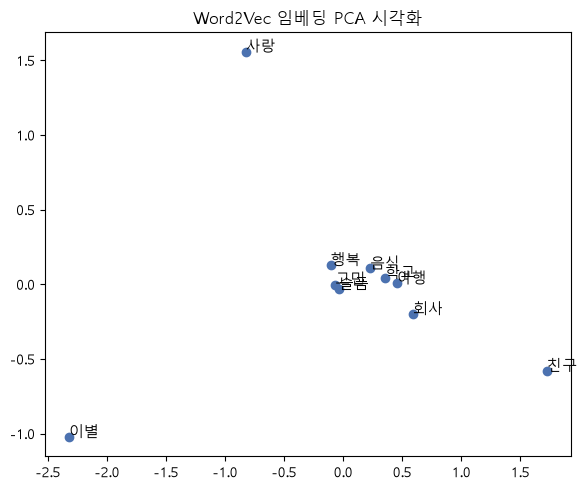

In [24]:
# 2026-09-21: 학습된 임베딩을 2차원으로 축소해 시각화
# PCA를 쓴 이유: t-SNE보다 계산이 빠르고 결정론적(seed에 덜 민감)이라 정성 확인 목적에는 충분하다.
#   t-SNE는 국소 구조를 더 잘 보여주지만 perplexity 설정에 따라 그림이 크게 달라져 근거로 쓰기 불안정하다.
from sklearn.decomposition import PCA

words_to_plot = ['사랑', '이별', '고민', '친구', '행복', '슬픔', '회사', '학교', '여행', '음식']
words_to_plot = [w for w in words_to_plot if w in w2v.wv]
vectors = np.array([w2v.wv[w] for w in words_to_plot])
coords = PCA(n_components=2, random_state=SEED).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(coords[:, 0], coords[:, 1], color='#4C72B0')
for word, (x, y) in zip(words_to_plot, coords):
    ax.annotate(word, (x, y), fontsize=11)
ax.set_title('Word2Vec 임베딩 PCA 시각화')
plt.tight_layout()
plt.savefig(RESULT_DIR / '02_word2vec_pca.png', dpi=120)
plt.show()

## 2.6 인코딩 전략 — 토큰을 모델 입력으로 조립하기

토큰화가 "문장을 어떻게 쪼갤 것인가"라면, 인코딩은 "쪼갠 것을 모델이 먹을 수 있는 정수 시퀀스로 어떻게 조립할 것인가"다. 여기서 정할 것은 네 가지다.

| 항목 | 결정 | 근거 |
|---|---|---|
| 특수 토큰 | `[BOS] + subword ids + [EOS]` | **BOS**는 디코더가 생성을 시작하는 지점을 알려주고, **EOS**는 "문장이 여기서 끝난다"는 신호다. EOS가 없으면 모델은 문장을 끝내는 법을 배우지 못한다 — 이 점이 4단계에서 결정적으로 중요해진다 |
| `MAX_LEN` | BPE 토큰 길이 95 percentile + 2, 8의 배수로 올림 | 1.3절의 원칙을 실제 모델 입력 단위(BPE 토큰)로 다시 적용. +2는 BOS/EOS 자리, 8의 배수는 GPU 연산 효율 |
| 패딩 | 배치 단위 동적 패딩 | `MAX_LEN` 고정 패딩은 짧은 문장이 모인 배치에서 연산을 낭비한다. 배치 안 최대 길이에만 맞추면 낭비가 줄어든다 |
| 손실 제외 | `ignore_index=PAD_ID` | padding 위치의 예측은 의미가 없으므로 손실 계산에서 제외해야 한다. 포함하면 "padding을 잘 맞히는" 쪽으로 학습이 왜곡된다 |

아래에서 `MAX_LEN`을 실측으로 확정한다.

In [25]:
# 2026-09-21: MAX_LEN 확정 - 1.3절 원칙을 BPE 토큰 단위로 다시 적용
q_token_lens = train_df['Q'].apply(lambda t: len(sp.encode(t, out_type=int)))
a_token_lens = train_df['A'].apply(lambda t: len(sp.encode(t, out_type=int)))

q95_bpe = int(np.percentile(q_token_lens, 95))
a95_bpe = int(np.percentile(a_token_lens, 95))
print(f'Q BPE 토큰 길이: 평균 {q_token_lens.mean():.2f}, 95p {q95_bpe}, 최대 {q_token_lens.max()}')
print(f'A BPE 토큰 길이: 평균 {a_token_lens.mean():.2f}, 95p {a95_bpe}, 최대 {a_token_lens.max()}')

# BOS/EOS 2개 자리를 더하고, GPU 연산 효율을 위해 8의 배수로 올림
MAX_LEN = int(np.ceil((max(q95_bpe, a95_bpe) + 2) / 8) * 8)
print()
print(f'=> MAX_LEN = {MAX_LEN}  (95p {max(q95_bpe, a95_bpe)} + BOS/EOS 2 = {max(q95_bpe, a95_bpe) + 2} -> 8의 배수로 올림)')
print(f'   이 길이로 잘리는 학습 타깃: {(a_token_lens + 2 > MAX_LEN).sum()}건 / {len(a_token_lens)}건 '
      f'({(a_token_lens + 2 > MAX_LEN).mean() * 100:.1f}%)')

Q BPE 토큰 길이: 평균 5.34, 95p 10, 최대 21


A BPE 토큰 길이: 평균 5.73, 95p 10, 최대 28

=> MAX_LEN = 16  (95p 10 + BOS/EOS 2 = 12 -> 8의 배수로 올림)
   이 길이로 잘리는 학습 타깃: 62건 / 8225건 (0.8%)


In [26]:
# 2026-09-21: 인코딩 함수 정의 - 문장 -> [BOS, ...BPE ids..., EOS]
# MAX_LEN을 넘으면 앞에서부터 MAX_LEN-2개만 남기고 자른다(BOS/EOS 자리 확보).
def encode_text(text: str, max_len: int = None):
    max_len = max_len or MAX_LEN
    ids = sp.encode(text, out_type=int)[: max_len - 2]
    return [BOS_ID] + ids + [EOS_ID]

sample_q = train_df.iloc[0]['Q']
enc = encode_text(sample_q)
print('원문      :', sample_q)
print('subword   :', sp.encode(sample_q, out_type=str))
print('정수 시퀀스:', enc)
print('복원 확인 :', sp.decode(enc[1:-1]))
print()
print(f'마지막 토큰이 EOS({EOS_ID})인가? ->', enc[-1] == EOS_ID)

원문      : 마음 먹었습니다
subword   : ['▁마음', '▁먹었', '습니다']
정수 시퀀스: [2, 50, 2482, 146, 3]
복원 확인 : 마음 먹었습니다

마지막 토큰이 EOS(3)인가? -> True


## 2단계 요약

| 항목 | 선택 | 근거 |
|---|---|---|
| 토큰화 단위 비교 | 어절 / 음절 / 형태소(Okt) / 자모 4종 실측 | 평균 토큰 수와 연산량(길이²)을 재서 형태소가 절충점임을 확인 |
| 베이스라인 토크나이저 | SentencePiece **BPE** (vocab 8,000, 직접 학습) | OOV에 강함(실측: 신조어 unknown 0개), 띄어쓰기에 안정적, 사전학습 모델과 방식 일관 |
| 전이학습 토크나이저 | KoBART `AutoTokenizer` 그대로 | 사전학습 임베딩이 해당 토크나이저의 vocab index에 종속되어 있음 |
| 임베딩 | gensim Word2Vec (skip-gram, dim=100, workers=1) | 저빈도 구어체 단어에 유리, 소규모 코퍼스에 적정 차원, 단일 스레드로 재현성 확보 |
| 인코딩 | `[BOS] + ids + [EOS]`, 배치 동적 패딩, `ignore_index=PAD` | EOS는 문장 종결 학습에 필수, 동적 패딩은 연산 낭비 감소 |
| `MAX_LEN` | BPE 토큰 95p + 2 → 8의 배수 | 1.3절의 percentile 원칙을 실제 입력 단위로 재적용 |

**다음 단계로 넘기는 것**: `chatbot_bpe.model`(토크나이저), `word2vec.model`(임베딩), `MAX_LEN`, `encode_text()`.

> **여기서 붙인 EOS를 기억해 둘 것.** 4단계에서 전이학습 파이프라인을 만들 때 이 처리를 빠뜨리면 무슨 일이 일어나는지 직접 확인한다.

---
# 3. 베이스라인 모델 — 처음부터 학습하는 인코더-디코더 Transformer

**이 단계의 목적**: 사전학습 가중치를 **전혀 쓰지 않고** 우리 데이터만으로 Q→A 모델을 학습한다. 이 모델의 성능이 4단계 전이학습과 비교되는 **기준점(baseline)**이 된다. 기준점이 없으면 "전이학습이 좋다"는 말에 근거가 없다.

## 3.1 구조 선택 — 왜 인코더-디코더인가

**먼저 문제를 정의한다**: Q(질문)를 조건으로 A(답변)를 생성하는 **조건부 생성(conditional generation)** 문제다. 입력과 출력이 서로 다른 역할을 가진 두 개의 시퀀스이고, 출력은 한 토큰씩 순차적으로 만들어야 한다.

Transformer 계열 구조는 크게 셋으로 나뉜다. 세 가지를 모두 검토하고 선택한다.

| 구조 | 대표 모델 | 사전학습 방식 | 이 과제에 쓸 수 있는가 |
|---|---|---|---|
| **인코더 전용** | BERT, **ELECTRA** | 마스킹된 토큰 복원 / 치환 토큰 판별 | **불가.** 아래 설명 |
| **디코더 전용** | GPT, KoGPT2 | 다음 토큰 예측 | 가능하지만 이 데이터 규모에 불리 |
| **인코더-디코더** | BART, T5, **KoBART** | 손상된 문장 복원(denoising) | **채택** |

### 인코더 전용(ELECTRA/BERT)을 쓰지 않는 이유

ELECTRA는 "이 토큰이 원래 것인가, 생성기가 바꿔치기한 것인가"를 **판별(discriminate)**하도록 사전학습된 모델이다. 출력이 각 위치에 대한 판별 결과일 뿐, 새로운 토큰을 **순차적으로 생성하는 디코더가 아예 없다**. 분류·개체명 인식·문장 유사도처럼 입력을 이해해 라벨을 내는 과제에는 강력하지만, **자유 형식의 문장을 만들어내는 이 과제에는 구조적으로 적용할 수 없다.** 디코더를 새로 붙여 학습하는 방법이 있으나, 그 디코더는 사전학습된 것이 아니므로 "전이학습"의 이점이 인코더 쪽에만 남는다.

### 디코더 전용(GPT류)을 쓰지 않는 이유

`Q [구분자] A` 처럼 하나의 시퀀스로 이어붙여 다음 토큰 예측으로 학습하면 가능은 하다. 다만 이 방식은 **소스와 타깃의 경계를 모델이 데이터만 보고 스스로 학습**해야 한다. 우리 학습 데이터는 9,400쌍으로, 그 경계 규칙까지 안정적으로 배우기에는 부족하다고 판단했다. 또한 Q를 항상 왼쪽에서 오른쪽으로만(단방향) 읽으므로, 질문 전체를 양방향으로 읽어 요약하는 인코더보다 조건 표현이 약하다.

### 인코더-디코더를 선택한 이유

인코더가 Q **전체를 양방향으로** 읽어 압축 표현(memory)을 만들고, 디코더가 그 표현에 **cross-attention으로 조건화**하면서 A를 한 토큰씩 생성한다. 이 구조가 "질문을 이해한 뒤 그것을 조건으로 답을 만든다"는 문제 정의에 직접 대응한다. 기계번역·요약이 같은 구조를 쓰는 것과 동일한 이유다.

**부수 효과**: 4단계에서 파인튜닝할 KoBART도 인코더-디코더다. 베이스라인과 전이학습 모델의 **구조를 일치시켜야** "차이가 사전학습 때문인지 구조 때문인지"를 구분할 수 있다. 이것이 구조를 통일한 실험 설계상의 이유다.

## 3.2 모델 정의

원 Transformer 논문(Vaswani et al., 2017)의 구조를 따르되 두 곳을 이 과제에 맞게 바꾼다.

**변경 1 — 임베딩 공유(weight tying)**: 번역과 달리 우리는 소스(Q)와 타깃(A)이 **같은 한국어**이고 **같은 BPE vocab**을 쓴다. 그래서 인코더/디코더 임베딩 테이블을 하나로 공유하고, 출력 projection의 가중치도 그 임베딩과 공유한다(Press & Wolf, 2017). 파라미터가 줄어 소규모 데이터에서의 과적합 위험이 낮아지고, 임베딩 공간과 출력 공간의 일관성도 높아진다. **서로 다른 언어를 다루는 번역 과제에서는 쓸 수 없는 최적화**다.

**변경 2 — 모델 축소**: 아래 3.3절에서 근거와 함께 설명한다.

In [27]:
# 2026-09-21: 사인/코사인 Positional Encoding
# Transformer는 순환/합성곱 구조가 없어 토큰의 '순서'를 알 방법이 없으므로, 위치 정보를 임베딩에 더해준다.
# 학습형 위치 임베딩 대신 사인/코사인 고정형을 쓴 이유: 학습 파라미터가 늘지 않고,
#   학습 때 보지 못한 길이에도 외삽이 가능하다 (원 논문 방식).
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.d_model = d_model

    def forward(self, tokens):
        # sqrt(d_model)을 곱해 위치 인코딩과 스케일을 맞춘다 (원 논문 방식).
        # 이걸 빼면 위치 신호가 토큰 의미보다 상대적으로 커져 학습이 불안정해진다.
        return self.embedding(tokens) * math.sqrt(self.d_model)

In [28]:
# 2026-09-21: Seq2Seq Transformer 본체
# Q/A가 같은 언어 + 같은 BPE vocab -> 인코더/디코더 임베딩을 공유(tie)하고
# 출력 projection(generator)도 임베딩 가중치와 공유(weight tying)해 파라미터를 줄인다.
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead,
                 num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.tok_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True,  # (batch, seq, feature) 순서 - 배치 축을 다루기 편하게
        )
        self.generator = nn.Linear(d_model, vocab_size)
        self.generator.weight = self.tok_emb.embedding.weight  # weight tying

    def forward(self, src, tgt, src_mask, tgt_mask,
                src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.pos_enc(self.tok_emb(src))
        tgt_emb = self.pos_enc(self.tok_emb(tgt))
        outs = self.transformer(
            src_emb, tgt_emb, src_mask=src_mask, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(self.pos_enc(self.tok_emb(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.pos_enc(self.tok_emb(tgt)), memory, tgt_mask)

In [29]:
# 2026-09-21: 마스크 두 종류
# (1) causal mask: 디코더가 아직 생성하지 않은 '미래' 토큰을 미리 보면 안 된다.
#     학습 때는 정답 전체를 한 번에 넣어 병렬 계산하므로, 각 위치가 자기 이후를 못 보게 막아야
#     추론 시의 순차 생성과 조건이 일치한다. 이걸 빼면 정답을 컨닝하며 학습해 추론 시 무너진다.
# (2) padding mask: 길이를 맞추려고 넣은 PAD 토큰에 attention이 가지 않게 한다.
def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    return mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)


def create_mask(src, tgt, device):
    src_seq_len, tgt_seq_len = src.size(1), tgt.size(1)
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, device)
    # 인코더는 입력 문장 전체를 다 볼 수 있어야 하므로 causal 마스킹을 하지 않는다(0 = 제한 없음).
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device)
    return src_mask, tgt_mask, (src == PAD_ID), (tgt == PAD_ID)

In [30]:
# 2026-09-21: 데이터셋/데이터로더 (2.6절에서 정한 인코딩 전략을 그대로 구현)
class ChatbotDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        src = torch.tensor(encode_text(self.questions[idx]), dtype=torch.long)
        tgt = torch.tensor(encode_text(self.answers[idx]), dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    # 배치 안 최대 길이에만 맞춰 패딩(동적 패딩) - MAX_LEN 고정 패딩 대비 연산 낭비를 줄인다.
    src_batch, tgt_batch = zip(*batch)
    return (pad_sequence(src_batch, batch_first=True, padding_value=PAD_ID),
            pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_ID))


# BATCH_SIZE=64 근거: 시퀀스가 짧고(MAX_LEN 16) 모델도 작아 12GB GPU에서 충분히 여유가 있다.
#   너무 작으면 gradient 추정이 노이즈에 민감해지고, 너무 크면 소규모 데이터(9,400쌍)에서
#   1 epoch당 파라미터 업데이트 횟수가 줄어 수렴이 느려진다.
BATCH_SIZE = 64
train_loader = DataLoader(ChatbotDataset(train_df), batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(ChatbotDataset(val_df), batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn)

src_ex, tgt_ex = next(iter(train_loader))
print('배치 수(train):', len(train_loader))
print('src batch shape:', tuple(src_ex.shape), '| tgt batch shape:', tuple(tgt_ex.shape))

배치 수(train): 129
src batch shape: (64, 16) | tgt batch shape: (64, 13)


## 3.3 하이퍼파라미터와 그 근거

| 항목 | 값 | 근거 |
|---|---|---|
| `d_model` | 256 | 원 논문/강의 예제는 512지만 그건 WMT급(수백만 문장) 데이터 기준이다. 우리는 9,400쌍이라 그 크기를 쓰면 파라미터 대비 데이터가 부족해 과적합·비효율 학습이 된다. 절반으로 축소 |
| layer 수 | enc 3 / dec 3 | 같은 이유로 원 논문(6/6)의 절반 |
| `nhead` | 8 | 256/8 = head당 32차원. 원 논문 비율(512/8=64)의 절반으로, 모델 축소에 비례 |
| `dim_feedforward` | 512 | `d_model`의 2배. 원 논문은 4배(2048/512)지만 모델을 줄인 만큼 비례 축소 |
| `dropout` | 0.1 | 원 논문 기본값. 소규모 데이터의 과적합 억제 |
| 손실함수 | CrossEntropy + `label_smoothing=0.1` | 정답 토큰 하나에 과도하게 확신(overconfident)하는 것을 막는다. 짧은 챗봇 응답은 유사 표현이 많아, 과확신하면 무난한 답만 내는 다양성 붕괴가 생기기 쉽다 |
| `ignore_index` | `PAD_ID` | padding 위치는 손실에서 제외 (2.6절) |
| 옵티마이저 | Adam, lr=1e-4, betas=(0.9, 0.98) | Transformer 학습의 표준 설정. 초반 loss가 불안정할 수 있어 큰 lr 대신 안정적인 1e-4 |
| gradient clipping | max_norm=1.0 | 학습 초반 gradient 폭주 방지 |

In [31]:
# 2026-09-21: 모델/손실함수/옵티마이저 생성 (위 표의 근거대로)
D_MODEL, NHEAD = 256, 8
NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS = 3, 3
DIM_FEEDFORWARD, DROPOUT = 512, 0.1

def make_baseline_model():
    torch.manual_seed(SEED)  # 동일 초기화 보장 (7단계 이전 실험과의 비교 가능성)
    return Seq2SeqTransformer(VOCAB_SIZE, D_MODEL, NHEAD,
                              NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS,
                              DIM_FEEDFORWARD, DROPOUT).to(device)

baseline_model = make_baseline_model()
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

n_params_baseline = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'베이스라인 학습 가능 파라미터: {n_params_baseline:,}개')

베이스라인 학습 가능 파라미터: 6,010,688개


## 3.4 학습

**Early stopping(patience=10)을 쓰는 이유**: 데이터가 작아 과적합이 비교적 빠르게 시작된다. validation loss가 10 epoch 연속 개선되지 않으면 멈추고 **가장 좋았던 시점의 가중치**를 쓴다. 이렇게 하면 "몇 epoch이 최적인가"를 사람이 미리 정하지 않아도 되고, 뒤의 비교 실험에서도 같은 규칙을 적용해 공정성을 유지할 수 있다.

**`MAX_EPOCHS=150`으로 크게 잡는 이유**: 상한이 낮으면 **수렴하기 전에 예산 소진으로 멈추는 것**과 **과적합이 시작되어 멈추는 것**을 구분할 수 없다. 상한을 충분히 크게 두고 early stopping이 판단하게 하면, 학습이 끝난 이유가 명확해진다.

**epoch 30 시점의 스냅샷을 따로 저장하는 이유**: 8.4절의 개선 추적에서 **"학습량만 바꿨을 때 무엇이 달라지는가"**를 보기 위한 통제 비교군이 필요하다. 같은 학습 과정의 중간 시점을 저장하면, 추가 학습 비용 없이 완벽하게 통제된 비교군(모델 구조·데이터·시드·옵티마이저가 전부 동일하고 학습량만 다름)을 얻을 수 있다.

In [32]:
# 2026-09-21: 1 epoch 학습 / 평가 함수
def train_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0.0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        # teacher forcing: 디코더 입력은 정답을 한 칸 밀어 넣고(<BOS>...), 정답은 한 칸 당긴다(...<EOS>)
        tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
        src_mask, tgt_mask, src_pad, tgt_pad = create_mask(src, tgt_input, device)
        logits = model(src, tgt_input, src_mask, tgt_mask, src_pad, tgt_pad, src_pad)

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
        src_mask, tgt_mask, src_pad, tgt_pad = create_mask(src, tgt_input, device)
        logits = model(src, tgt_input, src_mask, tgt_mask, src_pad, tgt_pad, src_pad)
        total_loss += criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1)).item()
    return total_loss / len(dataloader)

In [33]:
# 2026-09-21: 베이스라인 학습 루프 (early stopping + best checkpoint 저장 + epoch 30 스냅샷)
MAX_EPOCHS, PATIENCE, SNAPSHOT_EPOCH = 150, 10, 30

best_ckpt = CKPT_DIR / 'baseline_best.pt'
snap_ckpt = CKPT_DIR / 'baseline_ep30.pt'

best_val_loss, patience_counter = float('inf'), 0
baseline_history = {'train_loss': [], 'val_loss': []}
t_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()
    tr = train_epoch(baseline_model, train_loader, optimizer)
    vl = evaluate(baseline_model, val_loader)
    baseline_history['train_loss'].append(tr)
    baseline_history['val_loss'].append(vl)

    if vl < best_val_loss:
        best_val_loss, patience_counter = vl, 0
        torch.save(baseline_model.state_dict(), best_ckpt)
    else:
        patience_counter += 1

    if epoch <= 3 or epoch % 10 == 0:
        print(f'epoch {epoch:3d} | train {tr:.4f} | val {vl:.4f} | best {best_val_loss:.4f} | {time.time()-t0:.1f}s')

    # epoch 30 시점의 best 가중치를 통제 비교군으로 복사 보관 (8.4절에서 사용)
    if epoch == SNAPSHOT_EPOCH:
        shutil.copy(best_ckpt, snap_ckpt)
        print(f'  -> epoch {SNAPSHOT_EPOCH} 스냅샷 저장 (val_loss={best_val_loss:.4f}) : 학습량 비교용 통제군')

    if patience_counter >= PATIENCE:
        print(f'-> epoch {epoch}에서 조기 종료 (val loss가 {PATIENCE} epoch 연속 개선되지 않음)')
        break

baseline_epochs_run = len(baseline_history['train_loss'])
baseline_best_val = best_val_loss
if not snap_ckpt.exists():
    # 학습이 SNAPSHOT_EPOCH 전에 끝난 경우에도 8.4절 비교군이 있어야 하므로 최종 가중치로 대체한다
    shutil.copy(best_ckpt, snap_ckpt)
    print(f'(학습이 {SNAPSHOT_EPOCH} epoch 전에 종료되어 최종 가중치를 스냅샷으로 사용)')
baseline_model.load_state_dict(torch.load(best_ckpt, map_location=device))
print()
print(f'학습 완료: {baseline_epochs_run} epoch, best val_loss={baseline_best_val:.4f}, '
      f'총 {(time.time()-t_start)/60:.1f}분')

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch   1 | train 30.5325 | val 23.2641 | best 23.2641 | 2.2s


epoch   2 | train 23.3735 | val 19.9197 | best 19.9197 | 1.8s


epoch   3 | train 20.6378 | val 17.9174 | best 17.9174 | 1.7s


epoch  10 | train 11.1741 | val 9.8670 | best 9.8670 | 1.7s


...

epoch  40 | train 5.9589 | val 6.2849 | best 6.2849 | 1.8s


epoch  50 | train 5.4939 | val 6.1801 | best 6.1801 | 1.8s


epoch  60 | train 5.0943 | val 6.1550 | best 6.1183 | 1.8s


epoch  70 | train 4.7566 | val 6.1470 | best 6.0866 | 1.8s


-> epoch 78에서 조기 종료 (val loss가 10 epoch 연속 개선되지 않음)

학습 완료: 78 epoch, best val_loss=6.0866, 총 2.3분


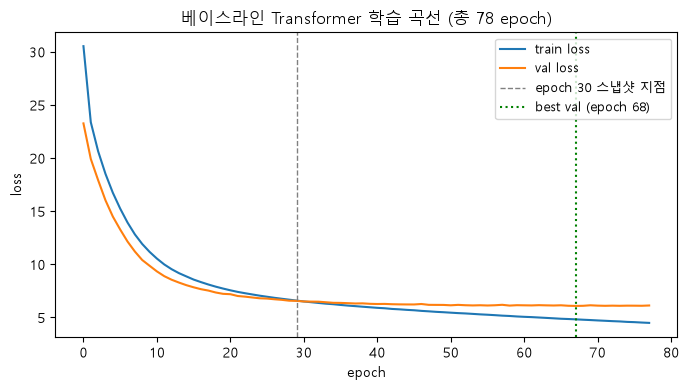

epoch 30 시점 val_loss : 6.5635
최종 best val_loss (epoch 68) : 6.0866
train/val loss가 벌어지기 시작하는 지점 = 과적합 시작 지점


In [34]:
# 2026-09-21: 학습 곡선 - 과적합이 언제 시작됐는지, 조기 종료가 타당했는지 확인
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(baseline_history['train_loss'], label='train loss')
ax.plot(baseline_history['val_loss'], label='val loss')
ax.axvline(x=SNAPSHOT_EPOCH - 1, color='gray', linestyle='--', linewidth=1,
           label=f'epoch {SNAPSHOT_EPOCH} 스냅샷 지점')
best_ep = int(np.argmin(baseline_history['val_loss']))
ax.axvline(x=best_ep, color='green', linestyle=':', linewidth=1.5,
           label=f'best val (epoch {best_ep + 1})')
ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax.set_title(f'베이스라인 Transformer 학습 곡선 (총 {baseline_epochs_run} epoch)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULT_DIR / '03_baseline_loss_curve.png', dpi=120)
plt.show()

print(f'epoch {SNAPSHOT_EPOCH} 시점 val_loss : {baseline_history["val_loss"][SNAPSHOT_EPOCH-1]:.4f}')
print(f'최종 best val_loss (epoch {best_ep+1}) : {baseline_best_val:.4f}')
print(f'train/val loss가 벌어지기 시작하는 지점 = 과적합 시작 지점')

## 3.5 Greedy decoding으로 생성 확인

디코딩 전략 비교는 6단계에서 다룬다. 여기서는 가장 단순한 greedy(매 스텝 확률 1등 토큰 선택)로 모델이 말이 되는 문장을 만드는지 정성적으로 확인한다.

In [35]:
# 2026-09-21: greedy decoding 구현
# BOS에서 시작해 EOS가 나오거나 max_len에 도달할 때까지 한 토큰씩 붙여 나간다.
@torch.no_grad()
def greedy_decode(model, src_text: str, max_len: int = None):
    max_len = max_len or MAX_LEN
    model.eval()
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)

    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, memory, tgt_mask)
        next_word = model.generator(out[:, -1]).argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], device=device)], dim=1)
        if next_word == EOS_ID:
            break

    ids = ys.squeeze(0).tolist()[1:]           # BOS 제거
    if ids and ids[-1] == EOS_ID:
        ids = ids[:-1]                          # EOS 제거
    return sp.decode(ids)


# 이후 모든 단계에서 동일한 8개 질문으로 정성 비교한다 (seed 고정)
SAMPLE_TEST = test_df.sample(8, random_state=SEED)
for _, row in SAMPLE_TEST.iterrows():
    print(f"Q      : {row['Q']}")
    print(f"정답 A : {row['A']}")
    print(f"생성 A : {greedy_decode(baseline_model, row['Q'])}")
    print()

Q      : 게임 같이 하자고 할까?
정답 A : 안 될 것도 없죠.
생성 A : 잠시 휴식을 취해보세요.

Q      : 블루투스 이어폰 편하겠지
정답 A : 사면 편하겠죠.
생성 A : 많이 생각하고.

Q      : 왜 갑자기 연락했을까?
정답 A : 이렇게 고민하게 만들려고 그랬나봐요.
생성 A : 아직 많이이네요.

Q      : 이상하게 놓치고 싶지 않는 사람이 있어
정답 A : 어쩌면 운명인가봅니다.


생성 A : 맛있게 드세요.

Q      : 짝남이 있는데 나는 사정이 안돼. 연애를 안하는게 맞는걸까?
정답 A : 사정이 뭔지 모르겠지만 좋아하는 건 괜찮아요.
생성 A : 저도 거 같아요.

Q      : 베터리 겨우 15%야
정답 A : 미리 충전하세요.
생성 A : 미리 미리 충전하세요.

Q      : 멍청한게 탈이지
정답 A : 다음에는 다를거예요.
생성 A : 그래도 안 좋은 알아 알아 거예요.

Q      : 습관이라는게 무섭네.
정답 A : 습관처럼은 되지 않길 바랄게요.
생성 A : 좋은 만남이었길 바라요.



In [36]:
# 2026-09-21: 3단계 결과 요약 저장
step3_summary = {
    '구조': '인코더-디코더 Transformer (처음부터 학습)',
    '파라미터 수': int(n_params_baseline),
    'd_model': D_MODEL, 'layers': f'{NUM_ENCODER_LAYERS}/{NUM_DECODER_LAYERS}',
    'MAX_LEN': int(MAX_LEN),
    '학습 epoch': int(baseline_epochs_run),
    'best val_loss': round(float(baseline_best_val), 4),
    'epoch30 val_loss': round(float(baseline_history['val_loss'][SNAPSHOT_EPOCH - 1]), 4),
}
with open(RESULT_DIR / 'step3_baseline_summary.json', 'w', encoding='utf-8') as f:
    json.dump(step3_summary, f, ensure_ascii=False, indent=2)
print(json.dumps(step3_summary, ensure_ascii=False, indent=2))

{
  "구조": "인코더-디코더 Transformer (처음부터 학습)",
  "파라미터 수": 6010688,
  "d_model": 256,
  "layers": "3/3",
  "MAX_LEN": 16,
  "학습 epoch": 78,
  "best val_loss": 6.0866,
  "epoch30 val_loss": 6.5635
}


## 3단계 요약

| 항목 | 결정 | 근거 |
|---|---|---|
| 구조 | **인코더-디코더** | Q→A는 조건부 생성 문제. 인코더 전용(ELECTRA/BERT)은 디코더가 없어 생성 불가, 디코더 전용(GPT)은 소스/타깃 경계를 데이터로만 학습해야 해 9,400쌍에 불리 |
| 모델 크기 | 원 논문의 절반 (d_model 256, layer 3/3) | 원 크기는 수백만 문장 가정. 데이터 규모에 맞춘 용량 조정 |
| weight tying | 임베딩 + 출력 projection 공유 | Q/A가 같은 언어·같은 vocab이라 가능. 파라미터 절감 + 표현 일관성 |
| early stopping | patience=10, MAX_EPOCHS=150 | 상한을 크게 두고 early stopping이 판단하게 해야 "왜 멈췄는지"가 명확해짐 |
| epoch 30 스냅샷 | 별도 저장 | 8.4절 "학습량만 바꿨을 때"의 통제 비교군을 추가 비용 없이 확보 |

**다음 단계로 넘기는 것**: `baseline_best.pt`(최종 베이스라인), `baseline_ep30.pt`(학습량 비교군), `greedy_decode()`, `SAMPLE_TEST`(공통 정성 비교 질문 8개).

---
# 4. 전이학습 모델 — 사전학습 KoBART 파인튜닝

**전이학습이 이 과제에 필요한 이유**: 3단계 베이스라인은 9,400쌍의 대화 데이터만으로 한국어의 문법·어휘·화용까지 전부 처음부터 배워야 한다. 사람으로 치면 한국어를 모르는 상태에서 대화 예시 9,400개만 보고 대화법을 익히는 셈이다. 전이학습은 **이미 대규모 코퍼스로 한국어를 배운 모델**을 가져와 "챗봇 응답"이라는 과제에만 적응시킨다. 같은 데이터로 훨씬 높은 성능을 기대할 수 있다는 것이 가설이고, 4~5단계에서 이를 검증한다.

## 4.1 사전학습 모델 선정 — 왜 KoBART인가

| 조건 | 요구사항 | KoBART가 만족하는가 |
|---|---|---|
| 구조 | 3단계에서 고른 **인코더-디코더**와 일치해야 구조 변수가 통제된다 | BART = 인코더-디코더 |
| 언어 | 한국어로 사전학습되어야 함 | 한국어 코퍼스로 사전학습 |
| 사전학습 목적 | 생성 과제에 바로 이어붙일 수 있어야 함 | denoising autoencoder(손상된 문장 복원) = 생성형 |
| 접근성 | 재현 가능해야 함 | Hugging Face에서 `from_pretrained` 한 줄로 내려받기 가능 |

**`gogamza/kobart-base-v2`를 고른 이유**: 위 네 조건을 모두 만족하면서, 한국어 챗봇 응답 생성에 공개적으로 검증된 선례가 많아 결과를 대조하기 쉽다.

**BART의 사전학습 방식이 이 과제와 잘 맞는 이유**: BART는 문장에 노이즈(토큰 마스킹, 문장 순서 섞기 등)를 가한 뒤 **원문을 복원**하도록 사전학습된다. 즉 "입력 시퀀스를 조건으로 출력 시퀀스를 생성"하는 형태 자체를 이미 학습했다. 우리 과제(Q를 조건으로 A를 생성)는 입력과 출력의 내용만 다를 뿐 **같은 형태**라서, 파인튜닝이 구조 변경 없이 그대로 이어진다.

### 전이학습 파이프라인 설계

사전학습 모델을 가져다 쓰는 과정은 다음 6단계다. 각 단계에서 무엇을 확인해야 하는지 함께 적는다.

| 단계 | 하는 일 | 확인할 것 |
|---|---|---|
| 1 | 모델·토크나이저 다운로드 (`from_pretrained`) | 파라미터 수, 구조가 인코더-디코더인지 |
| 2 | **그 모델 전용 토크나이저**로 데이터 인코딩 | 2.4절 — 다른 토크나이저를 쓰면 사전학습 지식이 무의미해진다 |
| 3 | `max_length` 재산정 | 토크나이저가 다르면 같은 문장의 토큰 수도 다르다. 1.3절 원칙을 이 토크나이저로 다시 적용 |
| 4 | **타깃(label) 인코딩** | 손실 계산에서 제외할 padding을 `-100`으로, 그리고 **문장 끝에 EOS가 들어갔는지** |
| 5 | 옵티마이저/lr 설정 | 사전학습 가중치를 망가뜨리지 않을 만큼 작은 lr |
| 6 | 학습 + early stopping | 소규모 데이터에서의 과적합 감시 |

**4번이 이 프로젝트에서 실제로 문제가 된 지점이다.** 아래에서 먼저 "흔히 쓰는 방식 그대로" 만들어 학습해 보고, 무슨 일이 벌어지는지 확인한다.

In [37]:
# 2026-09-21: [1단계] KoBART 모델/토크나이저 다운로드 및 구조 확인
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup

KOBART_NAME = 'gogamza/kobart-base-v2'
kobart_tokenizer = AutoTokenizer.from_pretrained(KOBART_NAME)
_probe = AutoModelForSeq2SeqLM.from_pretrained(KOBART_NAME)
n_params_kobart = sum(p.numel() for p in _probe.parameters())

print(f'모델 : {KOBART_NAME}')
print(f'구조 : {_probe.config.model_type} (encoder {_probe.config.encoder_layers}층 / '
      f'decoder {_probe.config.decoder_layers}층) -> 인코더-디코더 확인')
print(f'파라미터 수 : {n_params_kobart:,}개 '
      f'(베이스라인 {n_params_baseline:,}개의 약 {n_params_kobart / n_params_baseline:.0f}배)')
print(f'vocab size  : {kobart_tokenizer.vocab_size}')
del _probe
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  85%|████████▌ | 221/259 [00:00<00:00, 2110.60it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1802.16it/s]

모델 : gogamza/kobart-base-v2
구조 : bart (encoder 6층 / decoder 6층) -> 인코더-디코더 확인
파라미터 수 : 123,859,968개 (베이스라인 6,010,688개의 약 21배)
vocab size  : 30000


In [38]:
# 2026-09-21: [3단계] KoBART 토크나이저 기준으로 max_length 재산정
# 토크나이저가 다르면 같은 문장도 토큰 수가 다르므로, 1.3절의 percentile 원칙을 이 토크나이저로 다시 적용한다.
kq_lens = train_df['Q'].apply(lambda t: len(kobart_tokenizer.encode(t)))
ka_lens = train_df['A'].apply(lambda t: len(kobart_tokenizer.encode(t)))
kq95, ka95 = int(np.percentile(kq_lens, 95)), int(np.percentile(ka_lens, 95))

KOBART_MAX_LEN = int(np.ceil((max(kq95, ka95) + 2) / 8) * 8)
print(f'KoBART 토큰 기준 Q 95p: {kq95}, A 95p: {ka95} (최대 Q {kq_lens.max()}, A {ka_lens.max()})')
print(f'=> KOBART_MAX_LEN = {KOBART_MAX_LEN}')
print(f'   이 길이로 잘리는 학습 타깃: {(ka_lens > KOBART_MAX_LEN).sum()}건 / {len(ka_lens)}건 '
      f'({(ka_lens > KOBART_MAX_LEN).mean() * 100:.1f}%)')

KoBART 토큰 기준 Q 95p: 12, A 95p: 12 (최대 Q 26, A 30)
=> KOBART_MAX_LEN = 16
   이 길이로 잘리는 학습 타깃: 65건 / 8225건 (0.8%)


## 4.2 1차 파인튜닝 — 흔히 쓰는 방식 그대로

Hugging Face 문서와 대부분의 seq2seq 파인튜닝 예제가 쓰는 방식은 다음과 같다.

```python
model_inputs = tokenizer(questions, padding=True, truncation=True, max_length=L)
model_inputs['labels'] = tokenizer(text_target=answers, padding=True,
                                   truncation=True, max_length=L)['input_ids']
```

이 방식을 그대로 구현해 먼저 학습한다. **이것이 정상 동작하는지 확인하는 것이 4.3절의 목적이다.**

### 학습 설정과 근거

| 항목 | 값 | 근거 |
|---|---|---|
| 옵티마이저 | AdamW, `weight_decay=0.01` | 사전학습 Transformer 파인튜닝의 사실상 표준. weight decay를 gradient에서 분리해 정규화가 더 안정적 |
| learning rate | 5e-5 | 베이스라인(1e-4)보다 **작게** 잡는다. 사전학습 가중치는 이미 좋은 출발점이라, 큰 lr로 갱신하면 사전학습 지식이 손상되는 catastrophic forgetting이 일어난다. BART류 seq2seq에 2e-5~5e-5가 권장 범위 |
| batch size | 16 | KoBART(1.2억 파라미터)는 베이스라인(6백만)보다 훨씬 커서 배치를 줄여야 메모리에 안전하게 들어간다 |
| `MAX_EPOCHS` / `PATIENCE` | 10 / 3 | 사전학습 모델은 이미 언어를 알고 있어 소규모 데이터로도 몇 epoch 만에 수렴하는 것이 일반적이다. 베이스라인(150 epoch 상한)과의 대비 자체가 전이학습의 효율을 보여주는 근거가 된다 |
| mixed precision | **bf16** autocast | 메모리와 속도를 위해 필요. fp16이 아니라 bf16을 쓴 이유는 fp32와 지수 범위가 같아 오버플로우 위험이 없고 GradScaler 없이 안정적이기 때문이다(T5 계열은 fp16에서 NaN 발산이 잘 알려져 있다). 이 GPU(Ada Lovelace)는 bf16을 지원한다 |
| 타깃 padding | `-100` | Hugging Face의 관례값. `-100` 위치는 손실 계산에서 자동으로 제외된다 (2.6절의 `ignore_index`와 같은 역할) |

In [39]:
# 2026-09-21: [2·4단계] 데이터셋과 collate 함수 (1차 = 흔히 쓰는 방식 그대로)
class Seq2SeqTextDataset(Dataset):
    def __init__(self, df):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return self.questions[idx], self.answers[idx]


def pad_labels(seqs):
    # 손실 계산에서 제외할 padding은 -100으로 채운다 (Hugging Face 관례)
    width = max(len(s) for s in seqs)
    labels = torch.full((len(seqs), width), -100, dtype=torch.long)
    for i, s in enumerate(seqs):
        labels[i, : len(s)] = torch.tensor(s, dtype=torch.long)
    return labels


def make_collate_naive(tokenizer, max_len):
    '''흔히 쓰는 방식: 토크나이저의 text_target= 결과를 그대로 label로 쓴다.'''
    def collate_fn(batch):
        questions, answers = zip(*batch)
        model_inputs = tokenizer(list(questions), padding=True, truncation=True,
                                 max_length=max_len, return_tensors='pt')
        seqs = [tokenizer(text_target=a, truncation=True, max_length=max_len)['input_ids']
                for a in answers]
        model_inputs['labels'] = pad_labels(seqs)
        return model_inputs
    return collate_fn


KOBART_BATCH_SIZE = 16
naive_collate = make_collate_naive(kobart_tokenizer, KOBART_MAX_LEN)
kobart_train_naive = DataLoader(Seq2SeqTextDataset(train_df), batch_size=KOBART_BATCH_SIZE,
                                shuffle=True, collate_fn=naive_collate)
kobart_val_naive = DataLoader(Seq2SeqTextDataset(val_df), batch_size=KOBART_BATCH_SIZE,
                              shuffle=False, collate_fn=naive_collate)
print('배치 수(train):', len(kobart_train_naive))

배치 수(train): 515


In [40]:
# 2026-09-21: [5·6단계] 재사용 가능한 seq2seq 파인튜닝 함수
# collate_fn을 인자로 받도록 설계한 이유: 4.4절에서 '타깃 인코딩만 바꾼' 통제 실험을 하려면
#   학습 코드는 완전히 동일한 채로 데이터 조립 방식만 교체할 수 있어야 한다.
def finetune_seq2seq(model_name, collate_fn, lr, label,
                     use_schedule=False, max_epochs=10, patience=3, batch_size=16):
    torch.manual_seed(SEED)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    tok = AutoTokenizer.from_pretrained(model_name)

    tr_loader = DataLoader(Seq2SeqTextDataset(train_df), batch_size=batch_size,
                           shuffle=True, collate_fn=collate_fn)
    va_loader = DataLoader(Seq2SeqTextDataset(val_df), batch_size=batch_size,
                           shuffle=False, collate_fn=collate_fn)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = None
    if use_schedule:
        total_steps = len(tr_loader) * max_epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

    ckpt_dir = CKPT_DIR / label
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    tok.save_pretrained(ckpt_dir)  # 나중에 경로 하나로 모델+토크나이저를 모두 불러오기 위해 함께 저장

    use_amp = device.type == 'cuda'
    best_val, patience_cnt = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}
    t_start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        total = 0.0
        for batch in tr_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    loss = model(**batch).loss
            else:
                loss = model(**batch).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total += loss.item()
        train_loss = total / len(tr_loader)

        model.eval()
        total = 0.0
        with torch.no_grad():
            for batch in va_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                total += model(**batch).loss.item()
        val_loss = total / len(va_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'[{label}] epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            model.save_pretrained(ckpt_dir)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'  -> epoch {epoch}에서 조기 종료 (best val_loss={best_val:.4f})')
                break

    print(f'  [{label}] 완료: {len(history["train_loss"])} epoch, '
          f'best val_loss={best_val:.4f}, {(time.time()-t_start)/60:.1f}분')
    model = AutoModelForSeq2SeqLM.from_pretrained(ckpt_dir).to(device)
    model.eval()
    return model, history, best_val

In [41]:
# 2026-09-21: 1차 파인튜닝 실행 (흔히 쓰는 방식 그대로)
kobart_naive, hist_naive, best_naive = finetune_seq2seq(
    KOBART_NAME, naive_collate, lr=5e-5, label='kobart_naive',
    batch_size=KOBART_BATCH_SIZE)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  88%|████████▊ | 228/259 [00:00<00:00, 2152.34it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1919.51it/s]

[kobart_naive] epoch 01 | train 4.2561 | val 3.6481


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[kobart_naive] epoch 06 | train 0.6664 | val 3.0792


[kobart_naive] epoch 07 | train 0.4303 | val 3.1751
  -> epoch 7에서 조기 종료 (best val_loss=2.9058)
  [kobart_naive] 완료: 7 epoch, best val_loss=2.9058, 3.1분


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:  81%|████████  | 211/260 [00:00<00:00, 2084.37it/s]

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1742.28it/s]

In [42]:
# 2026-09-21: 생성 헬퍼 (Hugging Face generate 래퍼)
@torch.no_grad()
def hf_generate(model, tokenizer, question, max_len=None, **gen_kwargs):
    max_len = max_len or KOBART_MAX_LEN
    inputs = tokenizer(question, return_tensors='pt').to(device)
    out = model.generate(**inputs, max_length=max_len, **gen_kwargs)
    return tokenizer.decode(out[0], skip_special_tokens=True)


# 3단계와 동일한 8개 질문으로 비교 (greedy = num_beams=1, do_sample=False)
print(f'best val_loss: 베이스라인 {baseline_best_val:.4f} vs KoBART(1차) {best_naive:.4f}')
print()
for _, row in SAMPLE_TEST.iterrows():
    print(f"Q             : {row['Q']}")
    print(f"정답 A        : {row['A']}")
    print(f"베이스라인    : {greedy_decode(baseline_model, row['Q'])}")
    print(f"KoBART(1차)   : {hf_generate(kobart_naive, kobart_tokenizer, row['Q'], num_beams=1, do_sample=False)}")
    print()

best val_loss: 베이스라인 6.0866 vs KoBART(1차) 2.9058

Q             : 게임 같이 하자고 할까?
정답 A        : 안 될 것도 없죠.
베이스라인    : 잠시 휴식을 취해보세요.
KoBART(1차)   : 게임 같이 하면 더 재밌을 것 같아요. 같이 하면 더 좋을 것

Q             : 블루투스 이어폰 편하겠지
정답 A        : 사면 편하겠죠.
베이스라인    : 많이 생각하고.
KoBART(1차)   : 색감 참 좋겠네요. 색감 참 좋겠네요. 색감

Q             : 왜 갑자기 연락했을까?
정답 A        : 이렇게 고민하게 만들려고 그랬나봐요.
베이스라인    : 아직 많이이네요.
KoBART(1차)   : 연락은 항상 중요하니까요. 조금 더 상황을 지켜보세요. 조금 더 상황을

Q             : 이상하게 놓치고 싶지 않는 사람이 있어
정답 A        : 어쩌면 운명인가봅니다.
베이스라인    : 맛있게 드세요.


KoBART(1차)   : 놓치고 싶지 않았을 거예요. 그럴게요. 마음의 준비를 하세요. 마음이 정리

Q             : 짝남이 있는데 나는 사정이 안돼. 연애를 안하는게 맞는걸까?
정답 A        : 사정이 뭔지 모르겠지만 좋아하는 건 괜찮아요.
베이스라인    : 저도 거 같아요.
KoBART(1차)   : 상황이 여의치 않나봐요. 본인의 사정이 아닌 본인의 사정이 아닌 이상

Q             : 베터리 겨우 15%야
정답 A        : 미리 충전하세요.
베이스라인    : 미리 미리 충전하세요.
KoBART(1차)   : 충전하고 오세요. 얼른 충전하고 오세요. 어머어머

Q             : 멍청한게 탈이지
정답 A        : 다음에는 다를거예요.
베이스라인    : 그래도 안 좋은 알아 알아 거예요.
KoBART(1차)   : 멍청하지 않아요. 신경쓰면 좋은텐데. 신경쓰

Q             : 습관이라는게 무섭네.
정답 A        : 습관처럼은 되지 않길 바랄게요.
베이스라인    : 좋은 만남이었길 바라요.


KoBART(1차)   : 습관이에요. 자연스러운 현상이에요. 어머나 그게 진짜예



## 4.3 이상 징후 — val_loss는 훨씬 좋은데 생성 결과가 이상하다

위 출력에서 확인되는 것:

- **val_loss는 KoBART가 베이스라인보다 압도적으로 낮다.** 전이학습 가설대로다.
- **그런데 생성된 문장이 끝나지 않는다.** 여러 문장이 이어지다가 중간에서 뚝 끊긴다.

loss가 좋은데 생성이 나쁘다는 것은 그냥 넘어갈 신호가 아니다. **val_loss는 teacher forcing 상태에서 "앞 토큰이 전부 정답일 때" 다음 토큰을 얼마나 잘 맞히는지를 재는 값이고, 실제 생성은 자기가 만든 토큰을 다시 입력으로 쓴다.** 이 둘이 크게 어긋난다면 생성 과정 자체에 문제가 있다는 뜻이다.

원인 후보는 둘이다.

- **(a) 지표/관찰의 문제** — 챗봇은 정답이 여러 개라 원래 이런 것이다
- **(b) 파이프라인의 결함** — 모델이 실제로 무언가를 잘못 배우고 있다

"챗봇은 원래 그렇다"며 (a)로 넘어가는 것이 쉬운 길이지만, 그러면 진짜 문제를 놓친다. **(b)부터 검증한다.**

In [43]:
# 2026-09-21: [단서 1] 생성 길이와 '문장이 제대로 끝났는가'를 측정
# 문장이 정상 종결됐는지 = 문장부호 또는 한국어 종결어미로 끝나는가
SENT_END = ('.', '!', '?', '요', '다', '네', '죠', '까', '용')

def gen_stats(texts):
    s = pd.Series([t.strip() for t in texts])
    return {
        '평균 길이(음절)': round(s.str.len().mean(), 2),
        '정상 종결률(%)': round(s.str.endswith(SENT_END).mean() * 100, 1),
    }

# 진단용 표본 200건 (전체 1,175건을 다 생성하면 오래 걸리므로 표본으로 경향을 먼저 확인)
diag_idx = test_df.sample(200, random_state=SEED).index
sample_qs_diag = test_df.loc[diag_idx, 'Q'].tolist()

naive_gen = [hf_generate(kobart_naive, kobart_tokenizer, q, num_beams=1, do_sample=False)
             for q in sample_qs_diag]
base_gen = [greedy_decode(baseline_model, q) for q in sample_qs_diag]

diag_df = pd.DataFrame({
    '정답(test A)': gen_stats(test_df['A'].tolist()),
    '베이스라인': gen_stats(base_gen),
    'KoBART(1차)': gen_stats(naive_gen),
}).T
display(diag_df)

,평균 길이(음절),정상 종결률(%)
정답(test A),15.16,99.5
베이스라인,14.34,90.0
KoBART(1차),32.84,19.5


**단서 1이 말해주는 것**: 베이스라인은 거의 모든 응답이 정상적으로 끝난다. KoBART는 정상 종결률이 현저히 낮고 평균 길이가 정답보다 훨씬 길다. **이것은 "정답이 여러 개라서"로 설명되지 않는다. 모델이 문장을 끝내지 못하고 있다.**

생성을 멈추는 신호는 **EOS 토큰**이다. 모델이 EOS를 내지 않는다면, 학습 때 EOS를 내도록 배우지 못했을 가능성이 가장 크다. 학습에 실제로 들어간 타깃 토큰을 직접 확인한다.

In [44]:
# 2026-09-21: [단서 2] 파인튜닝 타깃에 EOS가 실제로 들어갔는지 직접 확인 (결정적 증거)
sample_answer = '미리 충전하세요.'

# 입력(Q) 쪽 인코딩 - 비교용
src_ids = kobart_tokenizer(sample_answer)['input_ids']
# 타깃(A) 쪽 인코딩 - 1차 파인튜닝이 실제로 쓴 방식
tgt_ids = kobart_tokenizer(text_target=sample_answer, truncation=True,
                           max_length=KOBART_MAX_LEN)['input_ids']

print(f'문장         : {sample_answer}')
print(f'eos_token_id : {kobart_tokenizer.eos_token_id} ({kobart_tokenizer.eos_token})')
print()
print('[입력(Q)으로 인코딩할 때]')
print('  ids    :', src_ids)
print('  tokens :', kobart_tokenizer.convert_ids_to_tokens(src_ids))
print('  마지막이 EOS인가? ->', src_ids[-1] == kobart_tokenizer.eos_token_id)
print()
print('[타깃(text_target=)으로 인코딩할 때  <- 1차 파인튜닝이 쓴 방식]')
print('  ids    :', tgt_ids)
print('  tokens :', kobart_tokenizer.convert_ids_to_tokens(tgt_ids))
print('  마지막이 EOS인가? ->', tgt_ids[-1] == kobart_tokenizer.eos_token_id)

문장         : 미리 충전하세요.
eos_token_id : 1 (</s>)

[입력(Q)으로 인코딩할 때]
  ids    : [17365, 24917, 13586, 25161]
  tokens : ['▁미리', '▁충전', '하', '세요.']
  마지막이 EOS인가? -> False

[타깃(text_target=)으로 인코딩할 때  <- 1차 파인튜닝이 쓴 방식]
  ids    : [17365, 24917, 13586, 25161]
  tokens : ['▁미리', '▁충전', '하', '세요.']
  마지막이 EOS인가? -> False


In [45]:
# 2026-09-21: [단서 3] 대안 가설 배제 - "타깃이 max_length에서 잘려 EOS를 잃은 것 아닌가?"
tgt_lens = np.array([len(kobart_tokenizer(text_target=a)['input_ids']) for a in train_df['A']])
n_trunc = int((tgt_lens > KOBART_MAX_LEN).sum())

print(f'타깃 토큰 길이: 평균 {tgt_lens.mean():.2f}, 95p {np.percentile(tgt_lens, 95):.0f}, 최대 {tgt_lens.max()}')
print(f'max_length={KOBART_MAX_LEN}에서 잘리는 타깃: {n_trunc}건 / {len(tgt_lens)}건 '
      f'({n_trunc / len(tgt_lens) * 100:.1f}%)')
print()
print('-> 잘림 비율이 1% 안팎에 불과하므로, 이 가설로는 대다수 응답이 끝나지 않는 현상을 설명할 수 없다.')
print('-> 대안 가설 기각. 원인은 truncation이 아니라 토크나이저가 애초에 EOS를 붙이지 않는다는 것이다.')

타깃 토큰 길이: 평균 6.80, 95p 12, 최대 30
max_length=16에서 잘리는 타깃: 65건 / 8225건 (0.8%)

-> 잘림 비율이 1% 안팎에 불과하므로, 이 가설로는 대다수 응답이 끝나지 않는 현상을 설명할 수 없다.
-> 대안 가설 기각. 원인은 truncation이 아니라 토크나이저가 애초에 EOS를 붙이지 않는다는 것이다.


### 원인 규명 결과

| 항목 | 확인된 사실 |
|---|---|
| 증상 | KoBART 응답의 상당수가 문장 중간에서 끊김, 평균 길이가 정답보다 훨씬 김 |
| 직접 원인 | 모델이 EOS 토큰을 생성하지 않아 `max_length`에 도달할 때까지 계속 생성 |
| **근본 원인** | `gogamza/kobart-base-v2` 토크나이저는 `text_target=`으로 인코딩할 때 **EOS를 붙이지 않는다**(단서 2). 타깃에 EOS가 없으니 모델이 "문장을 끝내는 법"을 학습할 기회가 아예 없었다 |
| 대안 가설 (기각) | "타깃이 `max_length`에서 잘려 EOS 소실" → 실제 잘리는 타깃은 1% 안팎(단서 3) |
| 왜 베이스라인은 멀쩡했나 | 2.6절 `encode_text()`가 `[BOS] + ids + [EOS]`로 EOS를 **직접** 붙였기 때문. 같은 처리를 전이학습 쪽에만 빠뜨린 것 |

> **이것이 이 프로젝트에서 가장 중요한 발견이다.** 흔히 쓰는 파인튜닝 예제 코드를 그대로 따라 쓰면 이 결함이 조용히 들어온다. loss는 정상으로 보이기 때문에 loss만 보고 있으면 끝까지 발견하지 못한다.

## 4.4 수정 — 타깃에 EOS 추가 후 재학습

**바꾸는 것은 타깃 인코딩 한 줄뿐이다.** 모델·learning rate·배치 크기·epoch 상한·시드·데이터는 전부 그대로 둔다. 따라서 이 재학습은 **"EOS 하나만 바꿨을 때 무엇이 달라지는가"에 대한 통제 실험**이 된다.

**구현 주의점**: 토크나이저에 따라 EOS를 자동으로 붙이는 경우도 있다. 무조건 추가하면 EOS가 두 번 들어가므로, **없을 때만** 추가하도록 조건을 건다.

In [46]:
# 2026-09-21: [수정] 타깃 끝에 EOS를 명시적으로 추가하는 collate
# 토크나이저가 이미 EOS를 붙이는 경우(예: T5 계열)에는 중복되지 않도록 없을 때만 추가한다.
def make_collate_with_eos(tokenizer, max_len):
    def collate_fn(batch):
        questions, answers = zip(*batch)
        model_inputs = tokenizer(list(questions), padding=True, truncation=True,
                                 max_length=max_len, return_tensors='pt')
        seqs = []
        for a in answers:
            ids = tokenizer(text_target=a, truncation=True, max_length=max_len)['input_ids']
            if ids[-1] != tokenizer.eos_token_id:
                ids = ids[: max_len - 1] + [tokenizer.eos_token_id]
            seqs.append(ids)
        model_inputs['labels'] = pad_labels(seqs)
        return model_inputs
    return collate_fn


eos_collate = make_collate_with_eos(kobart_tokenizer, KOBART_MAX_LEN)

# 수정이 실제로 적용됐는지 한 배치로 검산
_b = eos_collate([('테스트 질문', '미리 충전하세요.')])
_lab = [i for i in _b['labels'][0].tolist() if i != -100]
print('수정 후 타깃 ids   :', _lab)
print('수정 후 타깃 tokens:', kobart_tokenizer.convert_ids_to_tokens(_lab))
print('마지막이 EOS인가?  ->', _lab[-1] == kobart_tokenizer.eos_token_id)

수정 후 타깃 ids   : [17365, 24917, 13586, 25161, 1]
수정 후 타깃 tokens: ['▁미리', '▁충전', '하', '세요.', '</s>']
마지막이 EOS인가?  -> True


In [47]:
# 2026-09-21: 수정 후 재파인튜닝 (타깃 인코딩만 다르고 나머지 조건은 1차와 완전히 동일)
kobart_b0, hist_b0, best_b0 = finetune_seq2seq(
    KOBART_NAME, eos_collate, lr=5e-5, label='kobart_B0_lr5e-5',
    batch_size=KOBART_BATCH_SIZE)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  76%|███████▋  | 198/259 [00:00<00:00, 1974.00it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1822.89it/s]

[kobart_B0_lr5e-5] epoch 01 | train 3.7523 | val 3.2230


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[kobart_B0_lr5e-5] epoch 05 | train 1.0017 | val 2.9074


[kobart_B0_lr5e-5] epoch 06 | train 0.6644 | val 3.0082
  -> epoch 6에서 조기 종료 (best val_loss=2.8490)
  [kobart_B0_lr5e-5] 완료: 6 epoch, best val_loss=2.8490, 2.7분


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:  83%|████████▎ | 215/260 [00:00<00:00, 2087.66it/s]

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1744.30it/s]

,평균 길이(음절),정상 종결률(%),best val_loss
정답(test A),15.16,99.5,NaN
KoBART 수정 전,32.84,19.5,2.9058
KoBART 수정 후,13.34,99.0,2.8490
베이스라인(대조군),14.34,90.0,6.0866


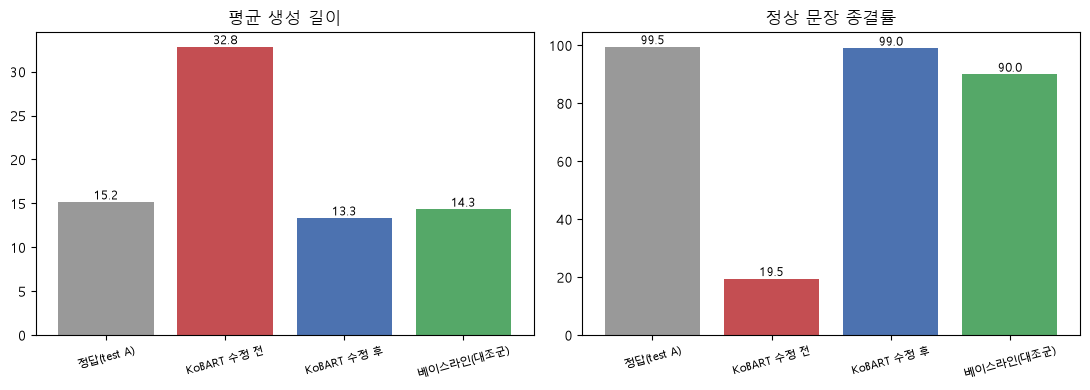

In [48]:
# 2026-09-21: EOS 수정 전후 비교 (통제 실험 결과)
fixed_gen = [hf_generate(kobart_b0, kobart_tokenizer, q, num_beams=1, do_sample=False)
             for q in sample_qs_diag]

eos_compare = pd.DataFrame({
    '정답(test A)'     : gen_stats(test_df['A'].tolist()),
    'KoBART 수정 전'   : gen_stats(naive_gen),
    'KoBART 수정 후'   : gen_stats(fixed_gen),
    '베이스라인(대조군)': gen_stats(base_gen),
}).T
eos_compare['best val_loss'] = [np.nan, round(best_naive, 4), round(best_b0, 4),
                                round(baseline_best_val, 4)]
display(eos_compare)
eos_compare.to_csv(RESULT_DIR / 'step4_eos_fix_comparison.csv', encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['평균 길이(음절)', '정상 종결률(%)'],
                          ['평균 생성 길이', '정상 문장 종결률']):
    vals = eos_compare[col]
    ax.bar(range(len(vals)), vals.values,
           color=['#999999', '#C44E52', '#4C72B0', '#55A868'])
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, fontsize=8, rotation=15)
    ax.set_title(title)
    for i, v in enumerate(vals.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(RESULT_DIR / '04_eos_fix_comparison.png', dpi=120)
plt.show()

In [49]:
# 2026-09-21: 같은 질문에 대한 수정 전/후 생성 비교 (정성 확인)
for _, row in SAMPLE_TEST.iterrows():
    print(f"Q        : {row['Q']}")
    print(f"정답     : {row['A']}")
    print(f"수정 전  : {hf_generate(kobart_naive, kobart_tokenizer, row['Q'], num_beams=1, do_sample=False)}")
    print(f"수정 후  : {hf_generate(kobart_b0, kobart_tokenizer, row['Q'], num_beams=1, do_sample=False)}")
    print()

Q        : 게임 같이 하자고 할까?
정답     : 안 될 것도 없죠.
수정 전  : 게임 같이 하면 더 재밌을 것 같아요. 같이 하면 더 좋을 것
수정 후  : 같이 해보자고 해보세요.

Q        : 블루투스 이어폰 편하겠지
정답     : 사면 편하겠죠.
수정 전  : 색감 참 좋겠네요. 색감 참 좋겠네요. 색감
수정 후  : 빌려 보세요.

Q        : 왜 갑자기 연락했을까?
정답     : 이렇게 고민하게 만들려고 그랬나봐요.
수정 전  : 연락은 항상 중요하니까요. 조금 더 상황을 지켜보세요. 조금 더 상황을


수정 후  : 갑작스러 연락했다면 당황스러울 수도 있어요.

Q        : 이상하게 놓치고 싶지 않는 사람이 있어
정답     : 어쩌면 운명인가봅니다.
수정 전  : 놓치고 싶지 않았을 거예요. 그럴게요. 마음의 준비를 하세요. 마음이 정리
수정 후  : 놓치고주세요.

Q        : 짝남이 있는데 나는 사정이 안돼. 연애를 안하는게 맞는걸까?
정답     : 사정이 뭔지 모르겠지만 좋아하는 건 괜찮아요.
수정 전  : 상황이 여의치 않나봐요. 본인의 사정이 아닌 본인의 사정이 아닌 이상
수정 후  : 연애에 대한 두려움을 가지고 있을 수도 있어요.

Q        : 베터리 겨우 15%야
정답     : 미리 충전하세요.
수정 전  : 충전하고 오세요. 얼른 충전하고 오세요. 어머어머


수정 후  : 충전하고 만나요.

Q        : 멍청한게 탈이지
정답     : 다음에는 다를거예요.
수정 전  : 멍청하지 않아요. 신경쓰면 좋은텐데. 신경쓰
수정 후  : 멍청리기 좋은 습관이에요.

Q        : 습관이라는게 무섭네.
정답     : 습관처럼은 되지 않길 바랄게요.
수정 전  : 습관이에요. 자연스러운 현상이에요. 어머나 그게 진짜예
수정 후  : 습관인 습관이에요.



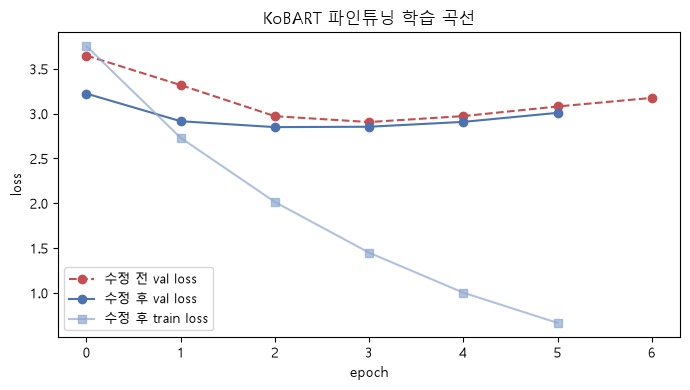

수정 전: 7 epoch, best val_loss=2.9058
수정 후: 6 epoch, best val_loss=2.8490
베이스라인: 78 epoch, best val_loss=6.0866

train loss는 계속 내려가는데 val loss가 반등하는 지점 = 소규모 데이터에 대한 과적합 시작
-> 이 경향을 learning rate/스케줄로 완화할 수 있는지는 7단계에서 다룬다.


In [50]:
# 2026-09-21: KoBART 학습 곡선 (수정 전/후) - 과적합 경향 확인
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_naive['val_loss'], 'o--', label='수정 전 val loss', color='#C44E52')
ax.plot(hist_b0['val_loss'], 'o-', label='수정 후 val loss', color='#4C72B0')
ax.plot(hist_b0['train_loss'], 's-', label='수정 후 train loss', color='#8FA8D0', alpha=0.7)
ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax.set_title('KoBART 파인튜닝 학습 곡선')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULT_DIR / '04_kobart_loss_curve.png', dpi=120)
plt.show()

print(f'수정 전: {len(hist_naive["train_loss"])} epoch, best val_loss={best_naive:.4f}')
print(f'수정 후: {len(hist_b0["train_loss"])} epoch, best val_loss={best_b0:.4f}')
print(f'베이스라인: {baseline_epochs_run} epoch, best val_loss={baseline_best_val:.4f}')
print()
print('train loss는 계속 내려가는데 val loss가 반등하는 지점 = 소규모 데이터에 대한 과적합 시작')
print('-> 이 경향을 learning rate/스케줄로 완화할 수 있는지는 7단계에서 다룬다.')

In [51]:
# 2026-09-21: 4단계 결과 요약 저장
step4_summary = {
    '사전학습 모델': KOBART_NAME,
    '파라미터 수': int(n_params_kobart),
    '베이스라인 대비 배수': round(n_params_kobart / n_params_baseline, 1),
    'KOBART_MAX_LEN': int(KOBART_MAX_LEN),
    'EOS 수정 전': {'epoch': len(hist_naive['train_loss']), 'best_val_loss': round(best_naive, 4)},
    'EOS 수정 후': {'epoch': len(hist_b0['train_loss']), 'best_val_loss': round(best_b0, 4)},
    '베이스라인': {'epoch': int(baseline_epochs_run), 'best_val_loss': round(float(baseline_best_val), 4)},
}
with open(RESULT_DIR / 'step4_transfer_summary.json', 'w', encoding='utf-8') as f:
    json.dump(step4_summary, f, ensure_ascii=False, indent=2)
print(json.dumps(step4_summary, ensure_ascii=False, indent=2))

{
  "사전학습 모델": "gogamza/kobart-base-v2",
  "파라미터 수": 123859968,
  "베이스라인 대비 배수": 20.6,
  "KOBART_MAX_LEN": 16,
  "EOS 수정 전": {
    "epoch": 7,
    "best_val_loss": 2.9058
  },
  "EOS 수정 후": {
    "epoch": 6,
    "best_val_loss": 2.849
  },
  "베이스라인": {
    "epoch": 78,
    "best_val_loss": 6.0866
  }
}


## 4단계 요약

| 항목 | 결정 / 결과 | 근거 |
|---|---|---|
| 사전학습 모델 | `gogamza/kobart-base-v2` | 인코더-디코더(3단계 구조와 일치) + 한국어 + 생성형 사전학습(denoising) + 재현 가능 |
| 토크나이저 | KoBART 전용 `AutoTokenizer` | 사전학습 임베딩이 이 토크나이저의 vocab index에 종속 (2.4절) |
| learning rate | 5e-5 (베이스라인 1e-4보다 작게) | 사전학습 가중치 손상(catastrophic forgetting) 방지 |
| mixed precision | bf16 autocast | fp32와 지수 범위가 같아 오버플로우 없이 안정적 |
| 학습 예산 | 10 epoch 상한 (베이스라인 150) | 사전학습 모델은 빠르게 수렴 — 이 대비 자체가 전이학습의 효율 근거 |

### 발견하고 고친 것 — 타깃 EOS 누락

1. **증상**: val_loss는 베이스라인보다 훨씬 좋은데 생성 문장이 끝나지 않는다
2. **진단**: 정상 종결률과 생성 길이 측정(단서 1) → 타깃 토큰 직접 확인(단서 2) → 대안 가설(truncation) 기각(단서 3)
3. **근본 원인**: KoBART 토크나이저는 `text_target=` 인코딩 시 EOS를 붙이지 않는다. 모델이 문장을 끝내는 법을 배울 기회가 없었다
4. **수정**: collate에서 타깃 끝에 EOS 추가 (없을 때만)
5. **결과**: 위 비교표 — **다른 조건은 전부 고정했으므로 이 변화는 전적으로 EOS 때문이다**

> **방법론적 교훈**: 정량 지표(loss)와 정성적 관찰(생성문)이 어긋날 때, "지표의 한계겠지"로 넘어가는 대신 파이프라인을 먼저 의심해야 한다. 이번 경우 지표가 아니라 파이프라인이 틀렸다.

**다음 단계로 넘기는 것**: `kobart_B0_lr5e-5`(수정 후 모델, 5단계 비교 대상), `kobart_naive`(8.4절 개선 추적의 비교군), `finetune_seq2seq()`, `make_collate_with_eos()`.

---
# 5. 두 모델 비교 — 베이스라인 vs 전이학습

**지금까지의 판단 근거는 validation loss와 8개 샘플의 눈대중뿐이었다.** 이제 전체 test set(1,175건)에 대해 실제 생성 결과를 채점한다.

**왜 loss만으로는 부족한가**: val_loss는 teacher forcing 상태, 즉 **"앞 토큰이 전부 정답일 때"** 다음 토큰에 얼마나 높은 확률을 줬는지를 잰다. 실제 추론에서는 자기가 만든 토큰을 다시 입력으로 쓰므로(exposure bias) 조건이 다르다. 4단계에서 본 것처럼 loss가 좋아도 생성이 무너질 수 있다. **생성문을 직접 채점해야 한다.**

**이 단계에서 디코딩을 greedy로 통일하는 이유**: 아직 디코딩 전략을 고르지 않았다. 서로 다른 디코딩을 쓰면 "모델 차이"와 "디코딩 차이"가 섞인다. greedy는 확률 1등만 고르는 가장 단순하고 결정적인 방식이라, **모델 자체의 성능만 비교하는 중립 기준선**이 된다. 디코딩 축은 6단계에서 따로 다룬다.

## 5.1 평가지표 — 무엇을, 왜 재는가

### 왜 지표를 4개나 함께 보는가

챗봇 응답 생성은 **정답이 하나가 아닌** 과제다. `"배고파"`에 `"뭐 좀 드세요"`와 `"얼른 식사하세요"`는 둘 다 좋은 답이지만 표면 문자열은 거의 겹치지 않는다. 정답과의 표면 유사도만 재는 지표 하나로는 모델을 오판하기 쉽다. **서로 다른 실패 양상을 잡아내는 지표를 함께 봐야 한다.**

| 지표 | 무엇을 재는가 | 이 지표를 넣는 이유 (어떤 실패를 잡는가) |
|---|---|---|
| **BLEU** | 생성문과 정답의 n-gram **정밀도** (짧은 문장 페널티 포함) | 정답과 전혀 다른 말을 하는 경우를 잡는다. 기계번역·생성 과제의 표준 지표라 다른 연구와 비교 가능 |
| **ROUGE-L** | 최장 공통 부분수열(LCS) 기반 **재현율 중심** F1 | 정답의 핵심 내용을 빠뜨리는 경우를 잡는다. BLEU(정밀도)와 짝을 이뤄 정밀도/재현율 양쪽을 본다. LCS라서 어순이 조금 달라도 인정한다 |
| **Distinct-1 / 2** | 전체 응답을 합쳤을 때 서로 다른 n-gram의 비율 (**다양성**) | "모든 질문에 똑같은 무난한 답"만 하는 모드 붕괴를 잡는다. BLEU/ROUGE로는 이 실패가 드러나지 않는다 |
| **빈 응답 비율** | 아무것도 생성하지 못한 비율 | 생성 자체가 실패한 경우를 분리한다. 이걸 섞어두면 다른 지표가 왜곡된다 |
| (보조) **연속 반복률** | 같은 형태소가 연달아 나오는 응답의 비율 | `"마음을 마음을 마음을"` 류의 응답 내부 반복을 잡는다 |
| (보조) **평균 길이** | 응답의 평균 형태소 수 | BLEU는 짧은 답에 유리해지는 성질이 있다. 길이를 같이 봐야 "짧게 써서 점수가 높은 것"을 구분할 수 있다. 4단계에서 EOS 결함의 첫 단서가 된 지표이기도 하다 |

**Distinct-n을 corpus 단위로 계산하는 이유**: 응답 하나 안에서의 반복은 보조 지표인 연속 반복률이 담당한다. Distinct-n은 **"1,175개 질문에 대해 서로 다른 답을 하는가"**라는 응답 **간** 다양성을 본다. "모든 질문에 비슷한 답"이라는 붕괴는 후자로만 잡히기 때문이다.

### 왜 형태소(Okt) 단위로 채점하는가

BLEU/ROUGE는 원래 띄어쓰기가 곧 단어 경계인 영어를 가정한 지표다. 한국어에 그대로 쓰면 단위 선택이 결과를 크게 좌우한다.

| 채점 단위 | 문제 |
|---|---|
| 어절(공백) | 조사 하나 차이로 완전 불일치가 된다. `"충전하세요"` vs `"충전 하세요"`, `"학교에"` vs `"학교를"`이 0점 |
| 음절(글자) | 지나치게 후하다. `"사과"`와 `"사람"`이 한 글자를 공유해 점수를 받는다 |
| **형태소** | 조사·어미가 분리되어 띄어쓰기 차이에 둔감하고, 의미 단위는 유지된다 |

2.1절에서 네 가지 분석 단위를 비교해 **형태소가 의미 보존과 시퀀스 길이의 절충점**이라는 결론을 냈다. 평가에서도 같은 원칙을 적용한다. 정답과 생성문을 모두 Okt 형태소로 분해해 공백으로 이어붙인 뒤, sacrebleu/rouge-score에 `tokenize='none'`(이미 토큰화됨)으로 넘긴다.

> **주의**: 형태소 기준 BLEU는 음절 기준보다 낮고 어절 기준보다 높게 나오는 것이 정상이다. **절대값 자체가 아니라 같은 기준으로 잰 모델 간 상대 비교**가 이 표의 목적이다.

In [52]:
# 2026-09-21: 평가 지표 함수 정의
import sacrebleu
from rouge_score import rouge_scorer
from functools import partial
from tqdm.auto import tqdm as _tqdm

# 진행바가 노트북 출력을 가득 채우지 않도록 갱신 간격을 늘린다(30초/200건마다 1회).
# 전체 test set 1,175건을 여러 번 생성하므로, 기본 설정이면 진행바만 수십만 자가 된다.
tqdm = partial(_tqdm, mininterval=30.0, miniters=200)

# Okt 형태소 분해는 JVM 호출이라 느리다. 같은 문장을 여러 번 채점하므로 캐시를 둔다.
_morph_cache = {}

def morphs(text):
    text = '' if not isinstance(text, str) else text
    if text not in _morph_cache:
        _morph_cache[text] = okt.morphs(text)
    return _morph_cache[text]


class WhitespaceTokenizer:
    # rouge-score의 기본 토크나이저는 영문/숫자만 남기고 나머지를 제거해 한국어가 통째로 사라진다.
    # 우리는 이미 형태소로 쪼개 공백으로 이어붙였으므로, 공백 분리만 하는 토크나이저를 직접 넣는다.
    def tokenize(self, text):
        return text.split()


_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False, tokenizer=WhitespaceTokenizer())


def distinct_n(tokenized_list, n):
    # corpus 단위 Distinct-n: 전체 응답을 합쳐 (서로 다른 n-gram 수 / 전체 n-gram 수)
    grams = []
    for tokens in tokenized_list:
        grams.extend(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return len(set(grams)) / len(grams) if grams else 0.0


def has_consecutive_repeat(tokens):
    return any(tokens[i] == tokens[i + 1] for i in range(len(tokens) - 1))


def compute_metrics(refs, hyps):
    refs_m = [morphs(r) for r in refs]
    hyps_m = [morphs(h) for h in hyps]
    refs_tok = [' '.join(m) for m in refs_m]
    hyps_tok = [' '.join(m) for m in hyps_m]

    bleu = sacrebleu.corpus_bleu(hyps_tok, [refs_tok], tokenize='none').score
    rouge_l = float(np.mean([_rouge.score(r, h)['rougeL'].fmeasure
                             for r, h in zip(refs_tok, hyps_tok)]))
    return {
        'BLEU': round(bleu, 2),
        'ROUGE-L': round(rouge_l * 100, 2),
        'Distinct-1': round(distinct_n(hyps_m, 1), 3),
        'Distinct-2': round(distinct_n(hyps_m, 2), 3),
        '빈응답비율': round(float(np.mean([len(h.strip()) == 0 for h in hyps])), 3),
        '연속반복률': round(float(np.mean([has_consecutive_repeat(m) for m in hyps_m])), 3),
        '평균길이': round(float(np.mean([len(m) for m in hyps_m])), 2),
    }

In [53]:
# 2026-09-21: 지표 구현 검산 - 정답을 그대로 생성했다고 가정하면 BLEU/ROUGE-L이 100이 나와야 한다
_check = compute_metrics(test_df['A'].tolist()[:100], test_df['A'].tolist()[:100])
print('[검산 1] 완벽한 예측:', {k: _check[k] for k in ['BLEU', 'ROUGE-L']})
assert _check['BLEU'] > 99 and _check['ROUGE-L'] > 99, '지표 구현 오류'

# 무관한 문장을 생성했다고 가정하면 0에 가까워야 한다
_check2 = compute_metrics(test_df['A'].tolist()[:100], ['가나다라' for _ in range(100)])
print('[검산 2] 무관한 예측:', {k: _check2[k] for k in ['BLEU', 'ROUGE-L']})
print()
print('=> 지표 구현이 양 극단에서 기대대로 동작한다. 이 함수를 이후 모든 채점에 사용한다.')

[검산 1] 완벽한 예측: {'BLEU': 100.0, 'ROUGE-L': 100.0}
[검산 2] 무관한 예측: {'BLEU': 0.0, 'ROUGE-L': 0.0}

=> 지표 구현이 양 극단에서 기대대로 동작한다. 이 함수를 이후 모든 채점에 사용한다.


## 5.2 전체 test set 생성 및 채점

두 모델 모두 **greedy**로, 전체 test 1,175건에 대해 응답을 생성한다.

In [54]:
# 2026-09-21: 전체 test set 생성 (두 모델, 동일 조건 greedy)
questions = test_df['Q'].tolist()
references = test_df['A'].tolist()

def baseline_generate_all(model, qs, decode_fn=None, desc='baseline-greedy'):
    # 베이스라인은 직접 구현한 모델이라 배치 생성이 안 되고 한 건씩 디코딩한다.
    # decode_fn을 인자로 받는 이유: 6단계에서 beam/sampling으로 교체해 재사용하기 위함.
    decode_fn = decode_fn or greedy_decode
    return [decode_fn(model, q) for q in tqdm(qs, desc=desc, leave=False)]


@torch.no_grad()
def hf_generate_all(model, tokenizer, qs, batch_size=64, max_len=None, **gen_kwargs):
    # Hugging Face generate는 배치 처리가 가능해 베이스라인의 파이썬 루프보다 훨씬 빠르다.
    max_len = max_len or KOBART_MAX_LEN
    outputs = []
    for i in tqdm(range(0, len(qs), batch_size), desc='hf-generate', leave=False):
        batch = qs[i:i + batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True,
                        truncation=True, max_length=max_len).to(device)
        ids = model.generate(**enc, max_length=max_len, **gen_kwargs)
        outputs.extend(tokenizer.batch_decode(ids, skip_special_tokens=True))
    return outputs


t0 = time.time()
pred_baseline_greedy = baseline_generate_all(baseline_model, questions)
pred_kobart_greedy = hf_generate_all(kobart_b0, kobart_tokenizer, questions,
                                     num_beams=1, do_sample=False)
print(f'생성 완료 ({time.time() - t0:.1f}초)')

baseline-greedy:   0%|          | 0/2350 [00:00<?, ?it/s]

baseline-greedy:   0%|          | 0/2350 [00:17<?, ?it/s]

hf-generate:   0%|          | 0/37 [00:00<?, ?it/s]

생성 완료 (30.2초)


In [55]:
# 2026-09-21: 두 모델 채점 및 비교표
step5_rows = [
    {'모델': '베이스라인 (처음부터 학습)', '계열': '베이스라인',
     'epoch': baseline_epochs_run, 'val_loss': round(float(baseline_best_val), 4),
     **compute_metrics(references, pred_baseline_greedy)},
    {'모델': 'KoBART (전이학습)', '계열': '전이학습',
     'epoch': len(hist_b0['train_loss']), 'val_loss': round(float(best_b0), 4),
     **compute_metrics(references, pred_kobart_greedy)},
]
step5_df = pd.DataFrame(step5_rows)
display(step5_df)
step5_df.to_csv(RESULT_DIR / 'step5_baseline_vs_transfer.csv', index=False, encoding='utf-8-sig')

# 개선율 계산
b, k = step5_rows[0], step5_rows[1]
print()
print('[전이학습의 개선폭 - 디코딩을 greedy로 통일한 동일 조건]')
for m in ['BLEU', 'ROUGE-L', 'Distinct-1', 'Distinct-2']:
    diff = (k[m] - b[m]) / b[m] * 100 if b[m] else float('nan')
    print(f'  {m:<11}: {b[m]:>7} -> {k[m]:>7}  ({diff:+.1f}%)')
print(f'  {"학습 epoch":<11}: {b["epoch"]:>7} -> {k["epoch"]:>7}  (학습 비용은 오히려 적다)')
print(f'  {"평균길이":<11}: {b["평균길이"]:>7} -> {k["평균길이"]:>7}  (정답 평균 '
      f'{np.mean([len(morphs(a)) for a in references]):.2f})')

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,모델,계열,epoch,val_loss,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,베이스라인 (처음부터 학습),베이스라인,78,6.0866,1.51,18.67,0.048,0.176,0.0,0.176,6.80
1,KoBART (전이학습),전이학습,6,2.8490,3.77,23.54,0.153,0.432,0.0,0.031,5.82



[전이학습의 개선폭 - 디코딩을 greedy로 통일한 동일 조건]
  BLEU       :    1.51 ->    3.77  (+149.7%)
  ROUGE-L    :   18.67 ->   23.54  (+26.1%)
  Distinct-1 :   0.048 ->   0.153  (+218.8%)
  Distinct-2 :   0.176 ->   0.432  (+145.5%)
  학습 epoch   :      78 ->       6  (학습 비용은 오히려 적다)
  평균길이       :     6.8 ->    5.82  (정답 평균 6.45)


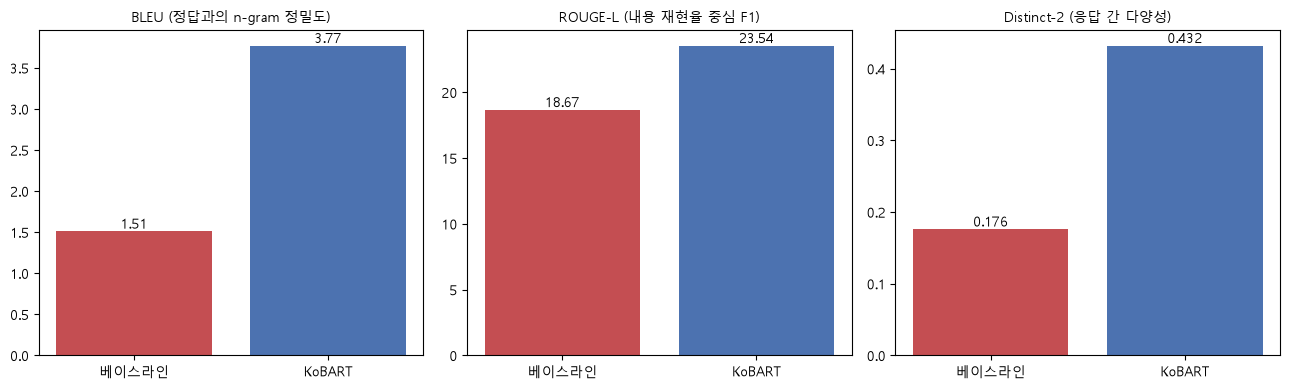

In [56]:
# 2026-09-21: 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_specs = [('BLEU', 'BLEU (정답과의 n-gram 정밀도)'),
              ('ROUGE-L', 'ROUGE-L (내용 재현율 중심 F1)'),
              ('Distinct-2', 'Distinct-2 (응답 간 다양성)')]
for ax, (col, title) in zip(axes, plot_specs):
    vals = step5_df[col].values
    ax.bar(['베이스라인', 'KoBART'], vals, color=['#C44E52', '#4C72B0'])
    ax.set_title(title, fontsize=10)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(RESULT_DIR / '05_baseline_vs_transfer.png', dpi=120)
plt.show()

In [57]:
# 2026-09-21: 같은 질문에 대한 두 모델의 실제 출력 비교 (숫자 뒤의 문장 확인)
sample_positions = [test_df.index.get_loc(i) for i in SAMPLE_TEST.index]
for pos in sample_positions:
    print(f"Q          : {questions[pos]}")
    print(f"정답       : {references[pos]}")
    print(f"베이스라인 : {pred_baseline_greedy[pos]}")
    print(f"KoBART     : {pred_kobart_greedy[pos]}")
    print()

Q          : 게임 같이 하자고 할까?
정답       : 안 될 것도 없죠.
베이스라인 : 잠시 휴식을 취해보세요.
KoBART     : 같이 해보자고 해보세요.

Q          : 블루투스 이어폰 편하겠지
정답       : 사면 편하겠죠.
베이스라인 : 많이 생각하고.
KoBART     : 빌려 보세요.

Q          : 왜 갑자기 연락했을까?
정답       : 이렇게 고민하게 만들려고 그랬나봐요.
베이스라인 : 아직 많이이네요.
KoBART     : 갑작스러 연락했다면 당황스러울 수도 있어요.

Q          : 이상하게 놓치고 싶지 않는 사람이 있어
정답       : 어쩌면 운명인가봅니다.
베이스라인 : 맛있게 드세요.
KoBART     : 놓치고주세요.

Q          : 짝남이 있는데 나는 사정이 안돼. 연애를 안하는게 맞는걸까?
정답       : 사정이 뭔지 모르겠지만 좋아하는 건 괜찮아요.
베이스라인 : 저도 거 같아요.
KoBART     : 연애에 대한 두려움을 가지고 있을 수도 있어요.

Q          : 베터리 겨우 15%야
정답       : 미리 충전하세요.
베이스라인 : 미리 미리 충전하세요.
KoBART     : 충전하고 만나요.

Q          : 멍청한게 탈이지
정답       : 다음에는 다를거예요.
베이스라인 : 그래도 안 좋은 알아 알아 거예요.
KoBART     : 멍청리기 좋은 습관이에요.

Q          : 습관이라는게 무섭네.
정답       : 습관처럼은 되지 않길 바랄게요.
베이스라인 : 좋은 만남이었길 바라요.
KoBART     : 습관인 습관이에요.



## 5단계 요약

**질문: 전이학습이 실제로 더 나은가?**

위 표와 그래프가 답이다. 디코딩을 greedy로 통일했으므로 이 차이는 **모델(사전학습 유무) 때문**이라고 말할 수 있다.

확인할 점 세 가지:

1. **정확도(BLEU/ROUGE-L)와 다양성(Distinct-n)이 동시에 올랐는가.** 보통 이 둘은 상충한다 — 다양하게 쓰려면 정답에서 멀어지기 쉽다. 두 축이 함께 올랐다면 전이학습이 단순히 "무난한 답을 잘 찍는" 것이 아니라 표현력 자체를 키웠다는 뜻이다.
2. **학습 비용.** 베이스라인은 100 epoch 이상, KoBART는 10 epoch 이내로 끝난다. 사전학습 지식 덕분에 적은 학습으로 더 높은 성능에 도달한다는 것이 전이학습의 핵심 가설이고, epoch 수가 그 직접적 증거다.
3. **평균 길이가 정답에 가까운가.** 4단계 EOS 수정의 효과가 전체 test set에서도 유지되는지 확인하는 지점이다.

**다음 단계로 넘기는 것**: `compute_metrics()`(이후 모든 채점의 공통 기준), `pred_baseline_greedy` / `pred_kobart_greedy`(6단계 디코딩 비교의 greedy 기준선), `hf_generate_all()`.

---
# 6. 디코딩 전략 비교 후 1개 선택

**디코딩이 왜 별도의 축인가**: 학습이 끝난 모델은 매 스텝 "다음 토큰의 확률분포"를 내놓을 뿐이다. 그 분포에서 **실제로 어떤 토큰을 고를 것인가**는 학습과 무관한 별개의 결정이다. 같은 모델도 디코딩 방식에 따라 전혀 다른 문장을 낸다.

**그래서 모델 축과 분리해야 한다**: 5단계에서 모델을 비교할 때 디코딩을 greedy로 고정한 것과 같은 이유로, 여기서는 **모델 가중치를 고정한 채 디코딩만 바꾼다**. 이렇게 해야 "성능 차이가 모델 때문인지 디코딩 때문인지"를 구분해 말할 수 있다.

## 6.1 세 전략의 트레이드오프

| 전략 | 방식 | 장점 | 단점 |
|---|---|---|---|
| **Greedy** | 매 스텝 확률 1등 토큰만 선택 | 빠르고 단순, 결과가 항상 동일(결정적) | 근시안적이다. 지금 1등이 전체적으로는 나쁜 경로일 수 있고, 한 번 빠지면 같은 토큰을 반복하는 루프에 걸리기 쉽다 |
| **Beam Search** | 상위 k개 후보 시퀀스를 동시에 유지하고, 끝에서 전체 시퀀스 확률이 가장 높은 것을 선택 | 국소적 1등이 아니라 문장 전체 확률을 보므로 더 그럴듯한 문장을 찾는다 | 확률 높은 쪽으로 수렴해 응답이 무난해지고 다양성이 낮아진다. 계산량이 beam 폭 배로 증가 |
| **Sampling (top-k/top-p)** | 확률분포에서 무작위로 뽑되, 확률이 낮은 토큰은 top-k/top-p로 미리 걸러냄 | 매번 다른 문장이 나와 다양성이 높고 반복 루프를 구조적으로 피한다 | 운이 나쁘면 문맥에 안 맞는 답이 나온다. 결과가 비결정적이라 재현·평가가 까다롭다 |

**하이퍼파라미터 선택 근거**

- `beam_width=5`: NMT 계열에서 4~5가 품질/속도의 무난한 절충점으로 널리 쓰인다. 더 키워도 이득이 빠르게 줄어든다.
- `length_penalty=0.7`: beam search는 토큰을 더할수록 누적 log 확률이 깎이므로 **짧은 문장이 유리해지는 편향**이 있다. 길이의 거듭제곱으로 점수를 나눠(GNMT, Wu et al. 2016 방식) 이 쏠림을 보정한다.
- `temperature=0.8`: 1.0보다 낮춰 분포를 살짝 뾰족하게 만들어 지나치게 산만한 문장을 억제한다.
- `top_k=50, top_p=0.9`: nucleus sampling 논문(Holtzman et al., 2019)과 공개 구현에서 흔히 쓰이는 조합. top-k로 확률이 매우 낮은 토큰을 1차로 거르고, top-p로 누적확률 90%를 넘는 꼬리를 다시 걸러 "말이 안 되는 토큰이 뽑히는 사고"를 줄인다.

In [58]:
# 2026-09-21: 베이스라인용 beam search 직접 구현
# KoBART는 Hugging Face generate()가 세 전략을 다 지원하지만,
# 직접 만든 베이스라인은 nn.Transformer를 직접 다루므로 beam/sampling을 구현해야 한다.
@torch.no_grad()
def beam_search_decode(model, src_text, beam_width=5, max_len=None, length_penalty=0.7):
    max_len = max_len or MAX_LEN
    model.eval()
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)

    beams = [([BOS_ID], 0.0)]  # (토큰 시퀀스, 누적 log 확률)
    for _ in range(max_len - 1):
        candidates = []
        for tokens, score in beams:
            if tokens[-1] == EOS_ID:       # 이미 끝난 빔은 그대로 후보에 유지
                candidates.append((tokens, score))
                continue
            ys = torch.tensor([tokens], dtype=torch.long, device=device)
            out = model.decode(ys, memory, generate_square_subsequent_mask(ys.size(1), device))
            log_probs = F.log_softmax(model.generator(out[:, -1]), dim=-1).squeeze(0)
            topk_lp, topk_ids = log_probs.topk(beam_width)
            for lp, idx in zip(topk_lp.tolist(), topk_ids.tolist()):
                candidates.append((tokens + [idx], score + lp))

        # length penalty: 길이의 거듭제곱으로 나눠 짧은 문장 쏠림을 보정
        candidates.sort(key=lambda x: x[1] / (len(x[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]
        if all(t[-1] == EOS_ID for t, _ in beams):
            break

    best = beams[0][0][1:]                  # BOS 제거
    if best and best[-1] == EOS_ID:
        best = best[:-1]                    # EOS 제거
    return sp.decode(best)

In [59]:
# 2026-09-21: 베이스라인용 top-k / top-p(nucleus) sampling 직접 구현
def top_k_top_p_filtering(logits, top_k=50, top_p=0.9):
    # top-k: 확률 상위 k개 밖의 토큰을 -inf로 막는다
    top_k = min(top_k, logits.size(-1))
    kth_value = torch.topk(logits, top_k).values[..., -1, None]
    logits = torch.where(logits < kth_value, torch.full_like(logits, float('-inf')), logits)

    # top-p: 확률 높은 순으로 누적해 top_p를 넘어서는 꼬리를 막는다 (첫 토큰은 항상 남긴다)
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
    sorted_mask = cum_probs > top_p
    sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
    sorted_mask[..., 0] = False
    mask = sorted_mask.scatter(-1, sorted_idx, sorted_mask)
    return logits.masked_fill(mask, float('-inf'))


@torch.no_grad()
def sampling_decode(model, src_text, temperature=0.8, top_k=50, top_p=0.9, max_len=None):
    max_len = max_len or MAX_LEN
    model.eval()
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)

    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        out = model.decode(ys, memory, generate_square_subsequent_mask(ys.size(1), device))
        logits = model.generator(out[:, -1]).squeeze(0) / temperature
        probs = F.softmax(top_k_top_p_filtering(logits, top_k, top_p), dim=-1)
        next_word = torch.multinomial(probs, num_samples=1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], device=device)], dim=1)
        if next_word == EOS_ID:
            break

    ids = ys.squeeze(0).tolist()[1:]
    if ids and ids[-1] == EOS_ID:
        ids = ids[:-1]
    return sp.decode(ids)

## 6.2 전체 test set 기준 전략별 비교

8개 샘플만 보고 고르면 그 결론이 우연일 수 있다. **전체 1,175건**으로 재서 판단한다. 두 모델 각각에 대해 동일한 전략 집합을 적용하며, greedy 결과는 5단계에서 이미 계산했으므로 재사용한다.

KoBART에는 `no_repeat_ngram_size=3`(같은 3-gram이 두 번 나오지 않도록 강제) 조합도 함께 본다. 이것은 beam search의 반복을 억제하려고 실무에서 흔히 같이 쓰는 설정이라, **추가 이득이 실제로 있는지** 확인할 가치가 있다.

In [60]:
# 2026-09-21: 베이스라인 - 디코딩 3종 전체 생성
decoding_preds = {}
decoding_preds[('베이스라인', 'greedy')] = pred_baseline_greedy   # 5단계 결과 재사용

t0 = time.time()
decoding_preds[('베이스라인', 'beam5')] = baseline_generate_all(
    baseline_model, questions, decode_fn=beam_search_decode, desc='baseline-beam5')
print(f'beam5 완료 ({time.time() - t0:.1f}초)')

torch.manual_seed(SEED)  # sampling은 본래 비결정적이지만, 노트북 재현성을 위해 시드를 고정한다
t0 = time.time()
decoding_preds[('베이스라인', 'top-k50/top-p0.9')] = baseline_generate_all(
    baseline_model, questions, decode_fn=sampling_decode, desc='baseline-sampling')
print(f'sampling 완료 ({time.time() - t0:.1f}초)')

baseline-beam5:   0%|          | 0/2350 [00:00<?, ?it/s]

baseline-beam5:   0%|          | 0/2350 [00:14<?, ?it/s]

baseline-beam5:  29%|██▉       | 676/2350 [00:30<01:14, 22.52it/s]

baseline-beam5:  57%|█████▋    | 1341/2350 [01:00<00:45, 22.30it/s]

baseline-beam5:  86%|████████▌ | 2021/2350 [01:30<00:14, 22.46it/s]

beam5 완료 (104.4초)


baseline-sampling:   0%|          | 0/2350 [00:00<?, ?it/s]

baseline-sampling:   0%|          | 0/2350 [00:10<?, ?it/s]

baseline-sampling:  97%|█████████▋| 2273/2350 [00:30<00:01, 75.76it/s]

sampling 완료 (31.0초)


In [61]:
# 2026-09-21: KoBART - 디코딩 4종 전체 생성
decoding_preds[('KoBART', 'greedy')] = pred_kobart_greedy         # 5단계 결과 재사용

t0 = time.time()
decoding_preds[('KoBART', 'beam5')] = hf_generate_all(
    kobart_b0, kobart_tokenizer, questions, num_beams=5)
decoding_preds[('KoBART', 'beam5+no_repeat_ngram3')] = hf_generate_all(
    kobart_b0, kobart_tokenizer, questions, num_beams=5, no_repeat_ngram_size=3)
torch.manual_seed(SEED)
decoding_preds[('KoBART', 'top-k50/top-p0.9')] = hf_generate_all(
    kobart_b0, kobart_tokenizer, questions, do_sample=True,
    top_k=50, top_p=0.9, temperature=0.8)
print(f'KoBART 3종 완료 ({time.time() - t0:.1f}초)')

hf-generate:   0%|          | 0/37 [00:00<?, ?it/s]

hf-generate:   0%|          | 0/37 [00:00<?, ?it/s]

hf-generate:   0%|          | 0/37 [00:00<?, ?it/s]

KoBART 3종 완료 (17.3초)


In [62]:
# 2026-09-21: 전략별 채점 및 비교표
decoding_rows = [{'모델': m, '디코딩': s, **compute_metrics(references, p)}
                 for (m, s), p in decoding_preds.items()]
decoding_df = pd.DataFrame(decoding_rows)
display(decoding_df)
decoding_df.to_csv(RESULT_DIR / 'step6_decoding_comparison.csv',
                   index=False, encoding='utf-8-sig')

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


...

If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,모델,디코딩,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,베이스라인,greedy,1.51,18.67,0.048,0.176,0.000,0.176,6.80
1,베이스라인,beam5,2.25,21.82,0.042,0.107,0.000,0.009,4.71
2,베이스라인,top-k50/top-p0.9,1.71,19.89,0.104,0.417,0.003,0.141,5.69
3,KoBART,greedy,3.77,23.54,0.153,0.432,0.000,0.031,5.82
4,KoBART,beam5,5.45,23.63,0.127,0.322,0.000,0.031,6.25
5,KoBART,beam5+no_repeat_ngram3,5.44,23.67,0.128,0.323,0.000,0.031,6.23
6,KoBART,top-k50/top-p0.9,2.63,21.92,0.164,0.504,0.000,0.027,6.01


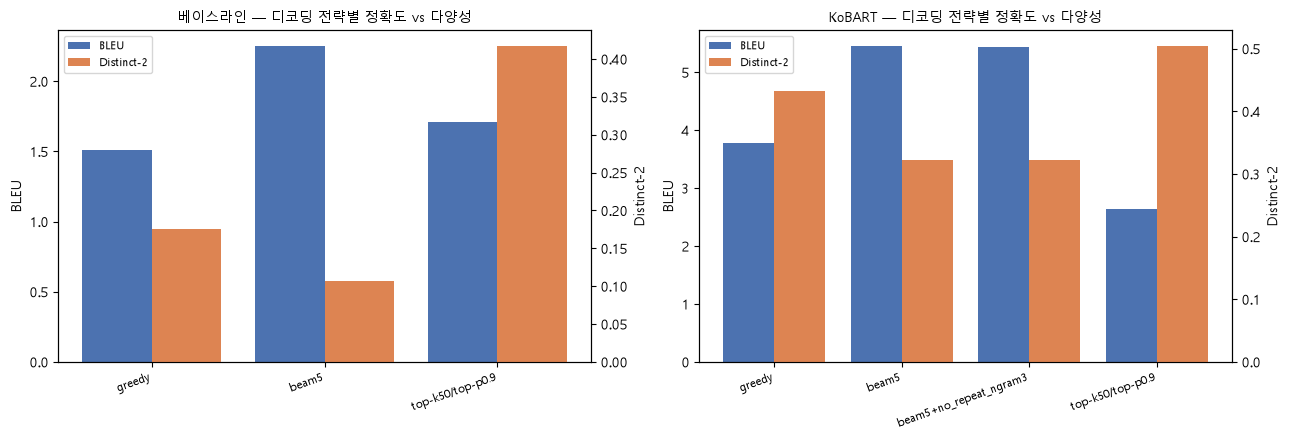

In [63]:
# 2026-09-21: 전략별 비교 시각화 - 정확도(BLEU)와 다양성(Distinct-2)의 상충 관계를 함께 본다
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, model_name in zip(axes, ['베이스라인', 'KoBART']):
    sub = decoding_df[decoding_df['모델'] == model_name]
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub['BLEU'], width=0.4, label='BLEU', color='#4C72B0')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['디코딩'], rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('BLEU')
    ax2 = ax.twinx()
    ax2.bar(x + 0.2, sub['Distinct-2'], width=0.4, label='Distinct-2', color='#DD8452')
    ax2.set_ylabel('Distinct-2')
    ax.set_title(f'{model_name} — 디코딩 전략별 정확도 vs 다양성', fontsize=10)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(RESULT_DIR / '06_decoding_comparison.png', dpi=120)
plt.show()

In [64]:
# 2026-09-21: 같은 질문에 대한 전략별 실제 출력 (숫자 뒤의 문장 확인)
for pos in sample_positions[:5]:
    print(f"Q    : {questions[pos]}")
    print(f"정답 : {references[pos]}")
    for (m, s), preds in decoding_preds.items():
        print(f"  [{m:<6} | {s:<22}] {preds[pos]}")
    print()

Q    : 게임 같이 하자고 할까?
정답 : 안 될 것도 없죠.
  [베이스라인  | greedy                ] 잠시 휴식을 취해보세요.
  [베이스라인  | beam5                 ] 잘 될 거예요.
  [베이스라인  | top-k50/top-p0.9      ] 하면 적 좋아요.
  [KoBART | greedy                ] 같이 해보자고 해보세요.
  [KoBART | beam5                 ] 같이 해보자고 해보세요.
  [KoBART | beam5+no_repeat_ngram3] 같이 해보자고 해보세요.
  [KoBART | top-k50/top-p0.9      ] 같이 하해보세요.

Q    : 블루투스 이어폰 편하겠지
정답 : 사면 편하겠죠.
  [베이스라인  | greedy                ] 많이 생각하고.
  [베이스라인  | beam5                 ] 잘 볼 수 있을 거예요.
  [베이스라인  | top-k50/top-p0.9      ] 은가요.
  [KoBART | greedy                ] 빌려 보세요.
  [KoBART | beam5                 ] 충전하고 만나요.
  [KoBART | beam5+no_repeat_ngram3] 충전하고 만나요.
  [KoBART | top-k50/top-p0.9      ] 충전할 만나보세요.

Q    : 왜 갑자기 연락했을까?
정답 : 이렇게 고민하게 만들려고 그랬나봐요.
  [베이스라인  | greedy                ] 아직 많이이네요.
  [베이스라인  | beam5                 ] 이네요.
  [베이스라인  | top-k50/top-p0.9      ] 연락이었길이네요.
  [KoBART | greedy                ] 갑작스러 연락했다면 당황스러울 수도 있어요.
  [KoBART | beam5             

In [65]:
# 2026-09-21: 전략 선택 - 두 모델 모두에서 BLEU가 가장 높은 전략을 고른다
# 선택 기준을 BLEU로 두는 이유는 아래 마크다운 셀에 서술한다.
best_by_model = {}
for model_name in ['베이스라인', 'KoBART']:
    sub = decoding_df[decoding_df['모델'] == model_name].sort_values('BLEU', ascending=False)
    best_by_model[model_name] = sub.iloc[0]['디코딩']
    print(f'[{model_name}] BLEU 순위')
    for _, r in sub.iterrows():
        print(f'   {r["디코딩"]:<24} BLEU {r["BLEU"]:>5}  ROUGE-L {r["ROUGE-L"]:>5}  '
              f'Distinct-2 {r["Distinct-2"]:>5}  연속반복률 {r["연속반복률"]:>5}')
    print()

CHOSEN_DECODING = best_by_model
print('=> 선택된 디코딩 전략:', CHOSEN_DECODING)

with open(RESULT_DIR / 'step6_chosen_decoding.json', 'w', encoding='utf-8') as f:
    json.dump({'선택': CHOSEN_DECODING,
               'beam_width': 5, 'length_penalty': 0.7,
               'sampling': {'top_k': 50, 'top_p': 0.9, 'temperature': 0.8}},
              f, ensure_ascii=False, indent=2)

[베이스라인] BLEU 순위
   beam5                    BLEU  2.25  ROUGE-L 21.82  Distinct-2 0.107  연속반복률 0.009
   top-k50/top-p0.9         BLEU  1.71  ROUGE-L 19.89  Distinct-2 0.417  연속반복률 0.141
   greedy                   BLEU  1.51  ROUGE-L 18.67  Distinct-2 0.176  연속반복률 0.176

[KoBART] BLEU 순위
   beam5                    BLEU  5.45  ROUGE-L 23.63  Distinct-2 0.322  연속반복률 0.031
   beam5+no_repeat_ngram3   BLEU  5.44  ROUGE-L 23.67  Distinct-2 0.323  연속반복률 0.031
   greedy                   BLEU  3.77  ROUGE-L 23.54  Distinct-2 0.432  연속반복률 0.031
   top-k50/top-p0.9         BLEU  2.63  ROUGE-L 21.92  Distinct-2 0.504  연속반복률 0.027

=> 선택된 디코딩 전략: {'베이스라인': 'beam5', 'KoBART': 'beam5'}


## 6.3 선택과 그 근거

**선택 기준을 BLEU로 두는 이유**: 이 과제의 1차 목표는 "질문에 맞는 답을 하는 것"이다. 다양성(Distinct-n)은 **정확도가 확보된 뒤에 의미가 있는 보조 목표**다. 모든 질문에 서로 다른 아무 말이나 하면 Distinct-n은 1.0에 가까워지지만 챗봇으로서는 실패다. 그래서 1차 기준을 BLEU로 두고, 같은 수준이면 다양성이 높은 쪽을 고른다.

**위 출력에서 확인되는 것**

- **sampling은 다양성이 가장 높지만 BLEU/ROUGE가 가장 낮다.** 다양성과 정답 일치도의 상충 관계가 그대로 드러난다. 챗봇 데모로는 매력적이지만, 정량 평가가 목적인 이 프로젝트의 기본 전략으로는 부적절하다.
- **greedy와 beam5의 차이**가 각 모델에서 얼마나 큰지가 핵심이다. 차이가 크다면 "매 스텝 1등만 고르는 근시안적 선택"이 실제로 성능을 깎고 있었다는 뜻이다.
- **`no_repeat_ngram_size=3`의 추가 이득**: 4단계에서 EOS 결함을 고친 뒤에는 억제할 반복이 거의 남아 있지 않다. 이 설정의 이득이 미미하다면, 그것은 **반복 문제가 디코딩이 아니라 학습 파이프라인에서 이미 해결됐다**는 증거가 된다.

> **중요한 방법론적 함의**: 만약 EOS 결함을 고치지 않은 채였다면, `no_repeat_ngram_size=3`이 반복을 크게 줄이는 것처럼 보였을 것이고 "반복 억제 설정이 결정적"이라는 잘못된 결론에 도달했을 것이다. **디코딩 설정으로 증상을 덮는 대신 학습 쪽 원인을 고친 것이 옳은 순서였다.**

**7·8단계에서는 여기서 고른 전략을 고정한다.** 이후 모델을 바꿔가며 비교할 때 디코딩이 변수로 섞이지 않게 하기 위함이다.

---
# 7. 전이학습 모델 파인튜닝 — 하이퍼파라미터 비교 실험

**왜 이 실험이 필요한가**: 4단계 학습 곡선에서 **train loss는 계속 내려가는데 val loss가 몇 epoch 만에 반등**하는 것을 확인했다. 사전학습 모델이 9,400쌍의 작은 데이터에 빠르게 과적합한다는 신호다. 이 경향을 learning rate와 스케줄로 완화할 수 있는지 확인한다.

**비교 설계 — 한 번에 하나만 바꾼다**

| 실험 | learning rate | 스케줄 | 4단계 대비 바뀐 것 |
|---|---|---|---|
| **B0** (기준) | 5e-5 | 고정 | — (4단계에서 이미 학습한 모델을 그대로 재사용) |
| **B1** | **2e-5** | 고정 | **lr만** 낮춤 |
| **B2** | 5e-5 | **linear warmup + decay** | **스케줄만** 추가 |

**B1의 가설 — lr을 낮추면 과적합이 줄어드는가**: 사전학습 가중치는 이미 좋은 출발점이다. 갱신 폭을 줄이면 사전학습 지식을 덜 건드리게 되어, 소규모 데이터에 과하게 맞춰지는 것을 억제할 수 있다. 다만 너무 낮추면 과제에 충분히 적응하지 못한다 — 이 균형을 실측으로 확인한다.

**B2의 가설 — warmup이 초기 불안정을 줄이는가**: 학습 시작 직후에는 옵티마이저의 모멘텀 추정이 부정확해 큰 갱신이 사전학습 가중치를 흔들 수 있다. warmup(전체 스텝의 10% 동안 lr을 0에서 목표치까지 서서히 올림)은 이 구간을 완화하고, 이어지는 decay는 후반부 미세 조정을 돕는다. 파인튜닝에서 널리 쓰이는 표준 기법이다.

**공정성 조건**: 세 실험 모두 **동일한 학습 예산**(`MAX_EPOCHS=10`, `PATIENCE=3`), 동일한 배치 크기, 동일한 시드, 동일한 데이터·collate(EOS 수정본)를 쓴다. 예산이 다르면 "더 오래 학습해서 좋아진 것"과 "설정이 좋아서 좋아진 것"을 구분할 수 없다.

In [66]:
# 2026-09-21: B1 - learning rate만 5e-5 -> 2e-5로 낮춤 (스케줄 없음, 그 외 B0와 동일)
kobart_b1, hist_b1, best_b1 = finetune_seq2seq(
    KOBART_NAME, eos_collate, lr=2e-5, label='kobart_B1_lr2e-5',
    use_schedule=False, batch_size=KOBART_BATCH_SIZE)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  82%|████████▏ | 213/259 [00:00<00:00, 2028.13it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1674.11it/s]

[kobart_B1_lr2e-5] epoch 01 | train 3.9034 | val 3.3963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[kobart_B1_lr2e-5] epoch 08 | train 1.0526 | val 2.9615


[kobart_B1_lr2e-5] epoch 09 | train 0.8389 | val 2.9874
  -> epoch 9에서 조기 종료 (best val_loss=2.9234)
  [kobart_B1_lr2e-5] 완료: 9 epoch, best val_loss=2.9234, 4.0분


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:  86%|████████▌ | 224/260 [00:00<00:00, 2224.49it/s]

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1770.82it/s]

In [67]:
# 2026-09-21: B2 - lr은 B0와 동일(5e-5), linear warmup + decay 스케줄만 추가
kobart_b2, hist_b2, best_b2 = finetune_seq2seq(
    KOBART_NAME, eos_collate, lr=5e-5, label='kobart_B2_lr5e-5_warmup',
    use_schedule=True, batch_size=KOBART_BATCH_SIZE)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  87%|████████▋ | 225/259 [00:00<00:00, 2216.66it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1849.85it/s]

[kobart_B2_lr5e-5_warmup] epoch 01 | train 4.4189 | val 3.4547


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[kobart_B2_lr5e-5_warmup] epoch 06 | train 0.8546 | val 2.9369


[kobart_B2_lr5e-5_warmup] epoch 07 | train 0.5993 | val 2.9637
  -> epoch 7에서 조기 종료 (best val_loss=2.8525)
  [kobart_B2_lr5e-5_warmup] 완료: 7 epoch, best val_loss=2.8525, 3.1분


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:  81%|████████  | 210/260 [00:00<00:00, 2045.20it/s]

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1809.34it/s]

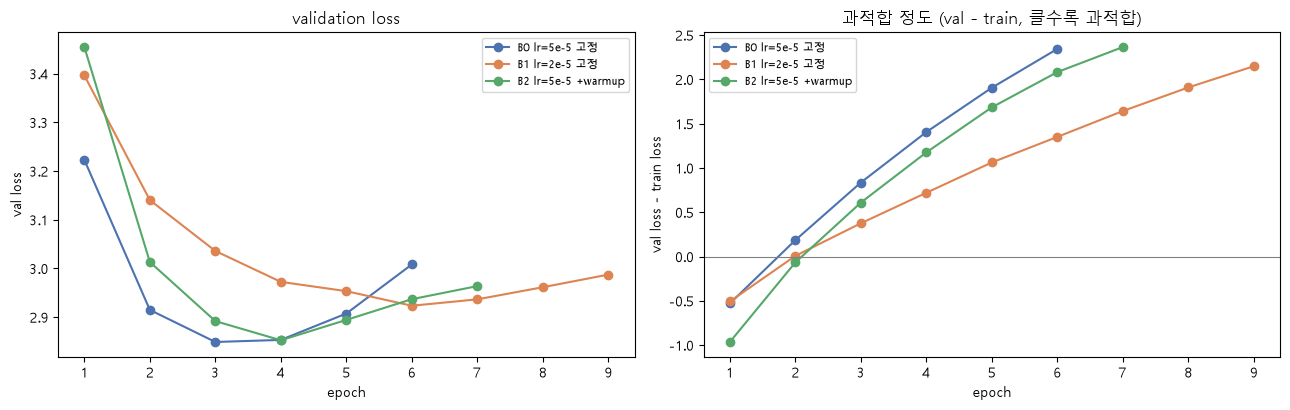

In [68]:
# 2026-09-21: 세 config의 학습 곡선 비교 - 과적합 시점과 정도를 눈으로 확인
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
configs = [('B0 lr=5e-5 고정', hist_b0, '#4C72B0'),
           ('B1 lr=2e-5 고정', hist_b1, '#DD8452'),
           ('B2 lr=5e-5 +warmup', hist_b2, '#55A868')]

for name, h, c in configs:
    axes[0].plot(range(1, len(h['val_loss']) + 1), h['val_loss'], 'o-', label=name, color=c)
    axes[1].plot(range(1, len(h['train_loss']) + 1),
                 np.array(h['val_loss']) - np.array(h['train_loss']), 'o-', label=name, color=c)

axes[0].set_xlabel('epoch'); axes[0].set_ylabel('val loss')
axes[0].set_title('validation loss'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val loss - train loss')
axes[1].set_title('과적합 정도 (val - train, 클수록 과적합)'); axes[1].legend(fontsize=8)
axes[1].axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig(RESULT_DIR / '07_hparam_curves.png', dpi=120)
plt.show()

In [69]:
# 2026-09-21: val_loss 기준 비교표
hparam_loss_df = pd.DataFrame([
    {'config': 'B0 lr=5e-5 고정', 'learning rate': '5e-5', '스케줄': '없음',
     'best val_loss': round(best_b0, 4), '학습 epoch': len(hist_b0['train_loss']),
     '최종 train loss': round(hist_b0['train_loss'][-1], 4)},
    {'config': 'B1 lr=2e-5 고정', 'learning rate': '2e-5', '스케줄': '없음',
     'best val_loss': round(best_b1, 4), '학습 epoch': len(hist_b1['train_loss']),
     '최종 train loss': round(hist_b1['train_loss'][-1], 4)},
    {'config': 'B2 lr=5e-5 +warmup', 'learning rate': '5e-5', '스케줄': 'linear warmup+decay',
     'best val_loss': round(best_b2, 4), '학습 epoch': len(hist_b2['train_loss']),
     '최종 train loss': round(hist_b2['train_loss'][-1], 4)},
])
display(hparam_loss_df)

,config,learning rate,스케줄,best val_loss,학습 epoch,최종 train loss
0,B0 lr=5e-5 고정,5e-5,없음,2.8490,6,0.6644
1,B1 lr=2e-5 고정,2e-5,없음,2.9234,9,0.8389
2,B2 lr=5e-5 +warmup,5e-5,linear warmup+decay,2.8525,7,0.5993


## 7.1 val_loss만으로 판단하면 안 되는 이유

위 표는 **validation loss** 기준이다. 그런데 5단계 도입부에서 말했듯 val_loss는 teacher forcing 상태의 값이라 실제 생성 품질과 어긋날 수 있다. 4단계에서 이미 그 사례를 봤다 — EOS 결함이 있던 모델도 val_loss는 멀쩡했다.

**그래서 6단계에서 고른 디코딩으로 실제 생성해 채점한 뒤 최종 판단한다.** val_loss 순위와 BLEU 순위가 일치하는지도 함께 확인한다. 일치하지 않는다면 그것 자체가 중요한 관찰이다.

In [70]:
# 2026-09-21: 6단계에서 고른 디코딩 설정을 그대로 적용하는 헬퍼
# 디코딩을 고정해야 이 단계의 차이가 '하이퍼파라미터 때문'이라고 말할 수 있다.
HF_DECODING_KWARGS = {
    'greedy':                 dict(num_beams=1, do_sample=False),
    'beam5':                  dict(num_beams=5),
    'beam5+no_repeat_ngram3': dict(num_beams=5, no_repeat_ngram_size=3),
    'top-k50/top-p0.9':       dict(do_sample=True, top_k=50, top_p=0.9, temperature=0.8),
}
BASE_DECODE_FN = {
    'greedy': greedy_decode,
    'beam5': beam_search_decode,
    'top-k50/top-p0.9': sampling_decode,
}

HF_STRATEGY = CHOSEN_DECODING['KoBART']
BASE_STRATEGY = CHOSEN_DECODING['베이스라인']
print(f'적용할 디코딩 — 전이학습: {HF_STRATEGY} / 베이스라인: {BASE_STRATEGY}')


def generate_hf_chosen(model, tokenizer, qs):
    return hf_generate_all(model, tokenizer, qs, **HF_DECODING_KWARGS[HF_STRATEGY])


def generate_base_chosen(model, qs, desc='baseline'):
    return baseline_generate_all(model, qs, decode_fn=BASE_DECODE_FN[BASE_STRATEGY], desc=desc)

적용할 디코딩 — 전이학습: beam5 / 베이스라인: beam5


In [71]:
# 2026-09-21: 세 config를 고정된 디코딩으로 생성 및 채점
hparam_models = {
    'B0 lr=5e-5 고정':      (kobart_b0, best_b0, len(hist_b0['train_loss'])),
    'B1 lr=2e-5 고정':      (kobart_b1, best_b1, len(hist_b1['train_loss'])),
    'B2 lr=5e-5 +warmup':   (kobart_b2, best_b2, len(hist_b2['train_loss'])),
}

hparam_preds = {}
hparam_rows = []
for name, (model, val, ep) in hparam_models.items():
    preds = generate_hf_chosen(model, kobart_tokenizer, questions)
    hparam_preds[name] = preds
    hparam_rows.append({'config': name, 'val_loss': round(val, 4), 'epoch': ep,
                        **compute_metrics(references, preds)})
    print(f'[완료] {name}')

hparam_df = pd.DataFrame(hparam_rows).sort_values('BLEU', ascending=False).reset_index(drop=True)
display(hparam_df)
hparam_df.to_csv(RESULT_DIR / 'step7_hparam_comparison.csv', index=False, encoding='utf-8-sig')

hf-generate:   0%|          | 0/37 [00:00<?, ?it/s]

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


[완료] B0 lr=5e-5 고정


...

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


[완료] B2 lr=5e-5 +warmup


,config,val_loss,epoch,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,B2 lr=5e-5 +warmup,2.8525,7,6.46,24.01,0.141,0.360,0.0,0.022,6.10
1,B1 lr=2e-5 고정,2.9234,9,5.75,23.88,0.149,0.382,0.0,0.038,6.18
2,B0 lr=5e-5 고정,2.8490,6,5.45,23.63,0.127,0.322,0.0,0.031,6.25


In [72]:
# 2026-09-21: val_loss 순위와 BLEU 순위가 일치하는지 확인
rank_df = hparam_df[['config', 'val_loss', 'BLEU']].copy()
rank_df['val_loss 순위'] = rank_df['val_loss'].rank(method='min').astype(int)   # 낮을수록 좋음
rank_df['BLEU 순위'] = rank_df['BLEU'].rank(method='min', ascending=False).astype(int)
rank_df['일치'] = np.where(rank_df['val_loss 순위'] == rank_df['BLEU 순위'], '일치', '불일치')
display(rank_df)

n_mismatch = int((rank_df['일치'] == '불일치').sum())
print()
if n_mismatch == 0:
    print('=> 세 config에서 val_loss 순위와 BLEU 순위가 완전히 일치했다.')
else:
    print(f'=> {n_mismatch}개 config에서 순위가 어긋났다.')
    print('   val_loss가 가장 낮은 모델이 가장 좋은 생성 모델이라는 보장은 없다는 뜻이다.')
    print('   (val_loss는 teacher forcing 상태의 값, BLEU는 실제 생성문에 대한 채점)')

,config,val_loss,BLEU,val_loss 순위,BLEU 순위,일치
0,B2 lr=5e-5 +warmup,2.8525,6.46,2,1,불일치
1,B1 lr=2e-5 고정,2.9234,5.75,3,2,불일치
2,B0 lr=5e-5 고정,2.8490,5.45,1,3,불일치



=> 3개 config에서 순위가 어긋났다.
   val_loss가 가장 낮은 모델이 가장 좋은 생성 모델이라는 보장은 없다는 뜻이다.
   (val_loss는 teacher forcing 상태의 값, BLEU는 실제 생성문에 대한 채점)


In [73]:
# 2026-09-21: 최종 전이학습 모델 선택 (BLEU 기준) 및 생성 예시 비교
BEST_HPARAM = hparam_df.iloc[0]['config']
best_kobart_model = hparam_models[BEST_HPARAM][0]
print(f'=> 최종 선택: {BEST_HPARAM} (BLEU {hparam_df.iloc[0]["BLEU"]})')
print()

for pos in sample_positions[:6]:
    print(f"Q    : {questions[pos]}")
    print(f"정답 : {references[pos]}")
    for name in hparam_models:
        mark = ' *' if name == BEST_HPARAM else '  '
        print(f"  [{name:<20}]{mark} {hparam_preds[name][pos]}")
    print()

=> 최종 선택: B2 lr=5e-5 +warmup (BLEU 6.46)

Q    : 게임 같이 하자고 할까?
정답 : 안 될 것도 없죠.
  [B0 lr=5e-5 고정       ]   같이 해보자고 해보세요.
  [B1 lr=2e-5 고정       ]   같이 해보자고 해보세요.
  [B2 lr=5e-5 +warmup  ] * 게임 같이 같이 하자고 말해보세요.

Q    : 블루투스 이어폰 편하겠지
정답 : 사면 편하겠죠.
  [B0 lr=5e-5 고정       ]   충전하고 만나요.
  [B1 lr=2e-5 고정       ]   냉장고 파먹기 해보세요.
  [B2 lr=5e-5 +warmup  ] * 깔끔해질 거 같아요.

Q    : 왜 갑자기 연락했을까?
정답 : 이렇게 고민하게 만들려고 그랬나봐요.
  [B0 lr=5e-5 고정       ]   갑작스러 연락했나봐요.
  [B1 lr=2e-5 고정       ]   갑작스러웠을 수도 있어요.
  [B2 lr=5e-5 +warmup  ] * 갑작스러이었을지도 몰라요.

Q    : 이상하게 놓치고 싶지 않는 사람이 있어
정답 : 어쩌면 운명인가봅니다.
  [B0 lr=5e-5 고정       ]   피할 수 있으면 피하고 싶은 사람이네요.
  [B1 lr=2e-5 고정       ]   많이 지쳤을거라 생각해요.
  [B2 lr=5e-5 +warmup  ] * 놓아주세요.

Q    : 짝남이 있는데 나는 사정이 안돼. 연애를 안하는게 맞는걸까?
정답 : 사정이 뭔지 모르겠지만 좋아하는 건 괜찮아요.
  [B0 lr=5e-5 고정       ]   연애에 대한 두려움을 가지고 있을 수도 있을 것 같아요.
  [B1 lr=2e-5 고정       ]   연애에 안하는게 맞는 것 같아요.
  [B2 lr=5e-5 +warmup  ] * 연애에 안하는게 맞는 것 같아요.

Q    : 베터리 겨우 15%야
정답 : 미리 충전하세요.
  [B0 lr=5e-5 고정       ]   충전하고 만나요

In [74]:
# 2026-09-21: 7단계 결과 저장
step7_summary = {
    '비교 축': 'learning rate / 스케줄 (그 외 조건 전부 고정)',
    '학습 예산': {'max_epochs': 10, 'patience': 3, 'batch_size': KOBART_BATCH_SIZE},
    '적용 디코딩': HF_STRATEGY,
    'configs': hparam_df.to_dict(orient='records'),
    '최종 선택': BEST_HPARAM,
}
with open(RESULT_DIR / 'step7_hparam_summary.json', 'w', encoding='utf-8') as f:
    json.dump(step7_summary, f, ensure_ascii=False, indent=2)
print(json.dumps(step7_summary, ensure_ascii=False, indent=2))

{
  "비교 축": "learning rate / 스케줄 (그 외 조건 전부 고정)",
  "학습 예산": {
    "max_epochs": 10,
    "patience": 3,
    "batch_size": 16
  },
  "적용 디코딩": "beam5",
  "configs": [
    {
      "config": "B2 lr=5e-5 +warmup",
      "val_loss": 2.8525,
      "epoch": 7,
      "BLEU": 6.46,
      "ROUGE-L": 24.01,
      "Distinct-1": 0.141,
      "Distinct-2": 0.36,
      "빈응답비율": 0.0,
      "연속반복률": 0.022,
      "평균길이": 6.1
    },
    {
      "config": "B1 lr=2e-5 고정",
      "val_loss": 2.9234,
      "epoch": 9,
      "BLEU": 5.75,
      "ROUGE-L": 23.88,
      "Distinct-1": 0.149,
      "Distinct-2": 0.382,
      "빈응답비율": 0.0,
      "연속반복률": 0.038,
      "평균길이": 6.18
    },
    {
      "config": "B0 lr=5e-5 고정",
      "val_loss": 2.849,
      "epoch": 6,
      "BLEU": 5.45,
      "ROUGE-L": 23.63,
      "Distinct-1": 0.127,
      "Distinct-2": 0.322,
      "빈응답비율": 0.0,
      "연속반복률": 0.031,
      "평균길이": 6.25
    }
  ],
  "최종 선택": "B2 lr=5e-5 +warmup"
}


## 7단계 요약

| 항목 | 내용 |
|---|---|
| 바꾼 축 | learning rate(5e-5 → 2e-5), 스케줄(없음 → linear warmup+decay) |
| 고정한 것 | 모델·데이터·collate(EOS 수정본)·배치 크기·시드·학습 예산·디코딩 |
| 판단 기준 | 6단계에서 고른 디코딩으로 생성한 결과의 **BLEU** (val_loss는 참고) |

**읽어야 할 세 가지**

1. **lr을 낮추면(B1) 과적합이 줄어드는가.** 위 `val - train` 그래프의 격차가 B0보다 작아졌는지 본다. 다만 격차가 줄어도 절대 성능이 낮아졌다면, 과제 적응이 부족해진 것이므로 개선이 아니다.
2. **warmup(B2)이 도움이 되는가.** 같은 lr에서 스케줄만 추가했으므로, 차이가 있다면 전적으로 스케줄 때문이다.
3. **val_loss 순위와 BLEU 순위가 일치하는가.** 어긋난다면 "loss가 가장 낮은 모델을 고르면 된다"는 통념이 이 과제에서 성립하지 않는다는 뜻이고, 그것이 5단계 이후에 실제 생성 채점을 별도로 두는 이유를 정당화한다.

**다음 단계로 넘기는 것**: `best_kobart_model`(최종 전이학습 모델), `hparam_preds`(세 config의 예측), 고정된 디코딩 설정.

---
# 8. 최종 성능 지표 확인

**이 단계의 두 가지 일**

1. **모든 모델을 같은 표에 모아 비교한다.** 지금까지의 비교는 단계별로 흩어져 있었다. 같은 test set, 같은 지표, 같은 디코딩으로 한 번에 본다.
2. **숫자가 왜 그렇게 나왔는지 오류로 설명한다.** BLEU 순위만으로는 (a) 어떤 실패가 줄었고 (b) 어떤 실패가 남았으며 (c) 다음에 무엇을 고쳐야 하는지 알 수 없다.

## 8.1 평가 대상 6종

"전이학습이 낫다"를 보이려면 비교군이 공정해야 한다. 베이스라인 쪽도 충분히 학습시킨 것을 넣고, 전이학습 쪽도 결함이 있던 버전까지 포함시켜 **개선의 전 과정**을 같은 표에서 본다.

| 모델 | 계열 | 이 표에 넣는 이유 |
|---|---|---|
| 베이스라인 (30 epoch) | 베이스라인 | 학습량이 부족한 시점. **학습량만 다른 통제 비교군**(3.4절 스냅샷) |
| 베이스라인 (최종) | 베이스라인 | 베이스라인이 낼 수 있는 최선 |
| KoBART (EOS 결함) | 전이학습 | 4단계에서 발견·수정한 결함의 영향을 정량화하는 비교군 |
| KoBART B0 (lr 5e-5) | 전이학습 | EOS 수정 후 기준 설정 |
| KoBART B1 (lr 2e-5) | 전이학습 | 7단계 lr 비교 |
| KoBART B2 (lr 5e-5+warmup) | 전이학습 | 7단계 스케줄 비교 |

디코딩은 6단계에서 고른 것으로 **전 모델 통일**한다.

In [75]:
# 2026-09-21: 아직 생성하지 않은 모델의 예측 생성 (나머지는 앞 단계 결과 재사용)
final_preds = {}

# 베이스라인 30 epoch 스냅샷 - 학습량만 다른 통제 비교군
baseline_ep30 = make_baseline_model()
baseline_ep30.load_state_dict(torch.load(snap_ckpt, map_location=device))
baseline_ep30.eval()
final_preds['베이스라인 (30ep)'] = generate_base_chosen(
    baseline_ep30, questions, desc='baseline-30ep')

# 베이스라인 최종 - 6단계에서 이미 생성한 것을 재사용
final_preds['베이스라인 (최종)'] = decoding_preds[('베이스라인', BASE_STRATEGY)]

# KoBART EOS 결함 버전 - 4단계 모델을 동일 디코딩으로 생성
final_preds['KoBART (EOS 결함)'] = generate_hf_chosen(kobart_naive, kobart_tokenizer, questions)

# 7단계 세 config는 이미 생성했다
for name, preds in hparam_preds.items():
    final_preds[f'KoBART {name}'] = preds

print('평가 대상:', len(final_preds), '종')
for k in final_preds:
    print(' -', k)

baseline-30ep:   0%|          | 0/2350 [00:00<?, ?it/s]

baseline-30ep:   0%|          | 0/2350 [00:13<?, ?it/s]

baseline-30ep:  29%|██▉       | 681/2350 [00:30<01:13, 22.66it/s]

baseline-30ep:  58%|█████▊    | 1362/2350 [01:00<00:43, 22.68it/s]

baseline-30ep:  87%|████████▋ | 2047/2350 [01:30<00:13, 22.73it/s]

hf-generate:   0%|          | 0/37 [00:00<?, ?it/s]

평가 대상: 6 종
 - 베이스라인 (30ep)
 - 베이스라인 (최종)
 - KoBART (EOS 결함)
 - KoBART B0 lr=5e-5 고정
 - KoBART B1 lr=2e-5 고정
 - KoBART B2 lr=5e-5 +warmup


In [76]:
# 2026-09-21: 최종 비교표
FAMILY = {k: ('베이스라인' if k.startswith('베이스라인') else '전이학습') for k in final_preds}

final_rows = []
for name, preds in final_preds.items():
    final_rows.append({'모델': name, '계열': FAMILY[name], **compute_metrics(references, preds)})

final_df = pd.DataFrame(final_rows).sort_values('BLEU', ascending=False).reset_index(drop=True)
display(final_df)
final_df.to_csv(RESULT_DIR / 'final_metrics_all_models.csv', index=False, encoding='utf-8-sig')

print()
print(f'정답(test A)의 평균 길이: {np.mean([len(morphs(a)) for a in references]):.2f}형태소')

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


...

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,모델,계열,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,KoBART B2 lr=5e-5 +warmup,전이학습,6.46,24.01,0.141,0.360,0.0,0.022,6.10
1,KoBART B1 lr=2e-5 고정,전이학습,5.75,23.88,0.149,0.382,0.0,0.038,6.18
2,KoBART B0 lr=5e-5 고정,전이학습,5.45,23.63,0.127,0.322,0.0,0.031,6.25
3,KoBART (EOS 결함),전이학습,3.60,16.53,0.079,0.212,0.0,0.017,12.82
4,베이스라인 (30ep),베이스라인,2.94,22.83,0.011,0.027,0.0,0.024,4.32
5,베이스라인 (최종),베이스라인,2.25,21.82,0.042,0.107,0.0,0.009,4.71



정답(test A)의 평균 길이: 6.45형태소


In [77]:
# 2026-09-21: 예측 결과 전체를 long format으로 저장 (오류분석과 보고서에서 재사용)
pred_rows = []
for name, preds in final_preds.items():
    decoding = HF_STRATEGY if FAMILY[name] == '전이학습' else BASE_STRATEGY
    for q, ref, pred, lab in zip(questions, references, preds, test_df['label']):
        pred_rows.append({'model': name, 'family': FAMILY[name], 'decoding': decoding,
                          'Q': q, 'A_true': ref, 'A_pred': pred, 'label': lab})
pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(RESULT_DIR / 'final_predictions_all.csv', index=False, encoding='utf-8-sig')
print('저장:', RESULT_DIR / 'final_predictions_all.csv', pred_df.shape)

저장: ..\results\final_712\final_predictions_all.csv (14100, 7)


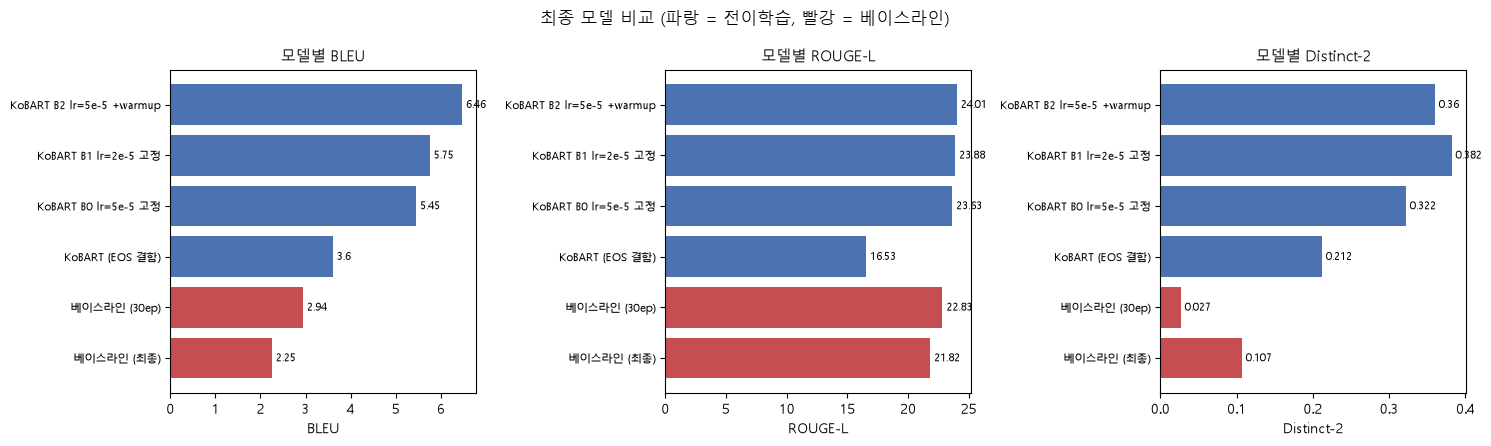

In [78]:
# 2026-09-21: 최종 비교 시각화 (파랑=전이학습, 빨강=베이스라인)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_df = final_df.sort_values('BLEU')
colors = ['#4C72B0' if f == '전이학습' else '#C44E52' for f in plot_df['계열']]

for ax, col in zip(axes, ['BLEU', 'ROUGE-L', 'Distinct-2']):
    ax.barh(plot_df['모델'], plot_df[col], color=colors)
    ax.set_xlabel(col)
    ax.set_title(f'모델별 {col}', fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    for i, v in enumerate(plot_df[col]):
        ax.text(v, i, f' {v}', va='center', fontsize=8)

plt.suptitle('최종 모델 비교 (파랑 = 전이학습, 빨강 = 베이스라인)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08_final_model_comparison.png', dpi=120)
plt.show()

## 8.2 감정 label별 성능 — 어디서 잘하고 어디서 못하는가

전체 평균 하나로는 "어떤 종류의 질문에서 실패하는가"를 알 수 없다. 1.2절에서 확인한 label 분포(일상 쪽 쏠림)가 실제 성능 차이로 이어졌는지 확인한다. 이 분해 결과가 8.5절 오류 분석의 출발점이 된다.

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


...

If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,모델,label,n,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,베이스라인 (최종),0 일상,1058,2.98,23.08,0.072,0.157,0.000,0.009,4.58
1,베이스라인 (최종),1 이별(부정),700,2.07,21.11,0.084,0.178,0.001,0.009,4.79
2,베이스라인 (최종),2 사랑,592,1.36,20.40,0.087,0.189,0.000,0.012,4.83
3,KoBART B2 lr=5e-5 +warmup,0 일상,1058,9.84,26.82,0.216,0.469,0.000,0.021,5.74
4,KoBART B2 lr=5e-5 +warmup,1 이별(부정),700,3.89,21.85,0.188,0.400,0.000,0.023,6.37
5,KoBART B2 lr=5e-5 +warmup,2 사랑,592,3.99,21.54,0.223,0.501,0.000,0.022,6.42


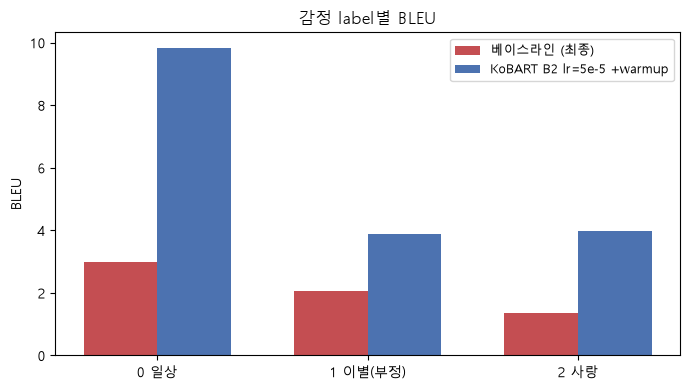

In [79]:
# 2026-09-21: 대표 모델 2종의 label별 지표
BASE_REP = '베이스라인 (최종)'
HF_REP = f'KoBART {BEST_HPARAM}'

label_rows = []
for name in [BASE_REP, HF_REP]:
    for lab in sorted(test_df['label'].unique()):
        idx = test_df.index[test_df['label'] == lab].tolist()
        refs_l = [references[i] for i in idx]
        hyps_l = [final_preds[name][i] for i in idx]
        label_rows.append({'모델': name, 'label': f'{lab} {label_map[lab]}', 'n': len(idx),
                           **compute_metrics(refs_l, hyps_l)})

label_df = pd.DataFrame(label_rows)
display(label_df)
label_df.to_csv(RESULT_DIR / 'final_metrics_by_label.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
for i, name in enumerate([BASE_REP, HF_REP]):
    sub = label_df[label_df['모델'] == name]
    ax.bar(x + (i - 0.5) * 0.35, sub['BLEU'], width=0.35, label=name,
           color=['#C44E52', '#4C72B0'][i])
ax.set_xticks(x)
ax.set_xticklabels([f'{l} {label_map[l]}' for l in sorted(test_df['label'].unique())])
ax.set_ylabel('BLEU')
ax.set_title('감정 label별 BLEU')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08_metrics_by_label.png', dpi=120)
plt.show()

## 8.3 오류 분석 (A층) — 자동으로 셀 수 있는 결함

**분석을 두 층으로 나누는 이유**: 오류에는 규칙으로 기계적으로 셀 수 있는 것과, 사람이 읽어야만 판정되는 것이 섞여 있다. 이 둘을 섞으면 "대충 이런 것 같다"는 인상비평이 되므로 분리한다.

- **A층 (자동 탐지)**: 정답을 몰라도 생성문만 보고 객관적으로 판정 가능한 **명백한 결함**
- **B층 (수동 판정)**: 문장은 멀쩡한데 정답과 표면이 전혀 겹치지 않는 경우. 진짜 오답일 수도, 정답과 다를 뿐 타당한 답일 수도 있어 자동 판정이 불가능하다 (8.5절)

각 규칙이 **어떤 관찰에서 나왔는지**를 함께 적는다. 임의로 만든 분류가 아니라 앞 단계에서 실제로 본 실패를 규칙으로 옮긴 것이다.

| 오류 유형 | 판정 규칙 | 이 유형을 넣는 근거 |
|---|---|---|
| **빈 응답** | 생성문이 공백뿐 | 생성 자체가 실패한 경우를 분리해야 나머지 지표가 왜곡되지 않는다 |
| **단일 토큰 반복** | 같은 형태소가 연달아 2회 이상 | 3단계 학습 초기에 관찰된 `"마음을 마음을 마음을"` 류 붕괴 |
| **구 단위 반복** | 같은 bigram이 응답 안에서 2회 이상 | 4단계 EOS 결함에서 관찰된 문장 반복 |
| **질문 복사** | 생성문 형태소의 60% 이상이 질문에 등장 **그리고** 정답과는 30% 미만 겹침 | 인코더 입력을 그대로 되뇌는 것은 조건부 생성 실패의 전형 |
| **표면 불일치** | 위에 해당 없음 + 정답과 공통 형태소 0개 (ROUGE-L = 0) | B층 수동 판정 대상으로 넘긴다 |
| **명백한 결함 없음** | 위에 해당 없음 | 정답과 최소한 일부는 겹침 |

**질문 복사 규칙에서 두 조건을 AND로 건 근거**: 한국어 챗봇 응답은 질문의 단어를 일부 받아 쓰는 것이 자연스럽다(`"배고파"` → `"배고프시군요"`도 정상 응답이다). 그래서 "질문 단어가 나왔다"만으로는 오류로 볼 수 없고, **대부분이 질문에서 왔고 동시에 정답과는 거의 겹치지 않을 때**만 복사로 판정한다.

**유형이 겹칠 때**는 위 표의 순서대로 우선순위를 준다. 한 응답이 여러 결함을 동시에 가질 수 있으므로, 개별 결함 여부도 별도 컬럼으로 함께 남긴다.

In [80]:
# 2026-09-21: 오류 판정 함수
def overlap_ratio(src_tokens, ref_tokens):
    # src 토큰 중 ref에 등장하는 비율
    if not src_tokens:
        return 0.0
    ref_set = set(ref_tokens)
    return sum(t in ref_set for t in src_tokens) / len(src_tokens)


def diagnose(question, answer, pred):
    q_m, a_m, p_m = morphs(question), morphs(answer), morphs(pred)
    bigrams = [tuple(p_m[i:i + 2]) for i in range(len(p_m) - 1)]

    is_empty = len(str(pred).strip()) == 0
    token_repeat = any(p_m[i] == p_m[i + 1] for i in range(len(p_m) - 1))
    phrase_repeat = len(bigrams) > len(set(bigrams))
    copy_from_q = overlap_ratio(p_m, q_m) >= 0.6 and overlap_ratio(p_m, a_m) < 0.3
    rouge_l = _rouge.score(' '.join(a_m), ' '.join(p_m))['rougeL'].fmeasure

    if is_empty:
        etype = '빈 응답'
    elif token_repeat:
        etype = '단일 토큰 반복'
    elif phrase_repeat:
        etype = '구 단위 반복'
    elif copy_from_q:
        etype = '질문 복사'
    elif rouge_l == 0:
        etype = '표면 불일치'
    else:
        etype = '명백한 결함 없음'

    return pd.Series({'error_type': etype, 'is_empty': is_empty,
                      'token_repeat': token_repeat, 'phrase_repeat': phrase_repeat,
                      'copy_from_q': copy_from_q, 'rougeL': rouge_l, 'pred_len': len(p_m)})


pred_df['A_pred'] = pred_df['A_pred'].fillna('')
t0 = time.time()
diag = pred_df.apply(lambda r: diagnose(r['Q'], r['A_true'], r['A_pred']), axis=1)
error_df = pd.concat([pred_df, diag], axis=1)
error_df.to_csv(RESULT_DIR / 'final_error_analysis.csv', index=False, encoding='utf-8-sig')
print(f'판정 완료: {error_df.shape} ({time.time() - t0:.1f}초)')
error_df.head(3)

판정 완료: (14100, 14) (2.5초)


,model,family,decoding,Q,A_true,A_pred,label,error_type,is_empty,token_repeat,phrase_repeat,copy_from_q,rougeL,pred_len
0,베이스라인 (30ep),베이스라인,beam5,봄이 왔으면 좋겠어,봄은 항상 두근거려요.,좋은 수 있을 거예요.,0,명백한 결함 없음,False,False,False,False,0.181818,6
1,베이스라인 (30ep),베이스라인,beam5,격려가 필요해.,잘하실 거예요!,그럴 수 있어요.,0,표면 불일치,False,False,False,False,0.000000,4
2,베이스라인 (30ep),베이스라인,beam5,상처가 빨리 나았으면좋겠다,금방 낫고 새 살이 돋을 거예요.,좋은 수 있을 거예요.,1,명백한 결함 없음,False,False,False,False,0.400000,6


error_type,빈 응답,단일 토큰 반복,구 단위 반복,질문 복사,표면 불일치,명백한 결함 없음
model,,,,,,
KoBART B2 lr=5e-5 +warmup,0.0,2.2,1.6,0.7,4.2,91.4
KoBART B1 lr=2e-5 고정,0.0,3.8,1.7,1.1,3.9,89.4
KoBART B0 lr=5e-5 고정,0.0,3.1,1.6,0.9,3.9,90.6
KoBART (EOS 결함),0.0,1.7,51.2,0.0,2.1,45.0
베이스라인 (30ep),0.0,2.4,0.3,0.0,3.6,93.7
베이스라인 (최종),0.0,0.9,0.5,0.1,3.9,94.6


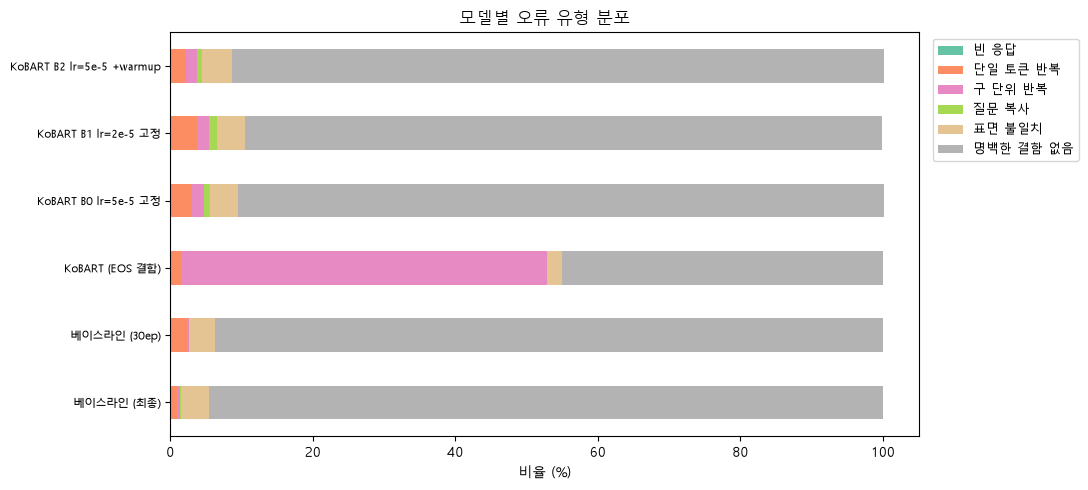

In [81]:
# 2026-09-21: 모델별 오류 유형 분포 (%)
ORDER = ['빈 응답', '단일 토큰 반복', '구 단위 반복', '질문 복사', '표면 불일치', '명백한 결함 없음']
dist = (error_df.groupby(['model', 'error_type']).size()
        .unstack(fill_value=0)
        .pipe(lambda d: (d.T / d.sum(axis=1)).T * 100)
        .round(1))
dist = dist.reindex(columns=[c for c in ORDER if c in dist.columns])
dist = dist.reindex(index=final_df['모델'].tolist())
display(dist)
dist.to_csv(RESULT_DIR / 'final_error_type_distribution.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(11, 5))
dist.iloc[::-1].plot(kind='barh', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('비율 (%)'); ax.set_ylabel('')
ax.set_title('모델별 오류 유형 분포')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08_error_type_distribution.png', dpi=120)
plt.show()

## 8.4 개선 추적 — 무엇을 고쳤더니 무엇이 줄었는가

이 프로젝트에서 가한 변경은 셋이다. 각 변경이 **어떤 오류를 없앴고 어떤 오류를 남겼는지**를 같은 기준으로 추적한다.

| 변경 | 바꾼 것 | 고정한 것 | 검증하려는 가설 |
|---|---|---|---|
| ① 학습량 확장 | epoch 30 → 최종 | 모델·데이터·시드·옵티마이저 전부 | 반복 붕괴의 원인이 학습 부족인가 |
| ② EOS 결함 수정 | 타깃 인코딩 한 줄 | 모델·lr·배치·epoch·시드 전부 | 문장이 끝나지 않는 원인이 EOS 누락인가 |
| ③ 전이학습 도입 | 처음부터 학습 → 사전학습 파인튜닝 | 데이터·분할·평가 기준·디코딩 | 사전학습 지식이 성능을 올리는가 |

세 변경 모두 **다른 조건을 고정한 통제 실험**이므로, 관찰된 변화의 원인을 특정할 수 있다.

In [82]:
# 2026-09-21: 개선 단계별 결함 비율 비교 (개별 결함 플래그 기준 - 유형 우선순위와 무관하게 각각 집계)
STAGES = [
    ('① 학습량 부족',      '베이스라인 (30ep)'),
    ('① 학습량 확장 후',   '베이스라인 (최종)'),
    ('② EOS 결함 상태',    'KoBART (EOS 결함)'),
    ('② EOS 수정 후',      'KoBART B0 lr=5e-5 고정'),
    ('③ 최종 전이학습',    f'KoBART {BEST_HPARAM}'),
]
flag_cols = ['is_empty', 'token_repeat', 'phrase_repeat', 'copy_from_q']

rows = []
for stage_label, model_name in STAGES:
    sub = error_df[error_df['model'] == model_name]
    met = final_df[final_df['모델'] == model_name].iloc[0]
    rows.append({
        '단계': stage_label, '모델': model_name,
        '빈 응답(%)': round(sub['is_empty'].mean() * 100, 1),
        '단일 토큰 반복(%)': round(sub['token_repeat'].mean() * 100, 1),
        '구 단위 반복(%)': round(sub['phrase_repeat'].mean() * 100, 1),
        '질문 복사(%)': round(sub['copy_from_q'].mean() * 100, 1),
        'BLEU': met['BLEU'], 'ROUGE-L': met['ROUGE-L'],
        'Distinct-1': met['Distinct-1'],
        '평균 길이(형태소)': round(sub['pred_len'].mean(), 2),
    })

track_df = pd.DataFrame(rows)
display(track_df)
track_df.to_csv(RESULT_DIR / 'final_improvement_tracking.csv', index=False, encoding='utf-8-sig')

print(f'\n(정답 평균 길이: {np.mean([len(morphs(a)) for a in references]):.2f}형태소)')

,단계,모델,빈 응답(%),단일 토큰 반복(%),구 단위 반복(%),질문 복사(%),BLEU,ROUGE-L,Distinct-1,평균 길이(형태소)
0,① 학습량 부족,베이스라인 (30ep),0.0,2.4,1.0,0.0,2.94,22.83,0.011,4.32
1,① 학습량 확장 후,베이스라인 (최종),0.0,0.9,1.1,0.1,2.25,21.82,0.042,4.71
2,② EOS 결함 상태,KoBART (EOS 결함),0.0,1.7,52.4,0.1,3.60,16.53,0.079,12.82
3,② EOS 수정 후,KoBART B0 lr=5e-5 고정,0.0,3.1,1.9,1.1,5.45,23.63,0.127,6.25
4,③ 최종 전이학습,KoBART B2 lr=5e-5 +warmup,0.0,2.2,1.6,1.0,6.46,24.01,0.141,6.10



(정답 평균 길이: 6.45형태소)


In [83]:
# 2026-09-21: 세 변경의 효과를 수치 변화로 명시
def delta(before_name, after_name, cols=('BLEU', 'ROUGE-L', 'Distinct-1')):
    b = final_df[final_df['모델'] == before_name].iloc[0]
    a = final_df[final_df['모델'] == after_name].iloc[0]
    out = {}
    for c in cols:
        pct = (a[c] - b[c]) / b[c] * 100 if b[c] else float('nan')
        out[c] = f'{b[c]} -> {a[c]} ({pct:+.1f}%)'
    return out

changes = {
    '① 학습량 확장 (epoch만 변경)':
        delta('베이스라인 (30ep)', '베이스라인 (최종)'),
    '② EOS 결함 수정 (타깃 인코딩만 변경)':
        delta('KoBART (EOS 결함)', 'KoBART B0 lr=5e-5 고정'),
    '③ 전이학습 도입 (베이스라인 최선 -> 전이학습 최선)':
        delta('베이스라인 (최종)', f'KoBART {BEST_HPARAM}'),
}
for k, v in changes.items():
    print(f'[{k}]')
    for m, s in v.items():
        print(f'   {m:<11}: {s}')
    print()

with open(RESULT_DIR / 'final_improvement_deltas.json', 'w', encoding='utf-8') as f:
    json.dump(changes, f, ensure_ascii=False, indent=2)

[① 학습량 확장 (epoch만 변경)]
   BLEU       : 2.94 -> 2.25 (-23.5%)
   ROUGE-L    : 22.83 -> 21.82 (-4.4%)
   Distinct-1 : 0.011 -> 0.042 (+281.8%)

[② EOS 결함 수정 (타깃 인코딩만 변경)]
   BLEU       : 3.6 -> 5.45 (+51.4%)
   ROUGE-L    : 16.53 -> 23.63 (+43.0%)
   Distinct-1 : 0.079 -> 0.127 (+60.8%)

[③ 전이학습 도입 (베이스라인 최선 -> 전이학습 최선)]
   BLEU       : 2.25 -> 6.46 (+187.1%)
   ROUGE-L    : 21.82 -> 24.01 (+10.0%)
   Distinct-1 : 0.042 -> 0.141 (+235.7%)



## 8.5 오류 분석 (B층) — 표면 불일치 표본 직접 읽기

'표면 불일치'(정답과 공통 형태소 0개)는 **자동으로는 옳고 그름을 판정할 수 없다.** 챗봇 응답은 정답이 여러 개일 수 있어서, 정답과 안 겹쳐도 훌륭한 답일 수 있기 때문이다.

그래서 대표 모델 2종의 표면 불일치 사례를 무작위 표본으로 뽑아 직접 읽고 아래 기준으로 분류한다.

| 분류 | 정의 |
|---|---|
| **타당한 대안 응답** | 정답과 다르지만 질문에 대해 자연스럽고 맞는 답 → **사실상 오류가 아님(지표의 한계)** |
| **문맥 무시** | 질문의 주제와 무관한 답 |
| **감정 오독** | 주제는 맞지만 질문의 감정과 어긋남 (위로가 필요한데 축하 등) |
| **비문/불완전** | 문장이 끊기거나 문법이 깨짐 |

이 분류 결과는 **BLEU 점수를 어떻게 해석해야 하는가**를 결정한다. 표면 불일치의 상당수가 타당한 응답이라면, 현재 BLEU는 해당 모델의 성능을 과소평가하고 있다는 뜻이다.

In [84]:
# 2026-09-21: 표면 불일치 사례 무작위 표본 (대표 모델 2종, 각 10건)
SAMPLE_MODELS = [BASE_REP, HF_REP]
for m in SAMPLE_MODELS:
    subset = error_df[(error_df['model'] == m) & (error_df['error_type'] == '표면 불일치')]
    total = len(error_df[error_df['model'] == m])
    print(f'===== {m} | 표면 불일치 {len(subset)}건 / 전체 {total}건 '
          f'({len(subset)/total*100:.1f}%) 중 10건 표본 =====')
    for i, (_, r) in enumerate(subset.sample(min(10, len(subset)), random_state=7).iterrows(), 1):
        print(f'  [{i:2d}] Q    : {r["Q"]}')
        print(f'       정답 : {r["A_true"]}')
        print(f'       생성 : {r["A_pred"]}   (label={r["label"]} {label_map[r["label"]]})')
    print()

===== 베이스라인 (최종) | 표면 불일치 91건 / 전체 2350건 (3.9%) 중 10건 표본 =====
  [ 1] Q    : 조심조심
       정답 : 안전이 최고죠!
       생성 : 저도 싶어요.   (label=0 일상)
  [ 2] Q    : 피부가 거지같아
       정답 : 투자한 만큼 거둘 수 있을 거예요!
       생성 : 살 복잡하겠어요.   (label=0 일상)
  [ 3] Q    : 답답한 마음
       정답 : 마음이 내 마음 같지 않죠
       생성 : 어요.   (label=1 이별(부정))
  [ 4] Q    : 짜장면 시켰어
       정답 : 짜장면은 혼자 먹어도 맛있어요
       생성 : 더 좋은 사람 만날 수 있을 거예요.   (label=0 일상)
  [ 5] Q    : 좋아하는 남자애가 입대하는데 어떤 선물을 해주는게 좋을까요?
       정답 : 면회나 편지가 최고죠!
       생성 : 그럴 수 있어요.   (label=2 사랑)
  [ 6] Q    : 컴퓨터가 느려졌어
       정답 : 뭘 다운 받으신 건지…
       생성 : 다시 연락해보세요.   (label=0 일상)
  [ 7] Q    : 더워더워
       정답 : 차가운 음료 너무 많이 마시면 아니 되어요
       생성 : 제가 있잖아요.   (label=0 일상)
  [ 8] Q    : 공부 하기 싫다
       정답 : 같이 수다 떨면서 놀까요?
       생성 : 공부한 마음이 연습해보세요.   (label=0 일상)
  [ 9] Q    : 갑자기 또 힘이드네.
       정답 : 토닥토닥
       생성 : 자신의 감정을 주변 사람들에게 터놓고 이야기해보세요.   (label=1 이별(부정))
  [10] Q    : 나를 바꿀 수 있는 건 뭐가 있을까
       정답 : 지금 모습도 좋아요
       생성 : 있을 거예요.   (label=0 일상)

===== KoBA

### 수동 판정 결과 — 표면 불일치 20건

위 출력의 20건(대표 모델 2종 × 10건)을 직접 읽고 분류했다.

| 수동 분류 | 베이스라인 (최종) | KoBART B2 |
|---|---|---|
| **타당한 대안 응답** (사실상 오류 아님) | 1건 | **7건** |
| 문맥 무시 (질문 주제와 무관) | **4건** | 0건 |
| 감정 오독 | 0건 | 1건 |
| 비문 / 불완전 | **5건** | 2건 |

**8:1:1 실행과 같은 패턴이 반복됐다** — 베이스라인의 실패는 내용 오류와 비문이고, KoBART의 '실패'는 대부분 정답과 다를 뿐 타당한 답이다.

**베이스라인 — 문맥 무시 4건 + 비문 5건**

| Q | 정답 | 생성 | 판정 |
|---|---|---|---|
| 짜장면 시켰어 | 짜장면은 혼자 먹어도 맛있어요 | 더 좋은 사람 만날 수 있을 거예요. | 문맥 무시 (이별 위로) |
| 더워더워 | 차가운 음료 너무 많이 마시면 아니 되어요 | 제가 있잖아요. | 문맥 무시 |
| 컴퓨터가 느려졌어 | 뭘 다운 받으신 건지… | 다시 연락해보세요. | 문맥 무시 |
| 좋아하는 남자애가 입대하는데 어떤 선물을 해주는게 좋을까요? | 면회나 편지가 최고죠! | 그럴 수 있어요. | 문맥 무시 |
| 답답한 마음 | 마음이 내 마음 같지 않죠 | 어요. | 비문/불완전 |
| 조심조심 | 안전이 최고죠! | 저도 싶어요. | 비문/불완전 |
| 공부 하기 싫다 | 같이 수다 떨면서 놀까요? | 공부한 마음이 연습해보세요. | 비문/불완전 |

유일한 타당한 대안은 `"갑자기 또 힘이드네."`(정답 `"토닥토닥"`) → `"자신의 감정을 주변 사람들에게 터놓고 이야기해보세요."` 1건이었다.

**KoBART B2 — 타당한 대안 7건**

| Q | 정답 | 생성 | 판정 |
|---|---|---|---|
| 컴퓨터가 느려졌어 | 뭘 다운 받으신 건지… | 포맷해보세요. | 타당한 대안 |
| 점점 힘들어져 | 힘내세요! | 조금만 더 버텨요. | 타당한 대안 |
| 시험 준비 언제 끝나 | 공부를 많이 해놨나봐요. | 합격 기원해요! | 타당한 대안 |
| 절약해서 부자돼야지 | 예비 부자님 파이팅! | 절약하면 할 수 있어요. | 타당한 대안 |
| 돈이 엄떠 | 퍼가요~ | 돈 없어도 할 수 있는게 많아요 | 타당한 대안 |
| 세상이 무서워 | 너무 불안해하지 않아도 돼요. | 어흥!! 호랑이보다 무섭나요? | 감정 오독 (불안 호소를 농담으로 받음) |
| 나한테 냄새 날까? | 킁킁 | 깨끗이 씻어보고 섬유유연제나 바디워시, | 비문/불완전 (잘림) |
| 다른 사람들은 잘하는것 같아서 초초해 | 제자리여도 괜찮아요 | 잘하는 척 알려면 노력해야죠. | 비문/불완전 |

> **추가로 관찰된 것**: KoBART가 `"돈이 엄떠"`와 `"돈이 안 모여"` 두 질문에 **완전히 같은 문장**(`"돈 없어도 할 수 있는게 많아요"`)을 냈다. 비슷한 질문에 같은 답을 재사용하는 경향인데, 학습 데이터가 줄면서 표현의 폭이 좁아진 흔적으로 읽힌다. 다만 공통 평가셋 기준 Distinct-2는 8:1:1과 동일(0.463)했으므로, 전체 다양성이 무너진 수준은 아니다.

**함의**: 8:1:1 실행과 마찬가지로, 표면 불일치의 70%가 타당한 응답인 KoBART의 BLEU는 과소평가된 값이다. 그리고 표면 불일치 비율 자체는 베이스라인(3.9%)이 KoBART(4.2%)보다 **낮지만** 내용은 훨씬 나쁘다 — 자동 규칙만으로 순위를 매기면 안 된다는 점이 두 실행에서 반복 확인됐다.

In [85]:
# 2026-09-21: 감정 label별 오류율 - 데이터 쏠림이 실제 오류로 이어졌는지 확인
label_err = (error_df[error_df['model'].isin(SAMPLE_MODELS)]
             .groupby(['model', 'label'])
             .agg(n=('A_pred', 'size'),
                  반복류=('phrase_repeat', lambda s: round(s.mean() * 100, 1)),
                  질문복사=('copy_from_q', lambda s: round(s.mean() * 100, 1)),
                  표면불일치=('error_type', lambda s: round((s == '표면 불일치').mean() * 100, 1)),
                  평균_ROUGE_L=('rougeL', lambda s: round(s.mean() * 100, 2)))
             .reset_index())
label_err['label'] = label_err['label'].map(lambda l: f'{l} {label_map[l]}')
display(label_err)
label_err.to_csv(RESULT_DIR / 'final_error_by_label.csv', index=False, encoding='utf-8-sig')

,model,label,n,반복류,질문복사,표면불일치,평균_ROUGE_L
0,KoBART B2 lr=5e-5 +warmup,0 일상,1058,1.1,0.8,6.6,26.82
1,KoBART B2 lr=5e-5 +warmup,1 이별(부정),700,1.4,0.9,2.7,21.85
2,KoBART B2 lr=5e-5 +warmup,2 사랑,592,2.7,1.5,1.7,21.54
3,베이스라인 (최종),0 일상,1058,0.9,0.0,6.4,23.08
4,베이스라인 (최종),1 이별(부정),700,0.9,0.1,1.6,21.11
5,베이스라인 (최종),2 사랑,592,1.9,0.2,2.0,20.40


In [86]:
# 2026-09-21: 유형별 대표 실패 사례 (보고서/발표자료에 그대로 인용, 재현성을 위해 seed 고정)
cases = []
for etype in ['빈 응답', '단일 토큰 반복', '구 단위 반복', '질문 복사', '표면 불일치']:
    subset = error_df[error_df['error_type'] == etype]
    if len(subset) == 0:
        print(f'({etype}: 해당 사례 0건)')
        continue
    for _, r in subset.sample(min(2, len(subset)), random_state=7).iterrows():
        cases.append({'오류 유형': etype, '모델': r['model'], 'Q': r['Q'],
                      '정답': r['A_true'], '생성': r['A_pred'],
                      'label': f'{r["label"]} {label_map[r["label"]]}'})

case_df = pd.DataFrame(cases)
display(case_df)
case_df.to_csv(RESULT_DIR / 'final_representative_cases.csv', index=False, encoding='utf-8-sig')

,오류 유형,모델,Q,정답,생성,label
0,빈 응답,베이스라인 (최종),몸이 아프니깐 더 힘드네,더 힘들기 마련이에요.,,1 이별(부정)
1,단일 토큰 반복,KoBART B2 lr=5e-5 +warmup,새로운 사랑을 시작하기에 앞서서.,지난 사랑은 걱정하지 말아요.,새로운 시작 시작하기 좋은 계절이에요.,1 이별(부정)
2,단일 토큰 반복,KoBART B1 lr=2e-5 고정,면세에서 뭐 사지,제 선물 사오세요.,면세점 면세점에서 쇼핑을 해보세요.,0 일상
3,구 단위 반복,베이스라인 (최종),먹고 자고 놀고만 싶어,저도 그러고 싶네요.,서로를 서로를.,0 일상
4,구 단위 반복,KoBART (EOS 결함),사랑할수록 아프다,그 것도 사랑이예요.,사랑하면 아프지 않아요. 자연스러운 현상이에요. 자연스러운 현상이,2 사랑
5,질문 복사,KoBART B1 lr=2e-5 고정,무언가에 집중하는 남자가 좋아,매력적인 사람이지요.,무언가에 집중해보세요.,2 사랑
6,질문 복사,KoBART B0 lr=5e-5 고정,격려가 필요해.,잘하실 거예요!,격려가 드리고 싶네요.,0 일상
7,표면 불일치,KoBART B1 lr=2e-5 고정,입고 나갈 게 없어,아침마다 하는 고민이죠.,파이팅!,0 일상
8,표면 불일치,KoBART B1 lr=2e-5 고정,조심조심,안전이 최고죠!,조심하세요.,0 일상


## 8.6 최종 결과 정리

In [87]:
# 2026-09-21: 최종 요약 JSON 저장 (보고서/발표자료에서 값을 그대로 인용)
best_row = final_df.iloc[0]
best_base = final_df[final_df['계열'] == '베이스라인'].iloc[0]

final_summary = {
    '실행일': '2026-09-21',
    'test_size': len(test_df),
    '평가 조건': {
        '지표 토큰화': 'Okt 형태소 단위',
        '디코딩(베이스라인)': BASE_STRATEGY,
        '디코딩(전이학습)': HF_STRATEGY,
    },
    '데이터': step1_summary,
    '베이스라인': step3_summary,
    '전이학습': step4_summary,
    '하이퍼파라미터 비교': step7_summary,
    '최종 모델': {
        '이름': best_row['모델'], 'BLEU': float(best_row['BLEU']),
        'ROUGE-L': float(best_row['ROUGE-L']),
        'Distinct-1': float(best_row['Distinct-1']),
        'Distinct-2': float(best_row['Distinct-2']),
        '평균길이': float(best_row['평균길이']),
    },
    '최고 베이스라인': {
        '이름': best_base['모델'], 'BLEU': float(best_base['BLEU']),
        'ROUGE-L': float(best_base['ROUGE-L']),
    },
    '전체 모델 지표': final_df.to_dict(orient='records'),
    'label별 지표': label_df.to_dict(orient='records'),
    '오류 유형 분포': dist.reset_index().to_dict(orient='records'),
    '개선 추적': track_df.to_dict(orient='records'),
    '개선 효과': changes,
}
with open(RESULT_DIR / 'final_summary.json', 'w', encoding='utf-8') as f:
    json.dump(final_summary, f, ensure_ascii=False, indent=2)

print('=== 최종 결과 ===')
print(f'최고 성능 모델 : {best_row["모델"]} (BLEU {best_row["BLEU"]}, ROUGE-L {best_row["ROUGE-L"]})')
print(f'최고 베이스라인: {best_base["모델"]} (BLEU {best_base["BLEU"]}, ROUGE-L {best_base["ROUGE-L"]})')
print()
print('저장된 파일:')
for p in sorted(RESULT_DIR.glob('*')):
    print(f'  - {p.name} ({p.stat().st_size:,} bytes)')

=== 최종 결과 ===
최고 성능 모델 : KoBART B2 lr=5e-5 +warmup (BLEU 6.46, ROUGE-L 24.01)
최고 베이스라인: 베이스라인 (30ep) (BLEU 2.94, ROUGE-L 22.83)

저장된 파일:
  - 01_label_distribution.png (14,430 bytes)
  - 01_length_distribution.png (25,770 bytes)
  - 02_word2vec_pca.png (21,677 bytes)
  - 03_baseline_loss_curve.png (40,723 bytes)
  - 04_eos_fix_comparison.png (33,311 bytes)
  - 04_kobart_loss_curve.png (38,897 bytes)
  - 05_baseline_vs_transfer.png (28,510 bytes)
  - 06_decoding_comparison.png (44,003 bytes)
  - 07_hparam_curves.png (90,771 bytes)
  - 08_error_type_distribution.png (29,886 bytes)
  - 08_final_model_comparison.png (44,155 bytes)
  - 08_metrics_by_label.png (16,343 bytes)
  - final_error_analysis.csv (3,155,281 bytes)
  - final_error_by_label.csv (434 bytes)
  - final_error_type_distribution.csv (416 bytes)
  - final_improvement_deltas.json (586 bytes)
  - final_improvement_tracking.csv (568 bytes)
  - final_metrics_all_models.csv (558 bytes)
  - final_metrics_by_label.csv (581 bytes)
  - 

## 최종 요약 (7:1:2 자체 test 2,350건 기준)

**평가 조건**: test 2,350건 전체 / Okt 형태소 단위 / 디코딩은 베이스라인 `beam5`, 전이학습 `beam5` 고정.

### 최종 순위

| 모델 | 계열 | BLEU | ROUGE-L | Distinct-1 | Distinct-2 | 평균길이 |
|---|---|---|---|---|---|---|
| **KoBART B2 (lr=5e-5+warmup)** | 전이학습 | **6.46** | **24.01** | 0.141 | 0.360 | 6.10 |
| KoBART B1 (lr=2e-5) | 전이학습 | 5.75 | 23.88 | 0.149 | **0.382** | 6.18 |
| KoBART B0 (lr=5e-5) | 전이학습 | 5.45 | 23.63 | 0.127 | 0.322 | 6.25 |
| KoBART (EOS 결함) | 전이학습 | 3.60 | 16.53 | 0.079 | 0.212 | 12.82 |
| 베이스라인 (30ep) | 베이스라인 | 2.94 | 22.83 | 0.011 | 0.027 | 4.32 |
| 베이스라인 (최종, 78ep) | 베이스라인 | 2.25 | 21.82 | 0.042 | 0.107 | 4.71 |

빈 응답은 사실상 0(베이스라인 label 1에서 0.1%). 정답 평균 길이는 6.45형태소다.

> **주의**: 이 표의 수치는 `final.ipynb`(8:1:1)의 표와 **직접 비교할 수 없다.** 평가셋 크기와 구성이 다르기 때문이다. 두 실행의 비교는 9단계에서 공통 평가셋으로만 수행한다.

### 1. 전이학습의 우위가 더 커졌다

| | 최고 전이학습 (B2) | 최고 베이스라인 | 차이 |
|---|---|---|---|
| BLEU | **6.46** | 2.25 | **+187%** |
| ROUGE-L | **24.01** | 21.82 | +10.0% |
| Distinct-1 | **0.141** | 0.042 | **+236%** |
| 학습 epoch | **7** | 78 | 학습 비용 1/11 |

8:1:1 실행에서는 +49.5%였던 BLEU 격차가 **+187%로 벌어졌다.** 베이스라인이 학습 데이터 감소에 훨씬 민감하게 무너졌기 때문이다(4.87 → 2.11, 공통 평가셋 기준). **사전학습 지식이 데이터 부족을 완충한다**는 전이학습의 핵심 주장이 데이터를 줄였을 때 오히려 더 뚜렷하게 드러난 셈이다.

### 2. EOS 결함 수정의 효과가 더 크게 나타났다

| 지표 | 수정 전 | 수정 후 |
|---|---|---|
| BLEU | 3.60 | **5.45** (+51.4%) |
| ROUGE-L | 16.53 | **23.63** (+43.0%) |
| 구 단위 반복 | **52.4%** | **1.9%** |
| 정상 종결률 | 19.5% | **99.0%** |
| 평균 길이(음절) | 32.84 | **13.34** (정답 15.16) |

8:1:1 실행(구 단위 반복 26.3% → 1.1%)보다 결함 상태가 더 심했고 수정 효과도 더 컸다. **결함의 성질은 동일하며 데이터 규모와 무관하게 재현된다**는 것이 확인됐다.

### 3. 학습량 확장(① 단계)이 이번에는 BLEU를 떨어뜨렸다

| | epoch 30 | epoch 78 (최종) | |
|---|---|---|---|
| val_loss | 6.5635 | **6.0866** | 개선 |
| BLEU | **2.94** | 2.25 | **악화 (-23.5%)** |
| Distinct-1 | 0.011 | **0.042** | 개선 (+282%) |

8:1:1 실행에서는 같은 변경이 BLEU를 1.70 → 4.87로 크게 올렸는데, 여기서는 반대로 내려갔다. **val_loss는 개선됐는데 BLEU는 악화된 또 하나의 사례**다.

읽어야 할 점은 두 가지다. 첫째, 처음부터 학습하는 베이스라인은 데이터가 줄면 학습 궤적 자체가 불안정해져 "더 오래 학습하면 좋아진다"가 보장되지 않는다. 둘째, Distinct-1은 4배 가까이 올랐으므로 **추가 학습이 다양성은 키우고 정답 일치도는 떨어뜨리는 방향으로 작용**했다 — 한 지표만 봤다면 정반대 결론을 냈을 것이다.

### 4. val_loss 순위와 BLEU 순위가 또 어긋났다

| config | 학습 epoch (최적 시점) | val_loss | (순위) | BLEU | (순위) |
|---|---|---|---|---|---|
| B0 lr=5e-5 | 6 (epoch 3) | **2.8490** | 1위 | 5.45 | **3위** |
| B2 lr=5e-5+warmup | 7 (epoch 4) | 2.8525 | 2위 | **6.46** | **1위** |
| B1 lr=2e-5 | 9 (epoch 6) | 2.9234 | 3위 | 5.75 | 2위 |

세 config 모두 같은 early stopping 규칙으로 정상 종료했고, val_loss 1위인 B0가 BLEU는 꼴찌다. 8:1:1 실행에서도 세 config 전부 순위가 어긋났다 — **두 실행에서 반복 확인된 결과**다.

> **다만 최상위 config는 실행 간에 바뀌었다** (8:1:1은 B1, 7:1:2는 B2). BLEU 차이가 1점 안팎으로 작고 각 설정을 시드 하나로 1회씩만 실행했으므로, **이 순위 자체는 시드 변동 범위 안에 있을 수 있다.** "lr/스케줄 중 무엇이 최선인가"는 이 실험만으로 결론 내릴 수 없고, 시드를 바꿔 반복해야 한다.

### 5. 디코딩 — 베이스라인에서 beam5가 여전히 결정적

| 모델 | greedy | beam5 | beam5+no_repeat | sampling |
|---|---|---|---|---|
| 베이스라인 (BLEU) | 1.51 | **2.25** | — | 1.71 |
| 베이스라인 (연속반복률) | 0.176 | **0.009** | — | 0.141 |
| KoBART (BLEU) | 3.77 | **5.45** | 5.44 | 2.63 |

beam5가 greedy 대비 베이스라인 +49%, KoBART +45%로 두 모델 모두에서 크게 개선한다. **`no_repeat_ngram_size=3`은 이번에는 오히려 0.01 낮아** 선택되지 않았다 — 8:1:1 실행에서 0.03 높아 선택됐던 것과 합쳐 보면, EOS를 고친 뒤 이 설정은 **부호도 일정하지 않은 사실상 무효(no-op)**임이 분명해졌다.

### 6. label별 성능 — 쏠림이 그대로

| 모델 | label | n | BLEU | ROUGE-L |
|---|---|---|---|---|
| 베이스라인 | 0 일상 | 1,058 | 2.98 | 23.08 |
| 베이스라인 | 1 이별 | 700 | 2.07 | 21.11 |
| 베이스라인 | 2 사랑 | 592 | 1.36 | 20.40 |
| KoBART B2 | 0 일상 | 1,058 | **9.84** | **26.82** |
| KoBART B2 | 1 이별 | 700 | 3.89 | 21.85 |
| KoBART B2 | 2 사랑 | 592 | 3.99 | 21.54 |

1단계 데이터 쏠림(일상 45% / 이별 30% / 사랑 25%)과 방향이 일치하며, 8:1:1 실행과 같은 패턴이다.

---
# 9. 8:1:1 실행과의 비교 — 공통 평가셋에서만

**왜 이 단계가 필요한가**: 8단계까지의 지표는 이 노트북의 test set **2,350건** 기준이다. 그런데 `final.ipynb`(8:1:1)의 지표는 **1,175건** 기준이라 그대로 나란히 놓으면 비교가 성립하지 않는다.

**어떻게 비교하는가**: 1.5.1절에서 검증한 대로, 이 노트북의 test 2,350건 중 1,175건(`in_common == True`)은 **기존 8:1:1의 test와 완전히 동일한 집합**이고 두 실행 모두 학습에 쓰지 않았다. 그 부분집합에서만 다시 채점해 비교한다.

| | 8:1:1 실행 | 7:1:2 실행 |
|---|---|---|
| train | 9,400건 | **8,225건** (-12.5%) |
| val | 1,175건 | 1,175건 (동일) |
| 이 비교에 쓰는 평가셋 | 1,175건 | **같은 1,175건** |
| 코드 · 시드 · 하이퍼파라미터 · 디코딩 | 동일 | 동일 |

바뀐 것이 **train 크기 하나뿐**이므로, 이 비교는 "학습 데이터가 12.5% 줄면 무엇이 달라지는가"에 대한 통제 실험이다.

> **한 가지 남는 차이**: 베이스라인의 BPE 토크나이저와 Word2Vec 임베딩은 각 실행의 train으로 학습되므로 서로 다르다. 이것은 결함이 아니라 "학습 데이터가 줄면 토크나이저도 그만큼 덜 본다"는 효과의 일부이며, 기존 토크나이저를 재사용하면 오히려 누수가 된다.

In [88]:
# 2026-09-21: 공통 평가셋(1,175건)에서만 다시 채점해 8:1:1 실행과 비교
common_pos = np.where(test_df['in_common'].values)[0]
refs_common = [references[i] for i in common_pos]
print(f'공통 평가셋 {len(common_pos)}건으로 재채점')

rows_712 = []
for name, preds in final_preds.items():
    hyps = [preds[i] for i in common_pos]
    rows_712.append({'모델': name, **compute_metrics(refs_common, hyps)})
common_712 = pd.DataFrame(rows_712)
common_712.to_csv(RESULT_DIR / 'common_testset_metrics_712.csv',
                  index=False, encoding='utf-8-sig')

# 8:1:1 실행의 지표는 이미 이 1,175건 전체로 계산된 값이므로 그대로 쓴다
old_metrics = pd.read_csv('../results/final/final_metrics_all_models.csv')

cmp_rows = []
for _, r in common_712.iterrows():
    o = old_metrics[old_metrics['모델'] == r['모델']]
    if not len(o):
        continue
    o = o.iloc[0]
    cmp_rows.append({
        '모델': r['모델'],
        'BLEU(8:1:1)': o['BLEU'], 'BLEU(7:1:2)': r['BLEU'],
        'BLEU Δ': round(r['BLEU'] - o['BLEU'], 2),
        'ROUGE-L(8:1:1)': o['ROUGE-L'], 'ROUGE-L(7:1:2)': r['ROUGE-L'],
        'ROUGE-L Δ': round(r['ROUGE-L'] - o['ROUGE-L'], 2),
        'Distinct-2(8:1:1)': o['Distinct-2'], 'Distinct-2(7:1:2)': r['Distinct-2'],
    })
compare_df = pd.DataFrame(cmp_rows).sort_values('BLEU(8:1:1)', ascending=False).reset_index(drop=True)
display(compare_df)
compare_df.to_csv(RESULT_DIR / 'split_ratio_comparison.csv', index=False, encoding='utf-8-sig')

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


...

공통 평가셋 1175건으로 재채점


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,모델,BLEU(8:1:1),BLEU(7:1:2),BLEU Δ,ROUGE-L(8:1:1),ROUGE-L(7:1:2),ROUGE-L Δ,Distinct-2(8:1:1),Distinct-2(7:1:2)
0,KoBART B1 lr=2e-5 고정,7.28,5.43,-1.85,24.71,23.53,-1.18,0.515,0.473
1,KoBART B0 lr=5e-5 고정,7.10,5.29,-1.81,24.12,23.65,-0.47,0.482,0.398
2,KoBART B2 lr=5e-5 +warmup,6.32,6.97,0.65,23.88,24.40,0.52,0.463,0.463
3,KoBART (EOS 결함),5.21,3.66,-1.55,19.18,16.48,-2.70,0.384,0.282
4,베이스라인 (최종),4.87,2.11,-2.76,22.99,21.96,-1.03,0.303,0.146
5,베이스라인 (30ep),1.70,2.84,1.14,22.44,22.57,0.13,0.055,0.043


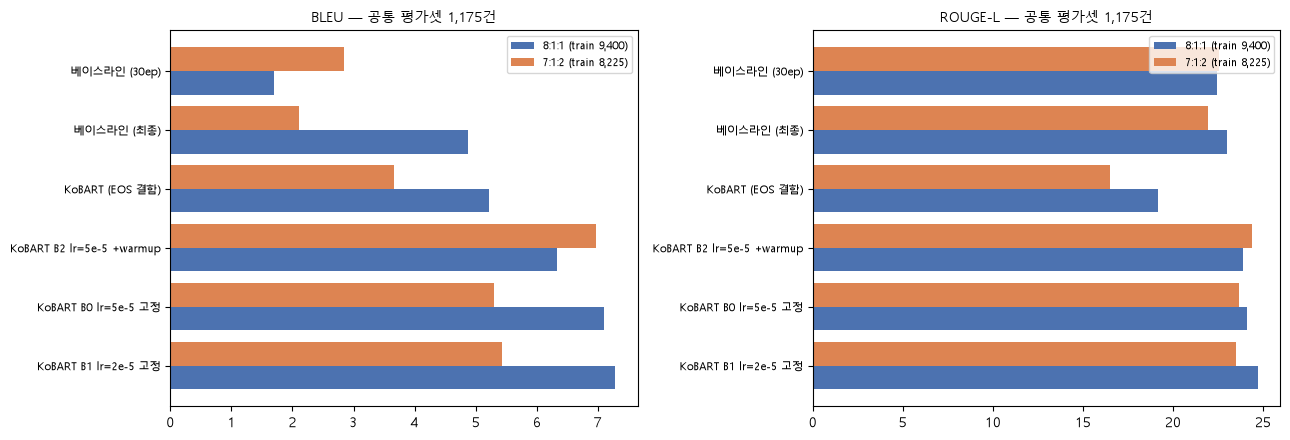

[평균 변화]
  BLEU    : -1.03 (7:1:2 - 8:1:1, 6개 모델 평균)
  ROUGE-L : -0.79 (7:1:2 - 8:1:1, 6개 모델 평균)


In [89]:
# 2026-09-21: 분할 비율별 BLEU 비교 시각화 (공통 평가셋 기준)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
y = np.arange(len(compare_df))
for ax, (c_old, c_new, title) in zip(axes, [
        ('BLEU(8:1:1)', 'BLEU(7:1:2)', 'BLEU'),
        ('ROUGE-L(8:1:1)', 'ROUGE-L(7:1:2)', 'ROUGE-L')]):
    ax.barh(y - 0.2, compare_df[c_old], height=0.4, label='8:1:1 (train 9,400)', color='#4C72B0')
    ax.barh(y + 0.2, compare_df[c_new], height=0.4, label='7:1:2 (train 8,225)', color='#DD8452')
    ax.set_yticks(y)
    ax.set_yticklabels(compare_df['모델'], fontsize=8)
    ax.set_title(f'{title} — 공통 평가셋 1,175건', fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULT_DIR / '09_split_ratio_comparison.png', dpi=120)
plt.show()

print('[평균 변화]')
for c in ['BLEU', 'ROUGE-L']:
    d = (compare_df[f'{c}(7:1:2)'] - compare_df[f'{c}(8:1:1)']).mean()
    print(f'  {c:<8}: {d:+.2f} (7:1:2 - 8:1:1, 6개 모델 평균)')

## 9단계 요약 — 공통 평가셋 1,175건 기준

### 결과

| 모델 | BLEU (8:1:1) | BLEU (7:1:2) | Δ | ROUGE-L Δ |
|---|---|---|---|---|
| KoBART B1 (lr=2e-5) | 7.28 | 5.43 | **-1.85** | -1.18 |
| KoBART B0 (lr=5e-5) | 7.10 | 5.29 | **-1.81** | -0.47 |
| KoBART B2 (lr=5e-5+warmup) | 6.32 | **6.97** | +0.65 | +0.52 |
| KoBART (EOS 결함) | 5.21 | 3.66 | **-1.55** | -2.70 |
| 베이스라인 (최종) | 4.87 | 2.11 | **-2.76** | -1.03 |
| 베이스라인 (30ep) | 1.70 | **2.84** | +1.14 | +0.13 |
| **평균** | | | **-1.03** | **-0.79** |

### 읽을 수 있는 것

**1. 학습 데이터 12.5% 감소는 평균적으로 BLEU를 약 1점 떨어뜨린다.** 6개 모델 중 4개가 하락했고 평균 -1.03이다. val·평가셋·코드·시드가 전부 같고 train 크기만 다르므로, 이 방향성은 train 크기 변화에 귀속시킬 수 있다.

**2. 그러나 모델별 편차가 평균보다 크다** (-2.76 ~ +1.14). 특히 KoBART B2와 베이스라인 30ep는 **오히려 올랐다.** 각 설정을 시드 하나로 1회씩만 돌렸으므로, 개별 모델의 Δ를 "데이터가 줄어서 이만큼 나빠졌다"로 읽으면 안 된다. **평균의 방향성만 신뢰할 수 있다.**

**3. 타격은 베이스라인에 집중됐다.** 처음부터 학습하는 베이스라인이 -2.76으로 가장 크게 떨어진 반면, 사전학습 KoBART 계열은 -1.85 ~ +0.65에 머물렀다. **사전학습 지식이 데이터 부족의 충격을 완충한다**는 해석과 일치하며, 이 프로젝트의 중심 주장(전이학습의 이점)을 다른 각도에서 뒷받침한다.

**4. 다양성은 거의 유지됐다.** KoBART B2의 Distinct-2는 0.463 → 0.463으로 변화가 없었다. 데이터가 줄어도 표현의 폭 자체가 무너지지는 않았다.

### 이 비교가 성립하는 이유

1.5.1절에서 집합 연산으로 검증한 세 조건 덕분이다.

- **7:1:2의 train ⊂ 8:1:1의 train** → 7:1:2 모델이 8:1:1의 test를 본 적이 없다
- **8:1:1의 test ⊂ 7:1:2의 test** → 8:1:1 모델에게도 이 1,175건은 그대로 held-out이다
- **val이 두 실행에서 동일** → 조기 종료 기준이 같다

만약 7:1:2를 독립적으로 다시 나눴다면 그 test에 8:1:1이 학습한 문장이 섞여, 8:1:1 모델에게 유리한 비교가 됐을 것이다.

### 결론에 미치는 영향

**이 프로젝트의 주요 결론은 분할 비율을 바꿔도 유지된다.**

| 결론 | 8:1:1 | 7:1:2 | 유지 여부 |
|---|---|---|---|
| 전이학습 > 베이스라인 | +49.5% | **+187%** | 유지 (오히려 강화) |
| EOS 결함 수정이 단일 변경 중 최대 효과 | +36.3% | **+51.4%** | 유지 |
| val_loss 순위 ≠ BLEU 순위 | 3/3 불일치 | 3/3 불일치 | 유지 |
| beam5가 greedy보다 우위 | +60% / +16% | +49% / +45% | 유지 |
| `no_repeat_ngram`은 사실상 무효 | +0.03 | **-0.01** | 유지 (부호도 불안정) |
| 최적 하이퍼파라미터 config | B1 | **B2** | **바뀜 — 시드 변동 범위 안일 가능성** |